In [ ]:
import pandas as pd
import os

# Path ke folder utama yang berisi subfolder
main_folder_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train"

# Loop untuk setiap subfolder di dalam folder MSS
for folder_name in os.listdir(main_folder_path):
    folder_path = os.path.join(main_folder_path, folder_name)

    # Cek apakah itu folder
    if os.path.isdir(folder_path):
        # List untuk menyimpan semua dataframe
        all_data = []

        # Loop untuk setiap file dalam folder
        for filename in os.listdir(folder_path):
            if filename.endswith(".csv"):
                # Path lengkap file CSV
                file_path = os.path.join(folder_path, filename)

                # Coba membaca dengan encoding 'utf-8', jika gagal coba encoding lain
                try:
                    df = pd.read_csv(file_path, encoding='utf-8')
                except UnicodeDecodeError:
                    try:
                        df = pd.read_csv(file_path, encoding='ISO-8859-1')
                    except UnicodeDecodeError:
                        df = pd.read_csv(file_path, encoding='latin1')

                # Menghapus spasi di awal/akhir nama kolom
                df.columns = df.columns.str.strip()

                # Mengganti semua 'min' menjadi 'Min' dalam nama kolom yang sesuai
                df.columns = df.columns.str.replace(r'(?i)min', 'Min', regex=True)

                # Menambahkan dataframe ke list
                all_data.append(df)

        # Menggabungkan semua dataframe menjadi satu
        final_df = pd.concat(all_data, ignore_index=True)

        # Menghapus kolom yang duplikat setelah penggabungan
        final_df = final_df.loc[:, ~final_df.columns.duplicated()]

        # Menyimpan dataframe yang sudah digabungkan ke file CSV baru dengan nama folder
        output_file_path = os.path.join(main_folder_path, f"{folder_name}.csv")
        final_df.to_csv(output_file_path, index=False)

        # Menampilkan dataframe gabungan (bisa lihat beberapa baris pertama)
        print(f"File gabungan untuk folder {folder_name} telah disimpan")
        print(final_df.head())


File gabungan untuk folder Admiralty telah disimpan
         Date Highest 30 Min Rainfall (mm) Highest 60 Min Rainfall (mm)  \
0  2009-01-01                                                           
1  2009-01-02                                                           
2  2009-01-03                                                           
3  2009-01-04                                                           
4  2009-01-05                                                           

  Highest 120 Min Rainfall (mm) Mean Temperature (°C)  \
0                                                     
1                                                     
2                                                     
3                                                     
4                                                     

  Maximum Temperature (°C) Minimum Temperature (°C) Mean Wind Speed (km/h)  \
0                                                                        

In [ ]:
import os
import pandas as pd
import numpy as np  # Pastikan numpy diimport

# Path ke folder yang berisi file CSV
folder_path = r"C:/Lokal/KEGIATAN/SSDS/Data/Train"
# Path ke folder tujuan untuk menyimpan hasil file yang telah dibersihkan
output_folder = r"C:/Lokal/KEGIATAN/SSDS/Data/Train-clean"

# Pastikan folder tujuan ada, jika tidak buat foldernya
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Loop untuk setiap file dalam folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        # Path lengkap file CSV
        file_path = os.path.join(folder_path, filename)
        
        # Membaca file CSV
        df = pd.read_csv(file_path)

        # Mengonversi kolom 'Date' menjadi tipe datetime
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
        # Menghapus spasi di awal/akhir setiap elemen di seluruh dataframe
        df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
        
        # Ganti semua string kosong atau whitespace dengan NaN
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
        
        # Ganti semua kemunculan karakter '' dengan NaN
        df.replace('', pd.NA, inplace=True)
        
        # Ubah kolom yang nullable menjadi tipe numerik (float), agar semua nilai hilang menjadi NaN
        df = df.apply(lambda x: pd.to_numeric(x, errors='coerce') if x.dtype != 'datetime64[ns]' else x)
        
        df = df[['Date', 
                 'Highest 30 Min Rainfall (mm)', 
                 'Highest 60 Min Rainfall (mm)', 
                 'Highest 120 Min Rainfall (mm)', 
                 'Mean Temperature (°C)', 
                 'Maximum Temperature (°C)', 
                 'Minimum Temperature (°C)', 
                 'Mean Wind Speed (km/h)', 
                 'Max Wind Speed (km/h)']]

        # Ekstrak tahun dan bulan dari kolom 'Date'
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month

        # Fungsi untuk mengisi nilai kosong dengan median bulanan (dibulatkan 2 angka desimal)
        def fill_missing_with_monthly_median(column_name):
            for year in df['Year'].unique():
                for month in df['Month'].unique():
                    # Pilih data pada tahun dan bulan tertentu
                    monthly_data = df[(df['Year'] == year) & (df['Month'] == month)]

                    # Periksa apakah ada data yang valid untuk menghitung median
                    valid_data = monthly_data[column_name].dropna()

                    # Hitung median dan bulatkan 2 angka di belakang koma
                    if len(valid_data) > 0:
                        median_value = round(valid_data.median(), 2)
                    else:
                        median_value = 0.00  # Tetap dua angka desimal

                    # Isi nilai kosong (NaN) dengan median bulanan yang dibulatkan
                    df.loc[(df['Year'] == year) & (df['Month'] == month) & (df[column_name].isna()), column_name] = median_value

        # Daftar kolom yang ingin diisi
        columns_to_fill = ['Mean Wind Speed (km/h)', 
                           'Highest 30 Min Rainfall (mm)', 
                           'Highest 60 Min Rainfall (mm)', 
                           'Highest 120 Min Rainfall (mm)', 
                           'Mean Temperature (°C)', 
                           'Maximum Temperature (°C)', 
                           'Minimum Temperature (°C)', 
                           'Max Wind Speed (km/h)']

        # Isi nilai kosong pada tiap kolom dengan median bulanan (dibulatkan)
        for col in columns_to_fill:
            fill_missing_with_monthly_median(col)

        # Menambahkan kolom 'Daily Rainfall Total (mm)' yang kosong
        df['Daily Rainfall Total (mm)'] = np.nan

        df = df[['Date', 
                 'Highest 30 Min Rainfall (mm)', 
                 'Highest 60 Min Rainfall (mm)', 
                 'Highest 120 Min Rainfall (mm)', 
                 'Mean Temperature (°C)', 
                 'Maximum Temperature (°C)', 
                 'Minimum Temperature (°C)', 
                 'Mean Wind Speed (km/h)', 
                 'Max Wind Speed (km/h)',
                 'Daily Rainfall Total (mm)']]  # Menambahkan kolom baru di sini

        # Simpan dataframe df ke file CSV dengan nama baru di folder 'Train-clean'
        cleaned_filename = f"{filename.replace('.csv', '')}-cleaning.csv"
        output_file_path = os.path.join(output_folder, cleaned_filename)
        df.to_csv(output_file_path, index=False)
        
        print(f"Dataframe untuk {filename} berhasil disimpan")


Dataframe untuk Admiralty.csv berhasil disimpan
Dataframe untuk Ang_Mo_Kio.csv berhasil disimpan
Dataframe untuk Bukit_Panjang.csv berhasil disimpan
Dataframe untuk Bukit_Timah.csv berhasil disimpan
Dataframe untuk Buona_Vista.csv berhasil disimpan
Dataframe untuk Changi.csv berhasil disimpan
Dataframe untuk Choa_Chu_Kang_Central.csv berhasil disimpan
Dataframe untuk Choa_Chu_Kang_South.csv berhasil disimpan
Dataframe untuk Clementi.csv berhasil disimpan
Dataframe untuk East_Coast_Parkway.csv berhasil disimpan
Dataframe untuk Jurong_Island.csv berhasil disimpan
Dataframe untuk Jurong_Pier.csv berhasil disimpan
Dataframe untuk Jurong_West.csv berhasil disimpan
Dataframe untuk Kent_Ridge.csv berhasil disimpan
Dataframe untuk Kranji_Reservoir.csv berhasil disimpan
Dataframe untuk Lim_Chu_Kang.csv berhasil disimpan
Dataframe untuk Lower_Peirce_Reservoir.csv berhasil disimpan
Dataframe untuk Macritchie_Reservoir.csv berhasil disimpan
Dataframe untuk Mandai.csv berhasil disimpan
Dataframe un

In [618]:
import os
import cv2
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Admiralty

In [ ]:
admiralty_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Admiralty/"
admiralty_csv_prefix = "Data_Gabungan_Lainnya_"
admiralty_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

admiralty_rain_info = {
    2009: 200, 2010: 100, 2011: 130, 2012: 190, 2013: 105,
    2014: 135, 2015: 125, 2016: 110, 2017: 90,  2018: 110,
    2019: 100, 2020: 120, 2021: 170, 2022: 120, 2023: 200,
}

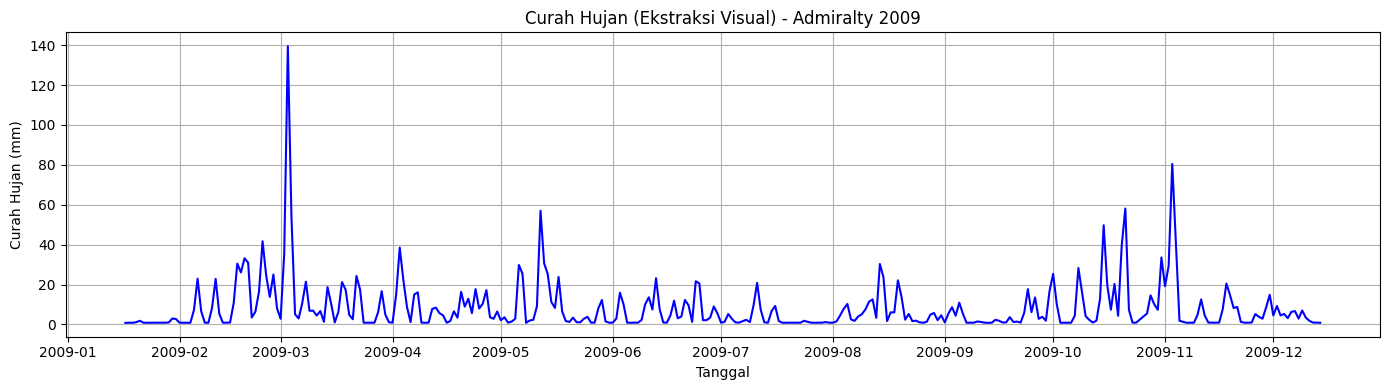

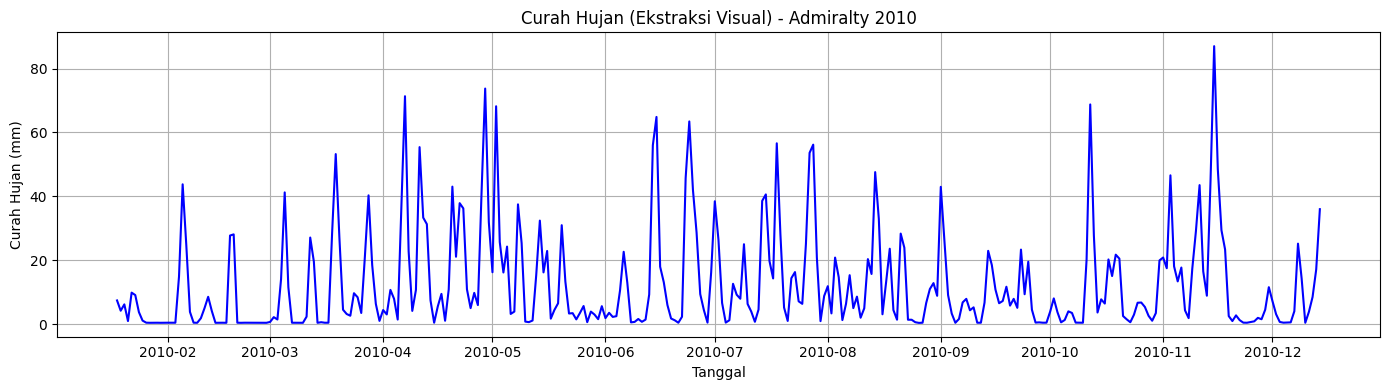

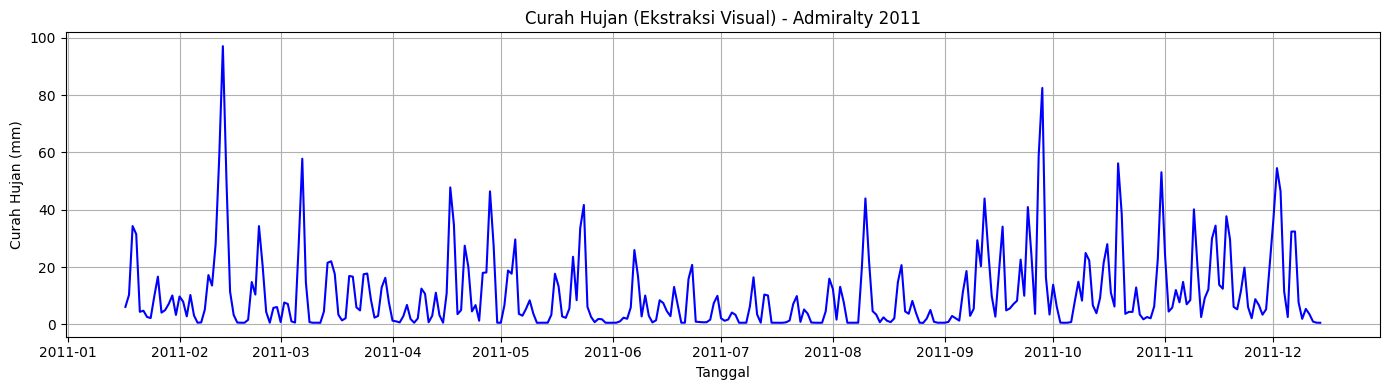

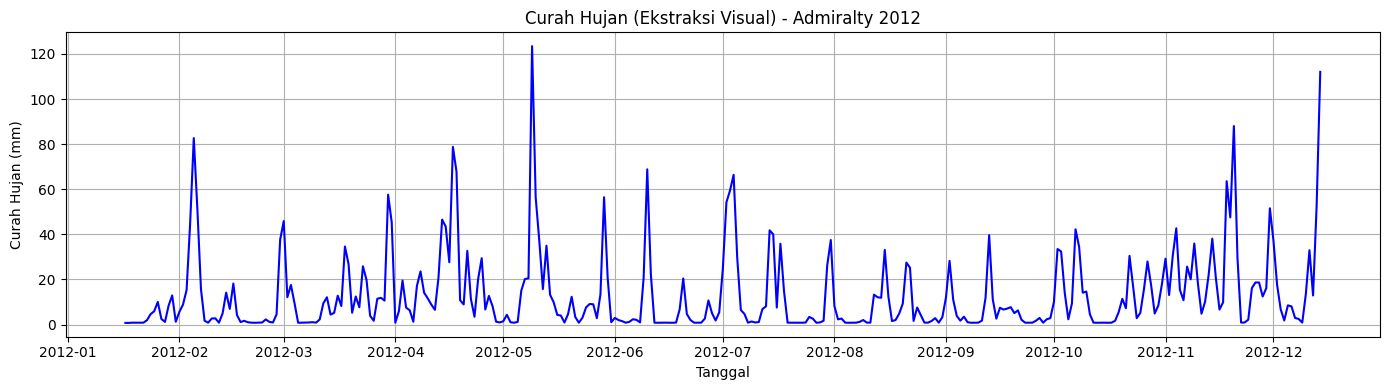

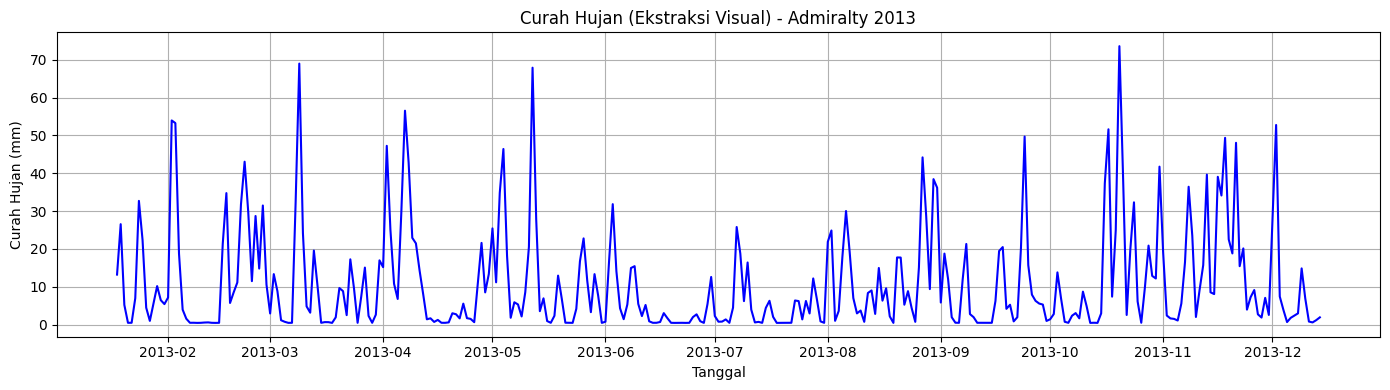

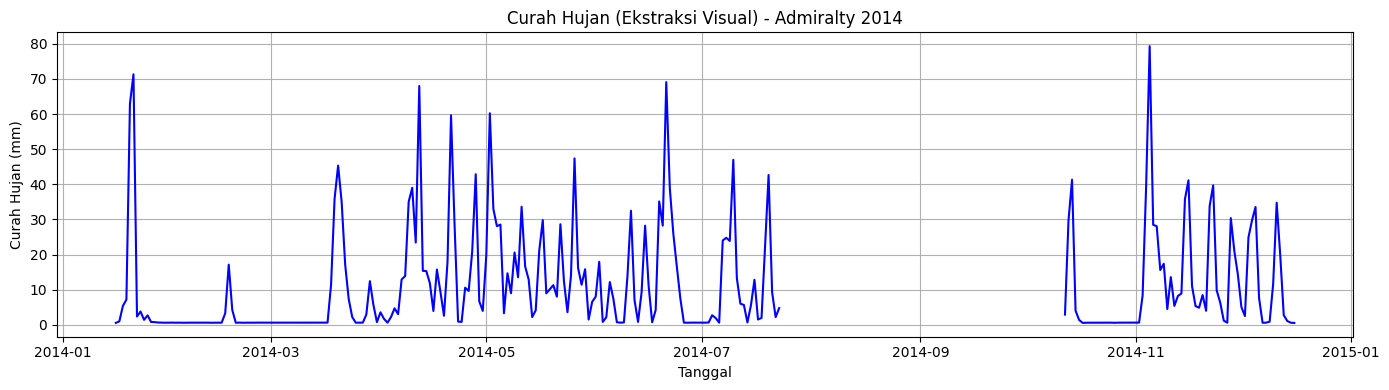

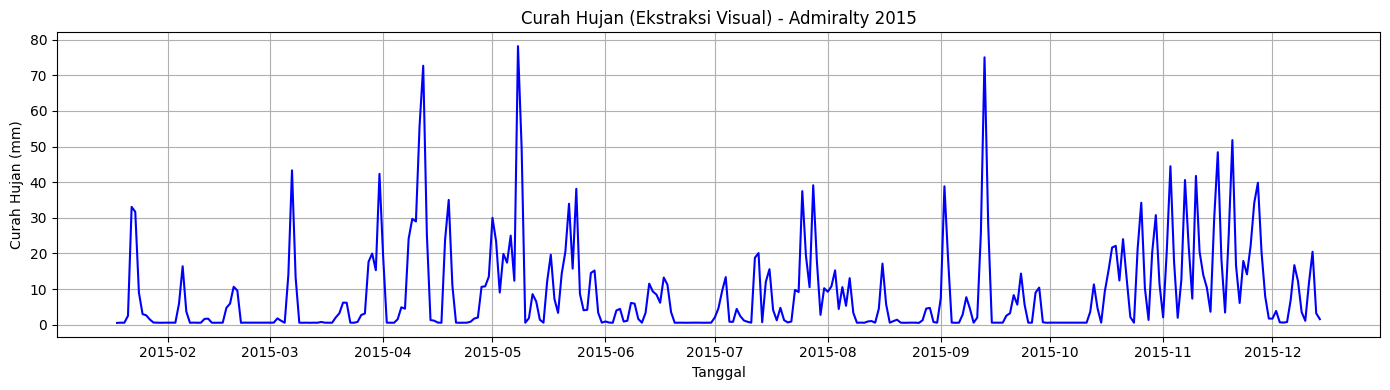

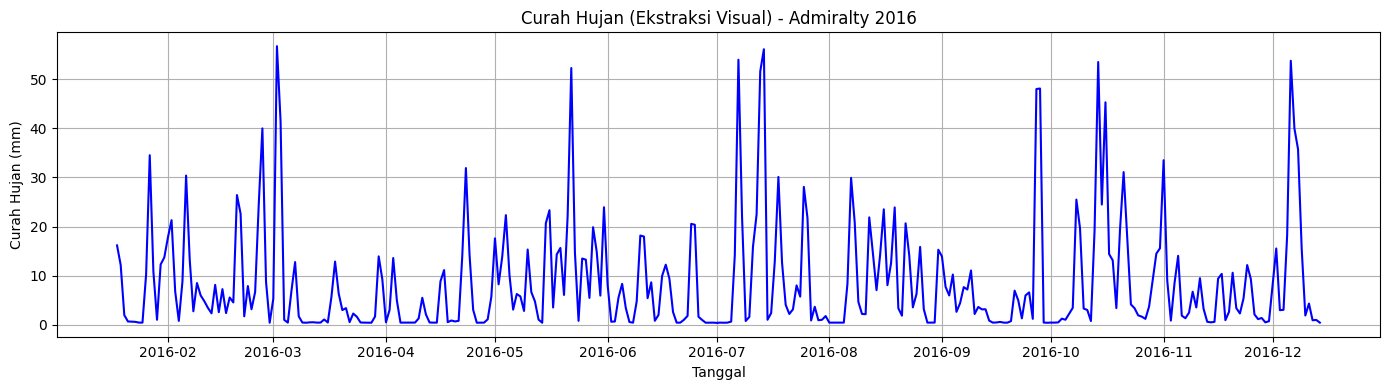

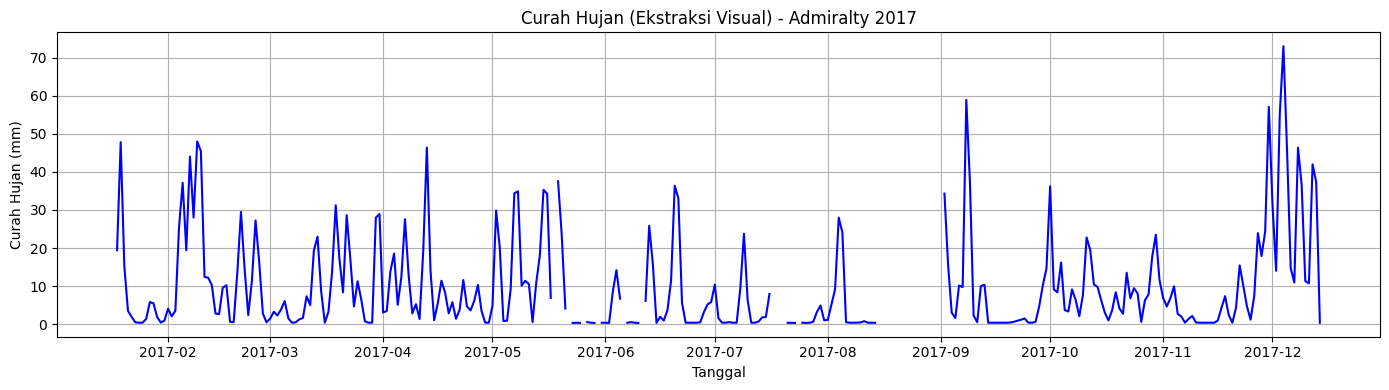

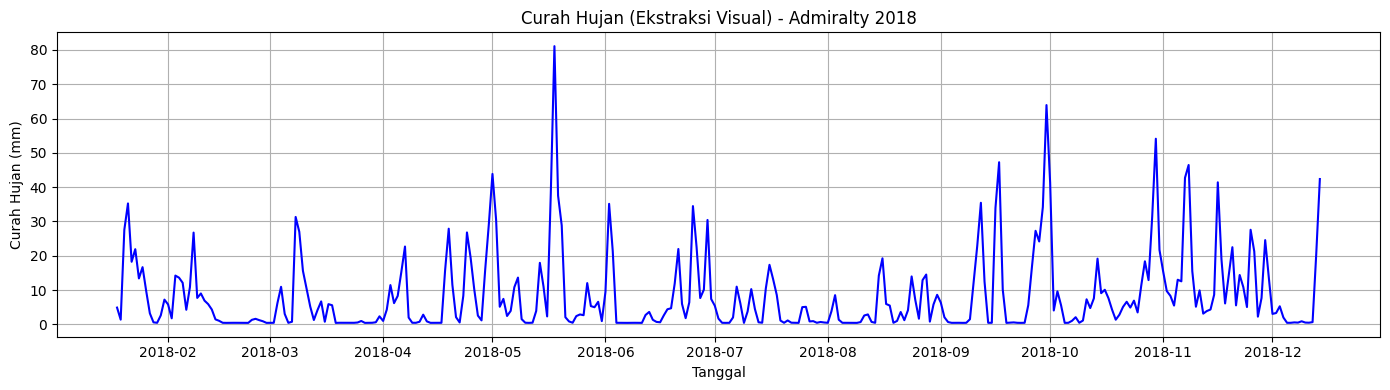

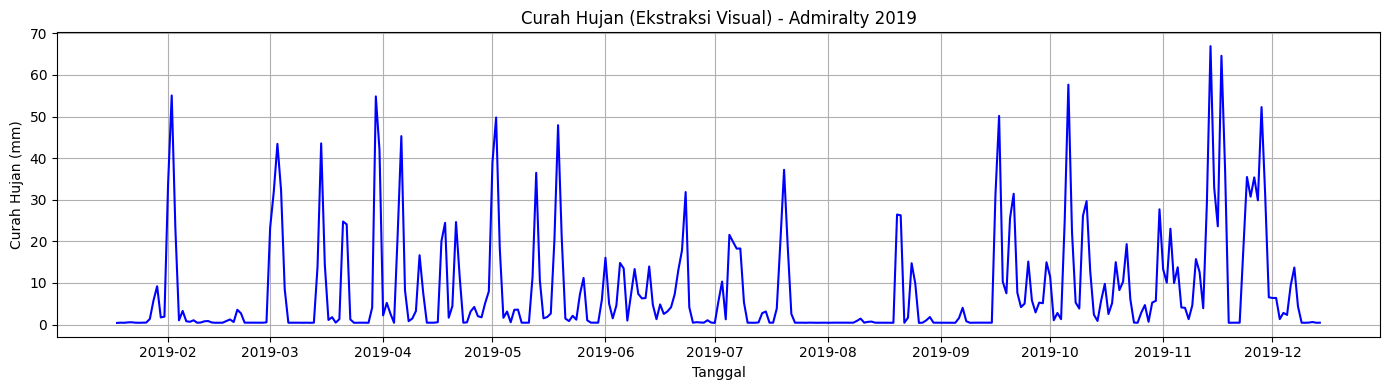

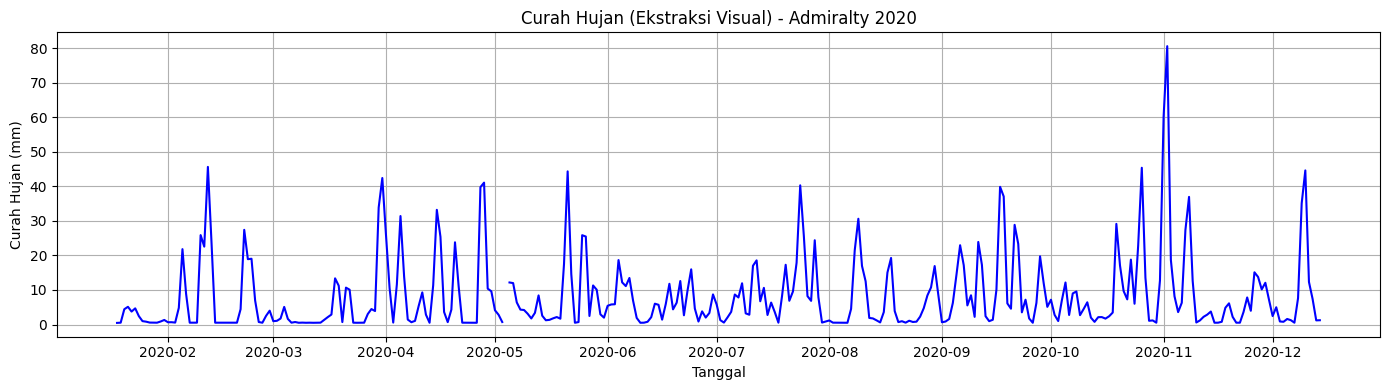

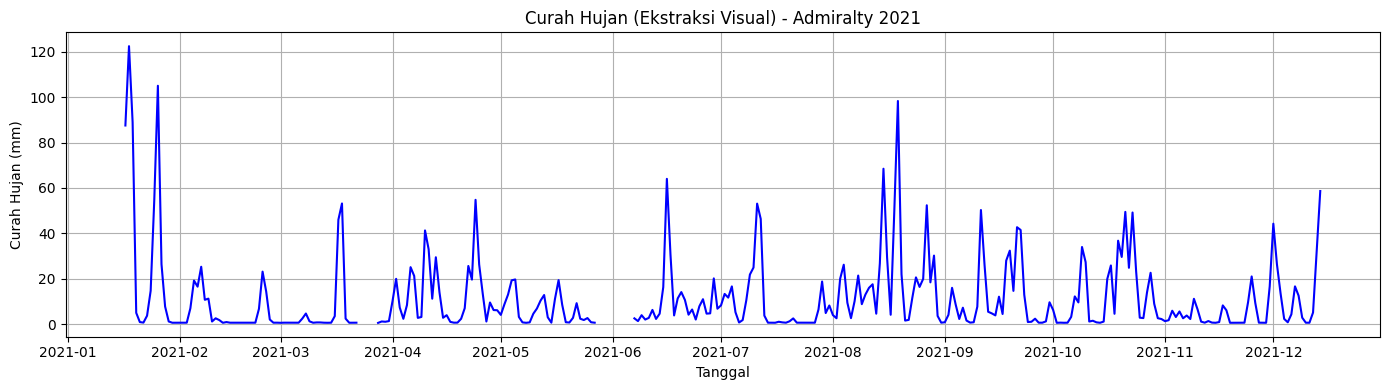

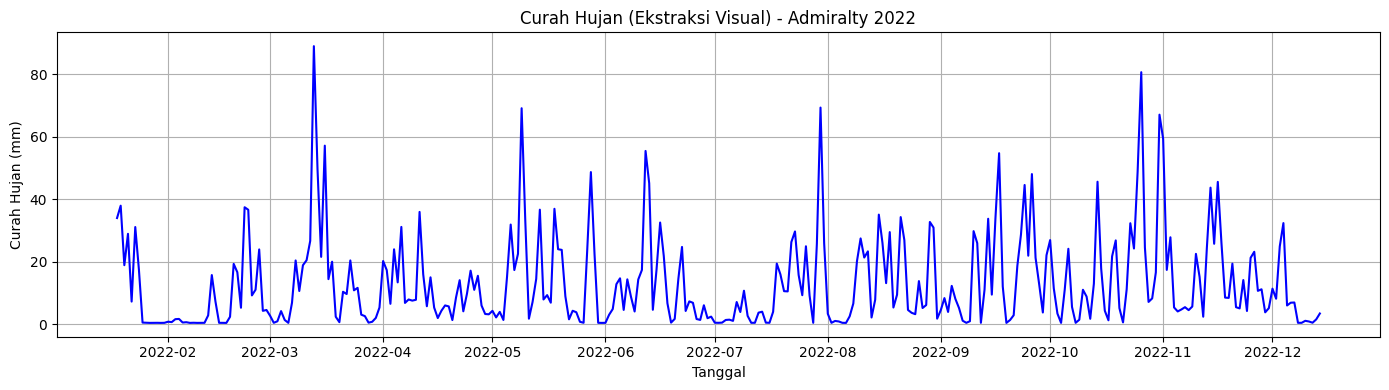

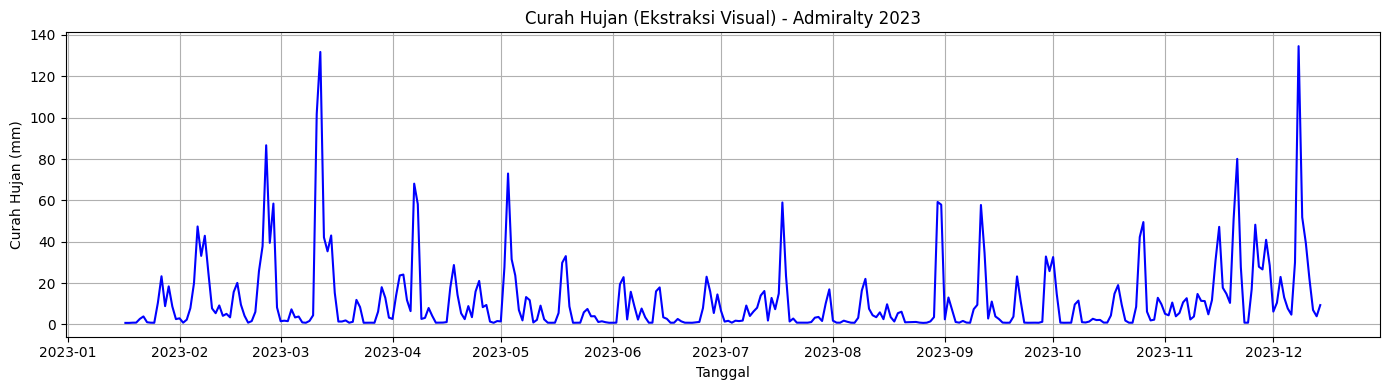

In [620]:
all_admiralty = []

for year, rain_max in admiralty_rain_info.items():
    png_file = os.path.join(admiralty_path, f"{admiralty_png_prefix}{year}.png")
    csv_file = os.path.join(admiralty_path, f"{admiralty_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    mask_blue = cv2.inRange(hsv, np.array([100,100,100]), np.array([140,255,255]))
    mask_black = cv2.inRange(hsv, np.array([0,0,0]), np.array([180,255,70]))

    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:,0] >= x_start) & (points[:,0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Admiralty: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel, y_pixel = filtered_points[:,0], filtered_points[:,1]
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')
    all_admiralty.append(df_merged)

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='blue', label='Admiralty')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Admiralty {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

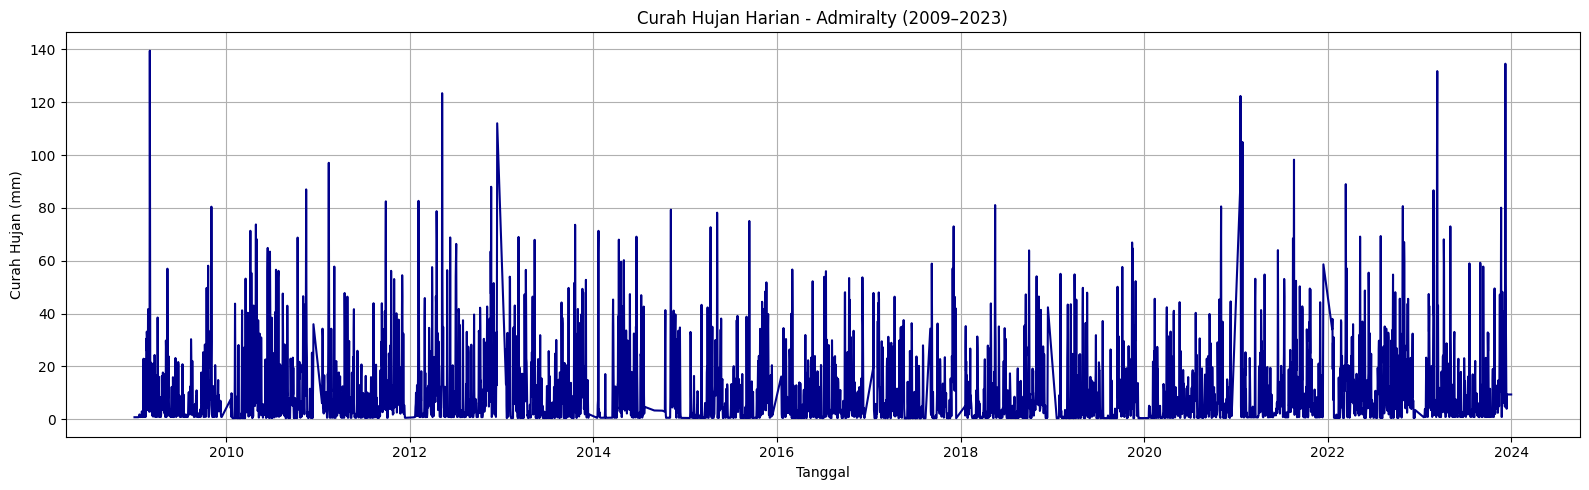

In [621]:
# Concatenate dan interpolasi
df_concat_admiralty = pd.concat(all_admiralty, ignore_index=True)
df_concat_admiralty['rainfall_mm'] = (
    df_concat_admiralty['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot semua tahun
plt.figure(figsize=(16, 5))
plt.plot(df_concat_admiralty['Date'], df_concat_admiralty['rainfall_mm'], color='darkblue')
plt.title("Curah Hujan Harian - Admiralty (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_admiralty[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Admiralty.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Admiralty.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Admiralty-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Admiralty-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-01-01                   0.779727
1 2009-01-02                   0.779727
2 2009-01-03                   0.779727
3 2009-01-04                   0.779727
4 2009-01-05                   0.779727


# Ang_Mo_Kio

In [ ]:
# === Ang_Mo_Kio ===
angmokio_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Ang_Mo_Kio/"
angmokio_csv_prefix = "Data_Gabungan_Lainnya_"
angmokio_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

angmokio_rain_info = {
    2009: 110, 2010: 200, 2011: 165, 2012: 130, 2013: 150,
    2014: 90, 2015: 120, 2016: 120, 2017: 110,  2018: 140,
    2019: 100, 2020: 110, 2021: 150, 2022: 110, 2023: 200,
}

In [ ]:
all_angmokio = []

for year, rain_max in angmokio_rain_info.items():
    png_file = os.path.join(angmokio_path, f"{angmokio_png_prefix}{year}.png")
    csv_file = os.path.join(angmokio_path, f"{angmokio_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    mask_blue = cv2.inRange(hsv, np.array([100,100,100]), np.array([140,255,255]))
    mask_black = cv2.inRange(hsv, np.array([0,0,0]), np.array([180,255,70]))

    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:,0] >= x_start) & (points[:,0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Ang Mo Kio: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel, y_pixel = filtered_points[:,0], filtered_points[:,1]
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')
    all_angmokio.append(df_merged)

    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='orange', label='Ang Mo Kio')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Ang Mo Kio {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

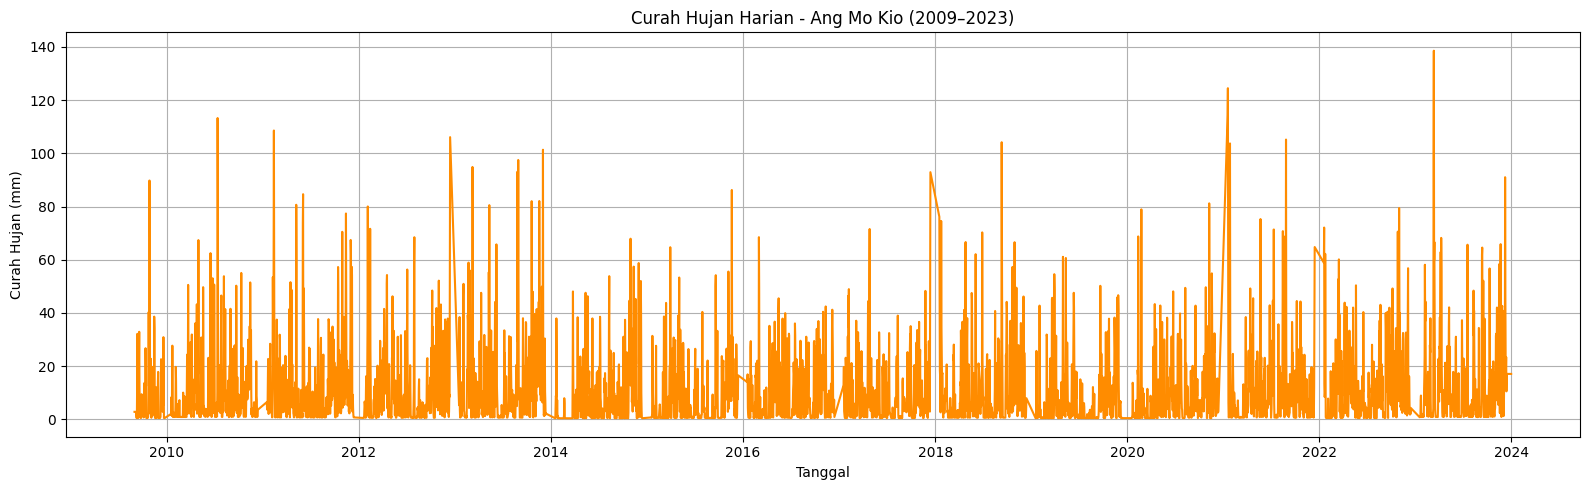

In [626]:
df_concat_angmokio = pd.concat(all_angmokio, ignore_index=True)
df_concat_angmokio['rainfall_mm'] = (
    df_concat_angmokio['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

plt.figure(figsize=(16, 5))
plt.plot(df_concat_angmokio['Date'], df_concat_angmokio['rainfall_mm'], color='darkorange')
plt.title("Curah Hujan Harian - Ang Mo Kio (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_angmokio[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Ang_Mo_Kio.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Ang_Mo_Kio.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Ang_Mo_Kio-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Ang_Mo_Kio-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-09-01                   2.804019
1 2009-09-02                   2.804019
2 2009-09-03                   2.804019
3 2009-09-04                   2.804019
4 2009-09-05                   2.804019


# Bukit_Panjang

In [ ]:
bukitpanjang_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Bukit_Panjang/"
bukitpanjang_csv_prefix = "Data_Gabungan_Lainnya_"
bukitpanjang_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

bukitpanjang_rain_info = {
    1980: 110, 1981: 110, 1982: 150, 1983: 110, 1984: 200,
    1985: 270, 1986: 150, 1987: 160, 1988: 150, 1989: 120,
    1990: 200, 1991: 200, 1992: 140, 1993: 120, 1994: 120,
    1995: 155, 1996: 170, 1997: 120, 1998: 156, 1999: 150,
    2000: 110, 2001: 170, 2002: 120, 2003: 180, 2004: 320,
    2005: 200, 2006: 320, 2007: 180, 2008: 140, 2009: 130,
    2010: 230, 2011: 180, 2012: 150, 2013: 200, 2014: 150,
    2015: 170, 2016: 170, 2017: 170, 2018: 110, 2019: 150,
    2020: 170, 2021: 320, 2022: 170, 2023: 190,
}

In [ ]:
all_bukitpanjang = []

for year, rain_max in bukitpanjang_rain_info.items():
    png_file = os.path.join(bukitpanjang_path, f"{bukitpanjang_png_prefix}{year}.png")
    csv_file = os.path.join(bukitpanjang_path, f"{bukitpanjang_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Temukan sumbu X
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Bukit_Panjang: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Hitung index hari dan tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Hitung rainfall dari y-pixel
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabung dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_bukitpanjang.append(df_merged)

    # Visualisasi per tahun (sebelum interpolasi)
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='green', label='Bukit_Panjang')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Bukit_Panjang {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

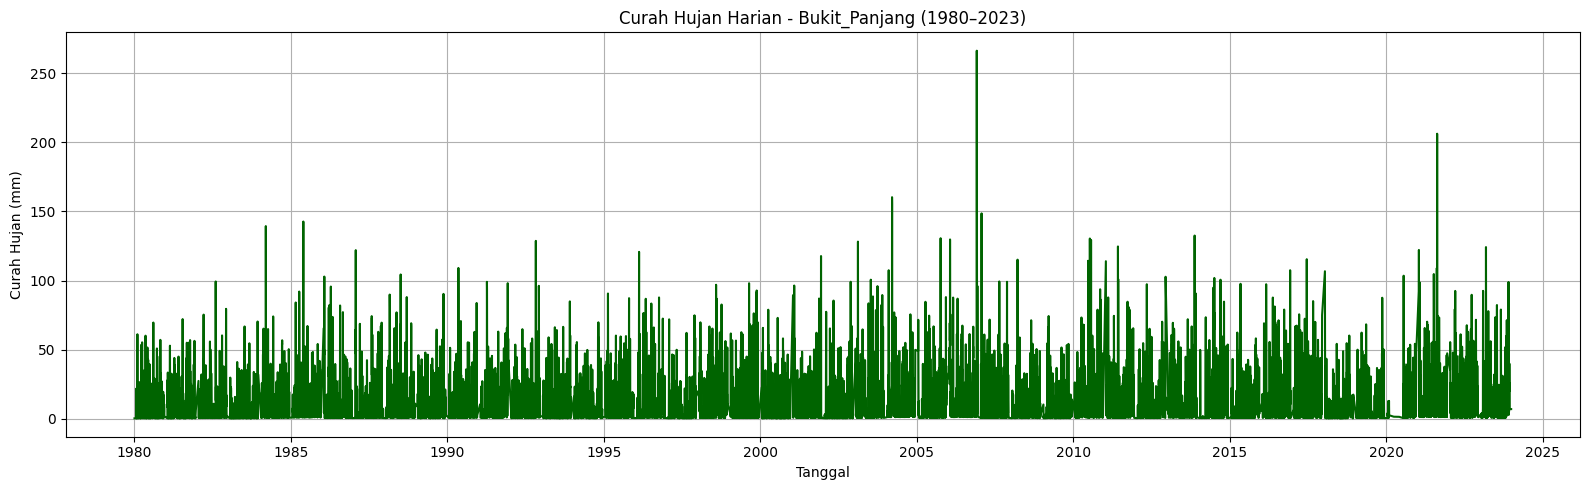

In [631]:
# Gabungkan semua tahun dan interpolasi
df_concat_bukitpanjang = pd.concat(all_bukitpanjang, ignore_index=True)
df_concat_bukitpanjang['rainfall_mm'] = (
    df_concat_bukitpanjang['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan 1980–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_bukitpanjang['Date'], df_concat_bukitpanjang['rainfall_mm'], color='darkgreen')
plt.title("Curah Hujan Harian - Bukit_Panjang (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_bukitpanjang[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Bukit_Panjang.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Bukit_Panjang.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Bukit_Panjang-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Bukit_Panjang-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                    0.42885
1 1980-01-02                    0.42885
2 1980-01-03                    0.42885
3 1980-01-04                    0.42885
4 1980-01-05                    0.42885


# Bukit_Timah

In [ ]:
bukittimah_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Bukit_Timah/"
bukittimah_csv_prefix = "Data_Gabungan_Lainnya_"
bukittimah_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

bukittimah_rain_info = {
    2009: 90, 2010: 250, 2011: 200, 2012: 120, 2013: 130,
    2014: 130, 2015: 120, 2016: 130, 2017: 170,  2018: 110,
    2019: 80,  2020: 100, 2021: 170, 2022: 150, 2023: 210,
}

In [ ]:
all_bukittimah = []

for year, rain_max in bukittimah_rain_info.items():
    png_file = os.path.join(bukittimah_path, f"{bukittimah_png_prefix}{year}.png")
    csv_file = os.path.join(bukittimah_path, f"{bukittimah_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Temukan sumbu X (garis horizontal)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Bukit_Timah: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame ekstrak
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_bukittimah.append(df_merged)

    # Plot per tahun (sebelum interpolasi)
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='purple', label='Bukit_Timah')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Bukit_Timah {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

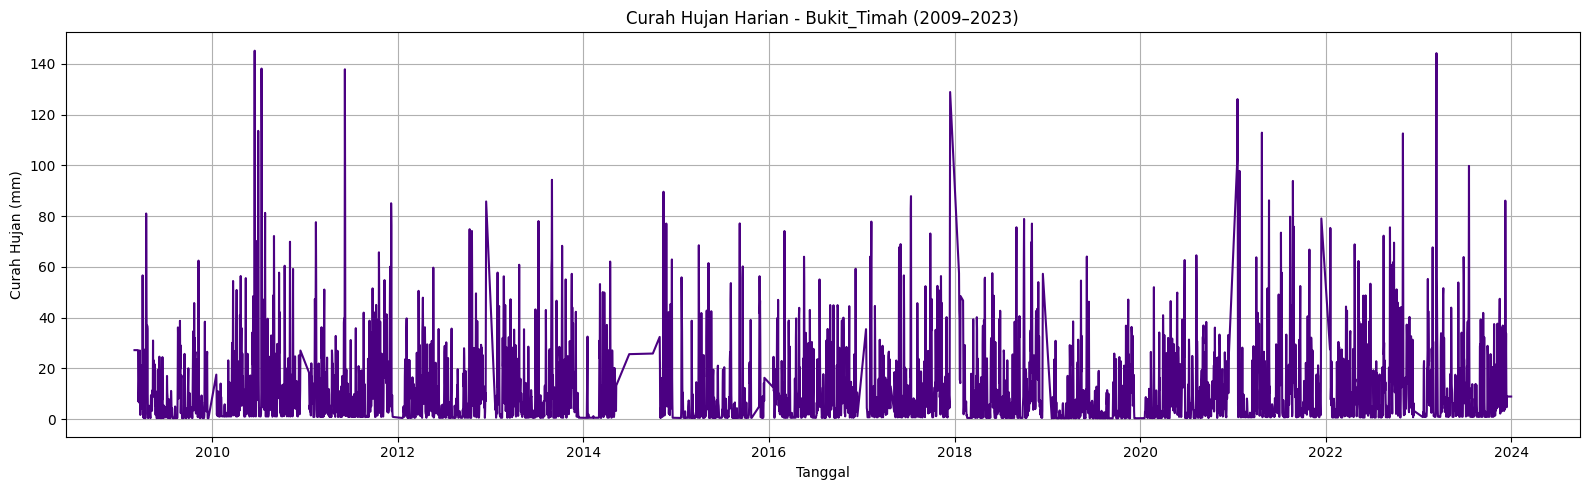

In [635]:
# Gabungkan semua tahun dan interpolasi
df_concat_bukittimah = pd.concat(all_bukittimah, ignore_index=True)
df_concat_bukittimah['rainfall_mm'] = (
    df_concat_bukittimah['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_bukittimah['Date'], df_concat_bukittimah['rainfall_mm'], color='indigo')
plt.title("Curah Hujan Harian - Bukit_Timah (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_bukittimah[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Bukit_Timah.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Bukit_Timah.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Bukit_Timah-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Bukit_Timah-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-03-01                  27.198204
1 2009-03-02                  27.198204
2 2009-03-03                  27.198204
3 2009-03-04                  27.198204
4 2009-03-05                  27.198204


# Buona_Vista

In [ ]:
buonavista_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Buona_Vista/"
buonavista_csv_prefix = "Data_Gabungan_Lainnya_"
buonavista_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

buonavista_rain_info = {
    2009: 110, 2010: 130, 2011: 150, 2012: 150, 2013: 110,
    2014: 110, 2015: 130, 2016: 160, 2017: 165,  2018: 155,
    2019: 150, 2020: 170, 2021: 120, 2022: 200, 2023: 240,
}

In [ ]:
all_buonavista = []

for year, rain_max in buonavista_rain_info.items():
    png_file = os.path.join(buonavista_path, f"{buonavista_png_prefix}{year}.png")
    csv_file = os.path.join(buonavista_path, f"{buonavista_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal terpanjang)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Buona_Vista: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_buonavista.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='teal', label='Buona_Vista')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Buona_Vista {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

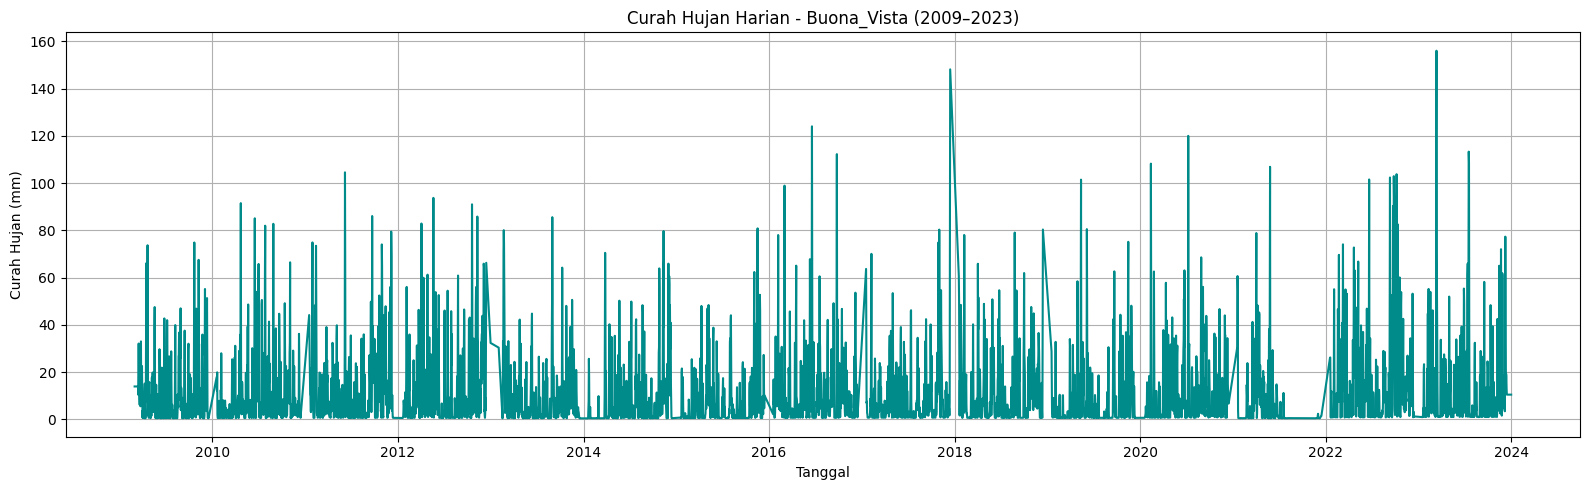

In [639]:
# Gabungkan semua tahun dan interpolasi
df_concat_buonavista = pd.concat(all_buonavista, ignore_index=True)
df_concat_buonavista['rainfall_mm'] = (
    df_concat_buonavista['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total 2009–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_buonavista['Date'], df_concat_buonavista['rainfall_mm'], color='darkcyan')
plt.title("Curah Hujan Harian - Buona_Vista (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_buonavista[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Buona_Vista.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Buona_Vista.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Buona_Vista-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Buona_Vista-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-03-01                  13.922935
1 2009-03-02                  13.922935
2 2009-03-03                  13.922935
3 2009-03-04                  13.922935
4 2009-03-05                  13.922935


# Changi

In [ ]:
changi_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Changi/"
changi_csv_prefix = "Data_Gabungan_Lainnya_"
changi_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

changi_rain_info = {
    1980: 230, 1981: 90, 1982: 140, 1983: 230, 1984: 220,
    1985: 125, 1986: 160, 1987: 160, 1988: 260, 1989: 230,
    1990: 240, 1991: 200, 1992: 140, 1993: 100, 1994: 250,
    1995: 270, 1996: 155, 1997: 95, 1998: 120, 1999: 130,
    2000: 210, 2001: 310, 2002: 90, 2003: 310, 2004: 280,
    2005: 200, 2006: 290, 2007: 180, 2008: 200, 2009: 120,
    2010: 180, 2011: 300, 2012: 130, 2013: 180, 2014: 100,
    2015: 100, 2016: 110, 2017: 110, 2018: 100, 2019: 120,
    2020: 90, 2021: 280, 2022: 90, 2023: 200,
}

In [ ]:
all_changi = []

for year, rain_max in changi_rain_info.items():
    png_file = os.path.join(changi_path, f"{changi_png_prefix}{year}.png")
    csv_file = os.path.join(changi_path, f"{changi_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal terpanjang)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Changi: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_changi.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='skyblue', label='Changi')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Changi {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

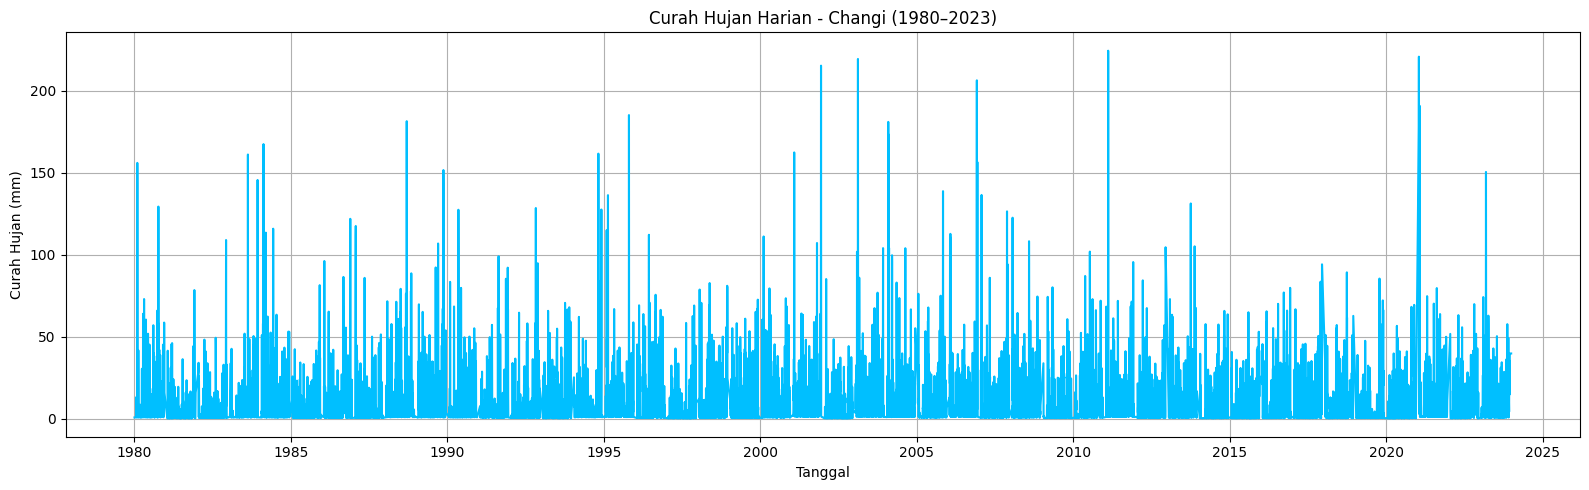

In [643]:
# Gabungkan semua tahun dan interpolasi
df_concat_changi = pd.concat(all_changi, ignore_index=True)
df_concat_changi['rainfall_mm'] = (
    df_concat_changi['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total gabungan 1980–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_changi['Date'], df_concat_changi['rainfall_mm'], color='deepskyblue')
plt.title("Curah Hujan Harian - Changi (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_changi[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Changi.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Changi.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Changi-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Changi-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.896686
1 1980-01-02                   0.896686
2 1980-01-03                   0.896686
3 1980-01-04                   0.896686
4 1980-01-05                   0.896686


# Choa_Chu_Kang_Central

In [ ]:
choachu_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Choa_Chu_Kang_Central/"
choachu_csv_prefix = "Data_Gabungan_Lainnya_"
choachu_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

choachu_rain_info = {
    2009: 36, 2010: 170, 2011: 160, 2012: 140, 2013: 170,
    2014: 120, 2015: 200, 2016: 120, 2017: 120,  2018: 130,
    2019: 120, 2020: 130, 2021: 200, 2022: 180, 2023: 200,
}

In [ ]:
all_choachu = []

for year, rain_max in choachu_rain_info.items():
    png_file = os.path.join(choachu_path, f"{choachu_png_prefix}{year}.png")
    csv_file = os.path.join(choachu_path, f"{choachu_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask warna biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Choa_Chu_Kang_Central: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_choachu.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='crimson', label='Choa_Chu_Kang_Central')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Choa_Chu_Kang_Central {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

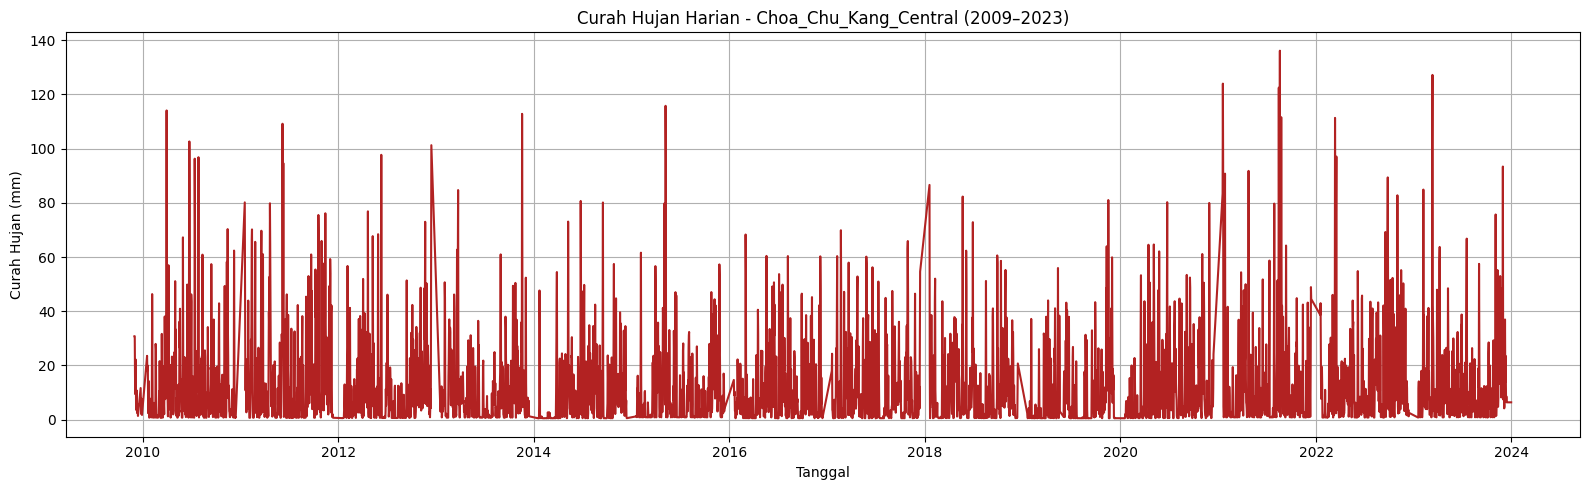

In [647]:
# Gabungkan semua tahun dan interpolasi
df_concat_choachu = pd.concat(all_choachu, ignore_index=True)
df_concat_choachu['rainfall_mm'] = (
    df_concat_choachu['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan 2009–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_choachu['Date'], df_concat_choachu['rainfall_mm'], color='firebrick')
plt.title("Curah Hujan Harian - Choa_Chu_Kang_Central (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_choachu[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Choa_Chu_Kang_Central.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Choa_Chu_Kang_Central.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Choa_Chu_Kang_Central-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Choa_Chu_Kang_Central-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-12-01                  30.772605
1 2009-12-02                  30.772605
2 2009-12-03                  15.995046
3 2009-12-04                   9.405781
4 2009-12-05                  22.217284


# Choa_Chu_Kang_South

In [ ]:
choachus_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Choa_Chu_Kang_South/"
choachus_csv_prefix = "Data_Gabungan_Lainnya_"
choachus_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

choachus_rain_info = {
    2011: 100, 2012: 160, 2013: 90, 2014: 120, 2015: 100,
    2016: 110, 2017: 100,  2018: 150, 2019: 110,
    2020: 110, 2021: 200, 2022: 190, 2023: 200,
}

In [ ]:
all_choachus = []

for year, rain_max in choachus_rain_info.items():
    png_file = os.path.join(choachus_path, f"{choachus_png_prefix}{year}.png")
    csv_file = os.path.join(choachus_path, f"{choachus_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Choa_Chu_Kang_South: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_choachus.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumvioletred', label='Choa_Chu_Kang_South')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Choa_Chu_Kang_South {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

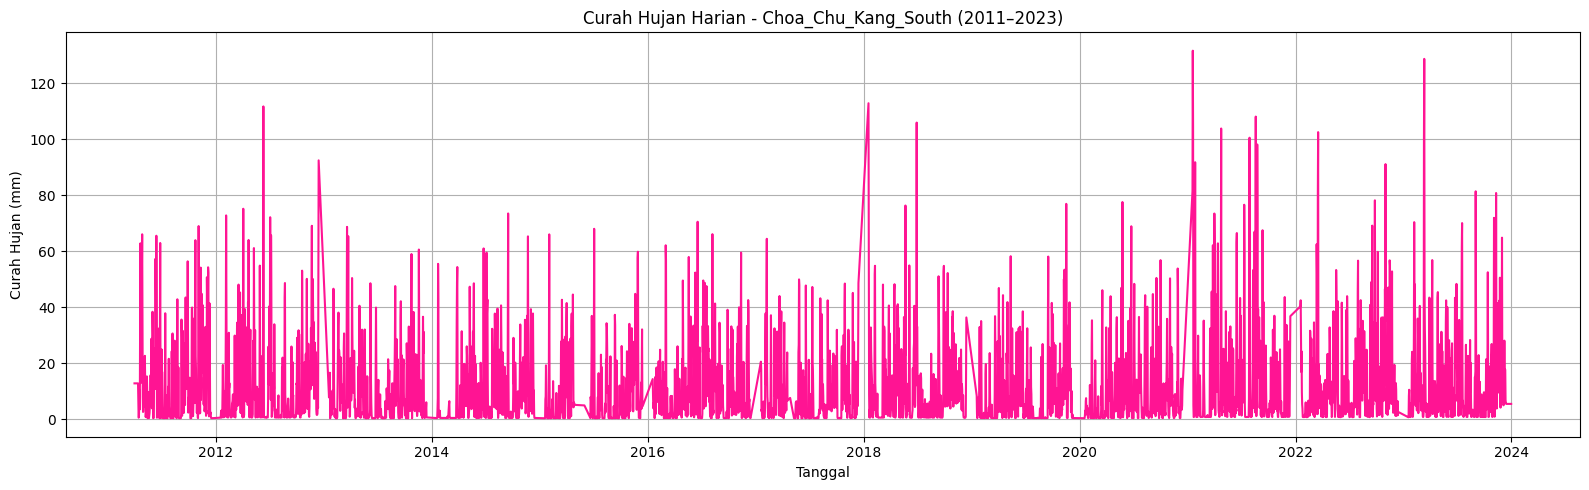

In [651]:
# Gabungkan semua tahun dan interpolasi
df_concat_choachus = pd.concat(all_choachus, ignore_index=True)
df_concat_choachus['rainfall_mm'] = (
    df_concat_choachus['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total 2011–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_choachus['Date'], df_concat_choachus['rainfall_mm'], color='deeppink')
plt.title("Curah Hujan Harian - Choa_Chu_Kang_South (2011–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_choachus[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Choa_Chu_Kang_South.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Choa_Chu_Kang_South.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Choa_Chu_Kang_South-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Choa_Chu_Kang_South-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2011-04-01                  12.865497
1 2011-04-02                  12.865497
2 2011-04-03                  12.865497
3 2011-04-04                  12.865497
4 2011-04-05                  12.865497


# Clementi

In [ ]:
clementi_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Clementi/"
clementi_csv_prefix = "Data_Gabungan_Lainnya_"
clementi_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

clementi_rain_info = {
    1980: 130, 1981: 190, 1982: 130, 1983: 130, 1984: 220,
    1985: 165, 1986: 130, 1987: 170, 1988: 140, 1989: 210,
    1990: 140, 1991: 130, 1992: 120, 1993: 120, 1994: 120,
    1995: 150, 1996: 190, 1997: 190, 1998: 230, 1999: 160,
    2000: 120, 2001: 380, 2002: 90, 2003: 140, 2004: 400,
    2005: 140, 2006: 250, 2007: 140, 2008: 120, 2009: 270,
    2010: 280, 2011: 130, 2012: 140, 2013: 130, 2014: 150,
    2015: 110, 2016: 130, 2017: 130, 2018: 180, 2019: 130,
    2020: 120, 2021: 190, 2022: 180, 2023: 270,
}

In [ ]:
all_clementi = []

for year, rain_max in clementi_rain_info.items():
    png_file = os.path.join(clementi_path, f"{clementi_png_prefix}{year}.png")
    csv_file = os.path.join(clementi_path, f"{clementi_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask warna biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Clementi: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke rainfall
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_clementi.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkorange', label='Clementi')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Clementi {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

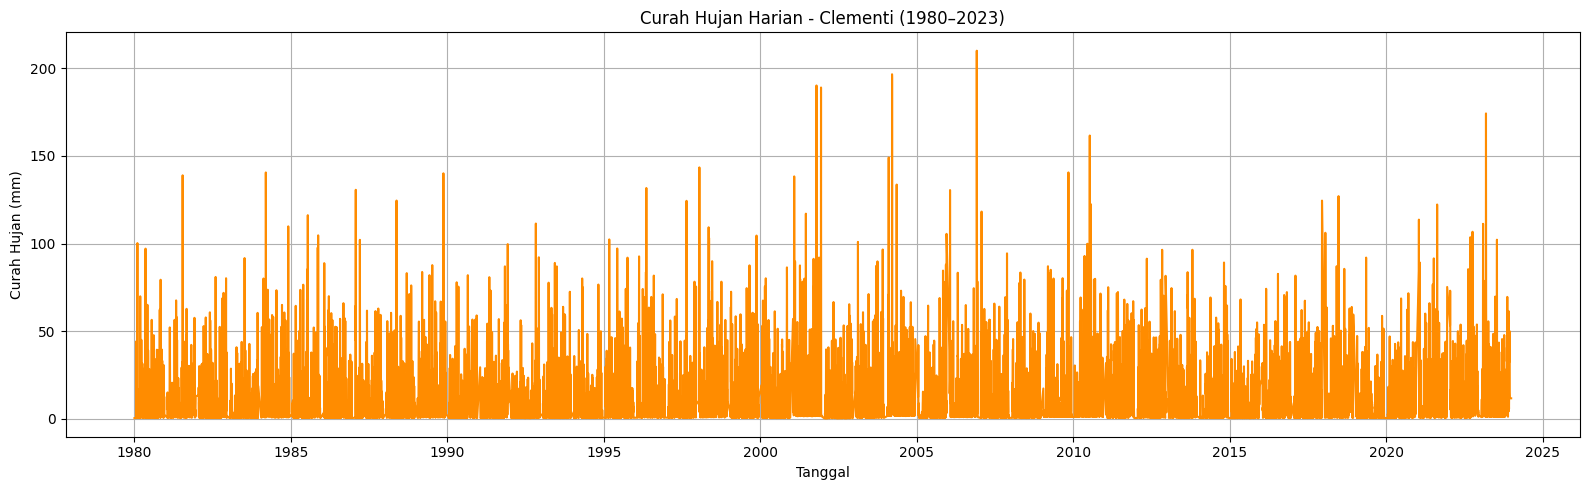

In [655]:
# Gabungkan dan interpolasi
df_concat_clementi = pd.concat(all_clementi, ignore_index=True)
df_concat_clementi['rainfall_mm'] = (
    df_concat_clementi['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total 1980–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_clementi['Date'], df_concat_clementi['rainfall_mm'], color='darkorange')
plt.title("Curah Hujan Harian - Clementi (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_clementi[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Clementi.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Clementi.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Clementi-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Clementi-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.506823
1 1980-01-02                   0.506823
2 1980-01-03                   0.506823
3 1980-01-04                   0.506823
4 1980-01-05                   0.506823


# East_Coast_Parkway

In [ ]:
ecp_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\East_Coast_Parkway/"
ecp_csv_prefix = "Data_Gabungan_Lainnya_"
ecp_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

ecp_rain_info = {
    2009: 80, 2010: 140, 2011: 180, 2012: 90, 2013: 110,
    2014: 80, 2015: 140, 2016: 180, 2017: 160,  2018: 80,
    2019: 150, 2020: 140, 2021: 210, 2022: 130, 2023: 300,
}

In [ ]:
all_ecp = []

for year, rain_max in ecp_rain_info.items():
    png_file = os.path.join(ecp_path, f"{ecp_png_prefix}{year}.png")
    csv_file = os.path.join(ecp_path, f"{ecp_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (garis horizontal terpanjang)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # jadikan (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"East_Coast_Parkway: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi x ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi y ke curah hujan (mm)
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan ke kalender penuh dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_ecp.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='steelblue', label='East_Coast_Parkway')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - East_Coast_Parkway {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

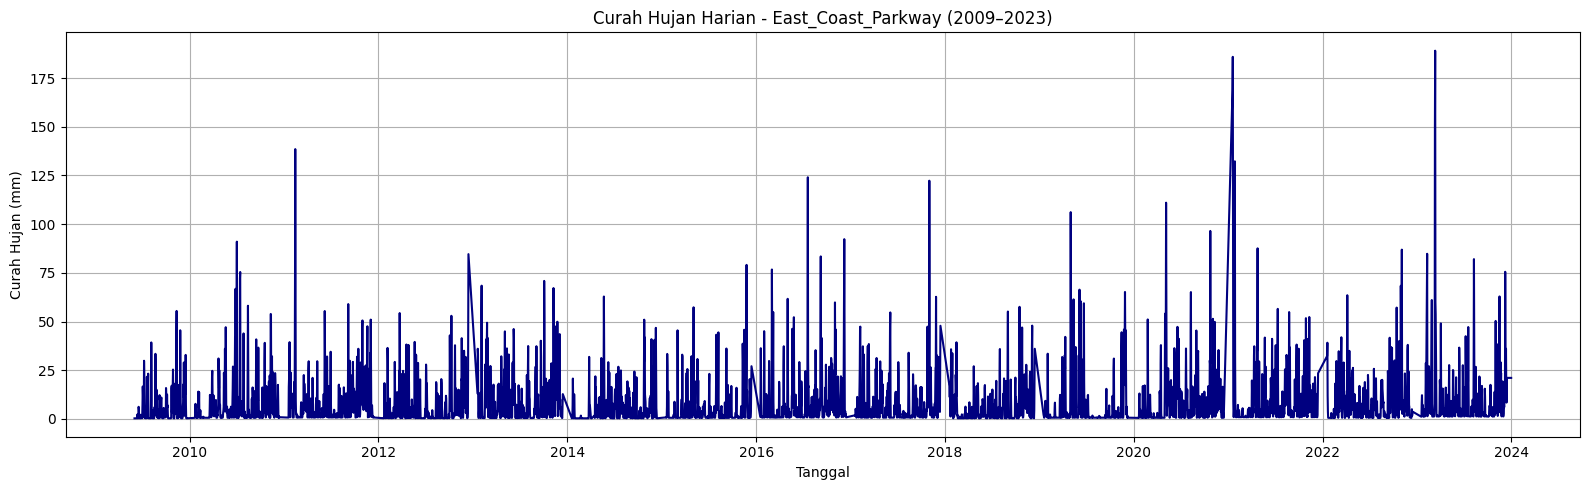

In [88]:
# Gabungkan dan interpolasi
df_concat_ecp = pd.concat(all_ecp, ignore_index=True)
df_concat_ecp['rainfall_mm'] = (
    df_concat_ecp['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan semua tahun
plt.figure(figsize=(16, 5))
plt.plot(df_concat_ecp['Date'], df_concat_ecp['rainfall_mm'], color='navy')
plt.title("Curah Hujan Harian - East_Coast_Parkway (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_ecp[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-East_Coast_Parkway.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-East_Coast_Parkway.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/East_Coast_Parkway-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/East_Coast_Parkway-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-06-01                   0.311891
1 2009-06-02                   0.311891
2 2009-06-03                   0.311891
3 2009-06-04                   0.311891
4 2009-06-05                   0.311891


# Jurong_Island

In [ ]:
jurongisland_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Jurong_Island/"
jurongisland_csv_prefix = "Data_Gabungan_Lainnya_"
jurongisland_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

jurongisland_rain_info = {
    2011: 85, 2012: 140, 2013: 160, 2014: 190, 2015: 170,
    2016: 175, 2017: 105,  2018: 200, 2019: 120,
    2020: 260, 2021: 160, 2022: 165, 2023: 130,
}

In [ ]:
all_jurongisland = []

for year, rain_max in jurongisland_rain_info.items():
    png_file = os.path.join(jurongisland_path, f"{jurongisland_png_prefix}{year}.png")
    csv_file = os.path.join(jurongisland_path, f"{jurongisland_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Jurong_Island: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_jurongisland.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='forestgreen', label='Jurong_Island')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Jurong_Island {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

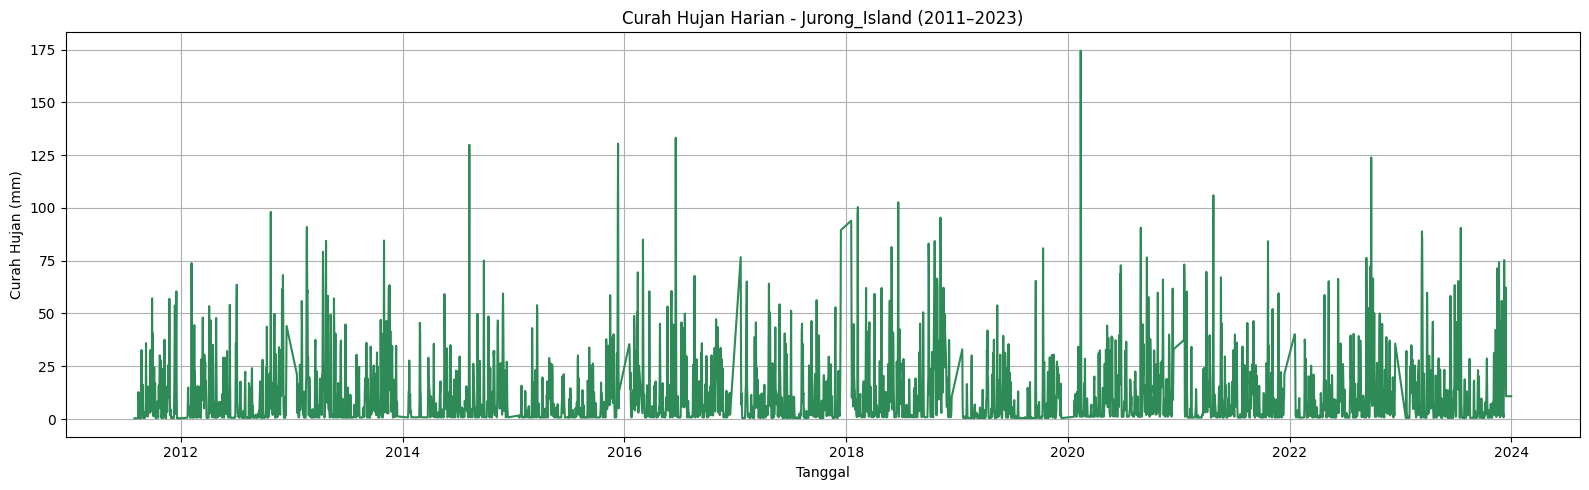

In [92]:
# Gabungkan dan interpolasi
df_concat_jurongisland = pd.concat(all_jurongisland, ignore_index=True)
df_concat_jurongisland['rainfall_mm'] = (
    df_concat_jurongisland['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan 2011–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_jurongisland['Date'], df_concat_jurongisland['rainfall_mm'], color='seagreen')
plt.title("Curah Hujan Harian - Jurong_Island (2011–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_jurongisland[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_Island.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_Island.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Jurong_Island-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Jurong_Island-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2011-08-01                   0.360624
1 2011-08-02                   0.360624
2 2011-08-03                   0.360624
3 2011-08-04                   0.360624
4 2011-08-05                   0.360624


# Jurong_Pier

In [ ]:
jurongpier_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Jurong_Pier/"
jurongpier_csv_prefix = "Data_Gabungan_Lainnya_"
jurongpier_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

jurongpier_rain_info = {
    1980: 120, 1981: 130, 1982: 90, 1983: 90, 1984: 190,
    1985: 180, 1986: 150, 1987: 150, 1988: 130, 1989: 130,
    1990: 125, 1991: 150, 1992: 150, 1993: 130, 1994: 150,
    1995: 190, 1996: 140, 1997: 170, 1998: 220, 1999: 220,
    2000: 170, 2001: 220, 2002: 130, 2003: 200, 2004: 330,
    2005: 130, 2006: 230, 2007: 190, 2008: 210, 2009: 130,
    2010: 155, 2011: 125, 2012: 130, 2013: 130, 2014: 125,
    2015: 100, 2016: 280, 2017: 130, 2018: 130, 2019: 170,
    2020: 140, 2021: 140, 2022: 120, 2023: 140,
}

In [682]:
all_jurongpier = []

for year, rain_max in jurongpier_rain_info.items():
    png_file = os.path.join(jurongpier_path, f"{jurongpier_png_prefix}{year}.png")
    csv_file = os.path.join(jurongpier_path, f"{jurongpier_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Jurong_Pier: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_jurongpier.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkblue', label='Jurong_Pier')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Jurong_Pier {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

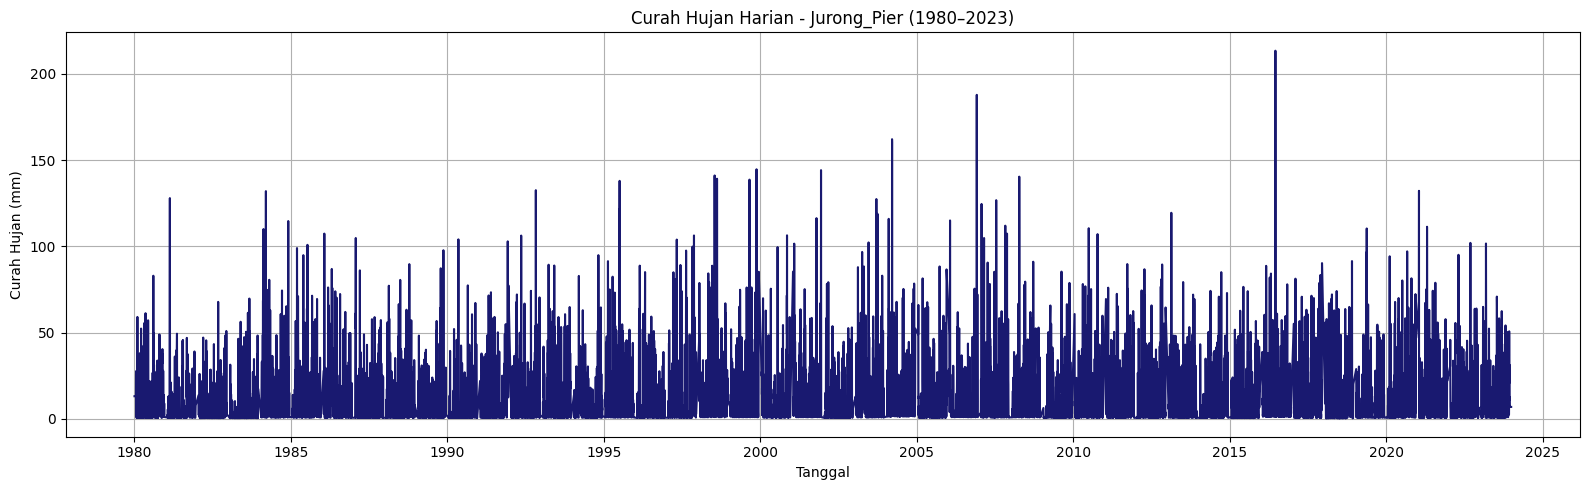

In [96]:
# Gabungkan dan interpolasi
df_concat_jurongpier = pd.concat(all_jurongpier, ignore_index=True)
df_concat_jurongpier['rainfall_mm'] = (
    df_concat_jurongpier['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan semua tahun
plt.figure(figsize=(16, 5))
plt.plot(df_concat_jurongpier['Date'], df_concat_jurongpier['rainfall_mm'], color='midnightblue')
plt.title("Curah Hujan Harian - Jurong_Pier (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_jurongpier[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_Pier.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_Pier.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Jurong_Pier-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Jurong_Pier-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                  13.073424
1 1980-01-02                  13.073424
2 1980-01-03                  13.073424
3 1980-01-04                  13.073424
4 1980-01-05                  13.073424


# Jurong_West

In [ ]:
jurongwest_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Jurong_West/"
jurongwest_csv_prefix = "Data_Gabungan_Lainnya_"
jurongwest_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

jurongwest_rain_info = {
    1980: 190, 1981: 200, 1982: 160, 1983: 120, 1984: 230,
    1985: 230, 1986: 200, 1987: 160, 1988: 130, 1989: 140,
    1990: 230, 1991: 120, 1992: 125, 1993: 220, 1994: 220,
    1995: 140, 1996: 100, 1997: 100, 1998: 120, 1999: 150,
    2000: 170, 2001: 300, 2002: 150, 2003: 150, 2004: 320,
    2005: 130, 2006: 170, 2007: 140, 2008: 150, 2009: 180,
    2010: 200, 2011: 150, 2012: 150, 2013: 160, 2014: 90,
    2015: 150, 2016: 230, 2017: 110, 2018: 190, 2019: 100,
    2020: 110, 2021: 180, 2022: 180, 2023: 190,
}

In [ ]:
all_jurongwest = []

for year, rain_max in jurongwest_rain_info.items():
    png_file = os.path.join(jurongwest_path, f"{jurongwest_png_prefix}{year}.png")
    csv_file = os.path.join(jurongwest_path, f"{jurongwest_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Jurong_West: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_jurongwest.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkred', label='Jurong_West')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Jurong_West {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

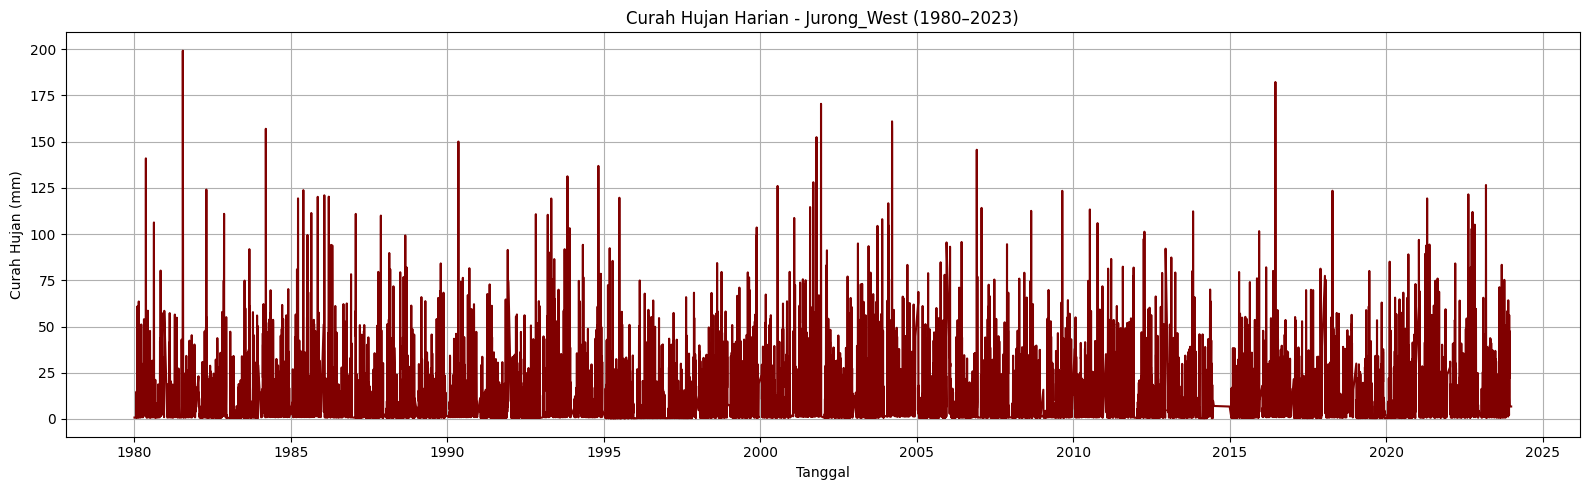

In [100]:
# Gabungkan semua tahun dan interpolasi
df_concat_jurongwest = pd.concat(all_jurongwest, ignore_index=True)
df_concat_jurongwest['rainfall_mm'] = (
    df_concat_jurongwest['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total 1980–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_jurongwest['Date'], df_concat_jurongwest['rainfall_mm'], color='maroon')
plt.title("Curah Hujan Harian - Jurong_West (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_jurongwest[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_West.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Jurong_West.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Jurong_West-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Jurong_West-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.740741
1 1980-01-02                   0.740741
2 1980-01-03                   0.740741
3 1980-01-04                   0.740741
4 1980-01-05                   0.740741


# Kent_Ridge

In [ ]:
kentridge_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Kent_Ridge/"
kentridge_csv_prefix = "Data_Gabungan_Lainnya_"
kentridge_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

kentridge_rain_info = {
    2009: 100, 2010: 150, 2011: 140, 2012: 180, 2013: 160,
    2014: 100, 2015: 110, 2016: 170, 2017: 150,  2018: 120,
    2019: 115, 2020: 190, 2021: 210, 2022: 190, 2023: 270,
}

In [ ]:
all_kentridge = []

for year, rain_max in kentridge_rain_info.items():
    png_file = os.path.join(kentridge_path, f"{kentridge_png_prefix}{year}.png")
    csv_file = os.path.join(kentridge_path, f"{kentridge_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal terpanjang)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru (curah hujan)
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Kent_Ridge: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke rainfall
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_kentridge.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumseagreen', label='Kent_Ridge')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Kent_Ridge {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

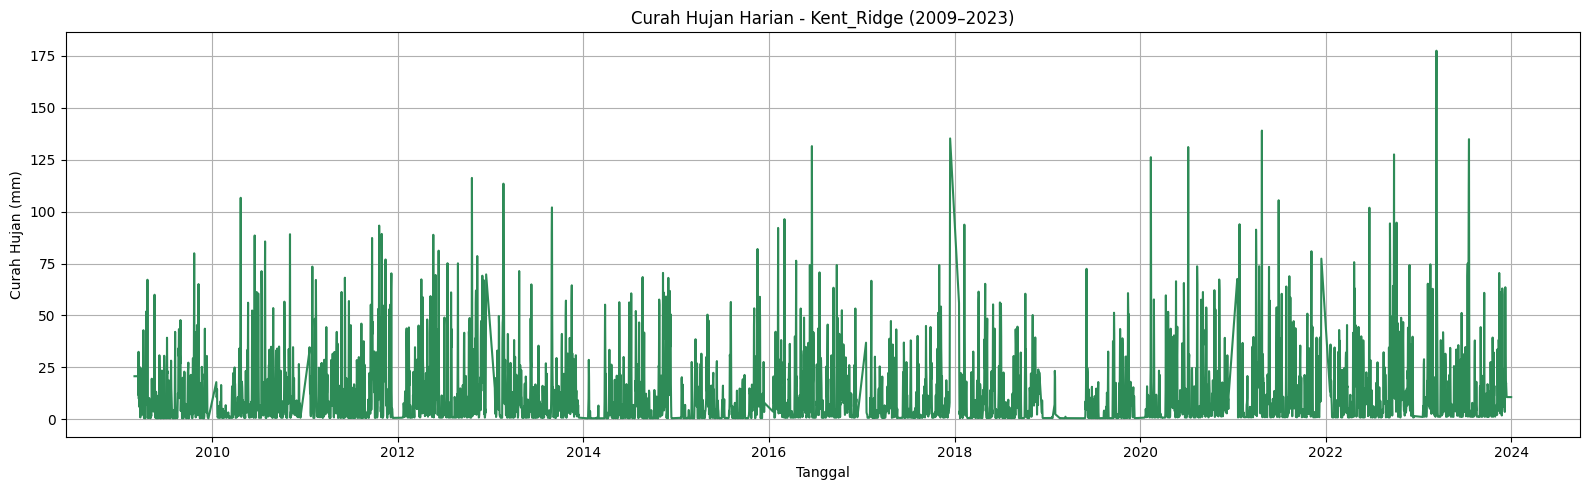

In [104]:
# Gabungkan semua tahun dan interpolasi
df_concat_kentridge = pd.concat(all_kentridge, ignore_index=True)
df_concat_kentridge['rainfall_mm'] = (
    df_concat_kentridge['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_kentridge['Date'], df_concat_kentridge['rainfall_mm'], color='seagreen')
plt.title("Curah Hujan Harian - Kent_Ridge (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_kentridge[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Kent_Ridge.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Kent_Ridge.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Kent_Ridge-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Kent_Ridge-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-03-01                  20.684427
1 2009-03-02                  20.684427
2 2009-03-03                  20.684427
3 2009-03-04                  20.684427
4 2009-03-05                  20.684427


# Kranji_Reservoir

In [ ]:
kranji_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Kranji_Reservoir/"
kranji_csv_prefix = "Data_Gabungan_Lainnya_"
kranji_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

kranji_rain_info = {
    1980: 160, 1981: 130, 1982: 120, 1983: 200, 1984: 200,
    1985: 150, 1986: 150, 1987: 300, 1988: 210, 1989: 110,
    1990: 160, 1991: 110, 1992: 140, 1993: 100, 1994: 140,
    1995: 130, 1996: 150, 1997: 150, 1998: 110, 1999: 155,
    2000: 220, 2001: 180, 2002: 120, 2003: 130, 2004: 270,
    2005: 220, 2006: 300, 2007: 200, 2008: 130, 2009: 200,
    2010: 150, 2011: 90, 2012: 90, 2013: 130, 2014: 140,
    2015: 95, 2016: 130, 2017: 150, 2018: 125, 2019: 135,
    2020: 125, 2021: 210, 2022: 210, 2023: 210,
}

In [684]:
all_kranji = []

for year, rain_max in kranji_rain_info.items():
    png_file = os.path.join(kranji_path, f"{kranji_png_prefix}{year}.png")
    csv_file = os.path.join(kranji_path, f"{kranji_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Kranji_Reservoir: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_kranji.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkcyan', label='Kranji_Reservoir')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Kranji_Reservoir {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

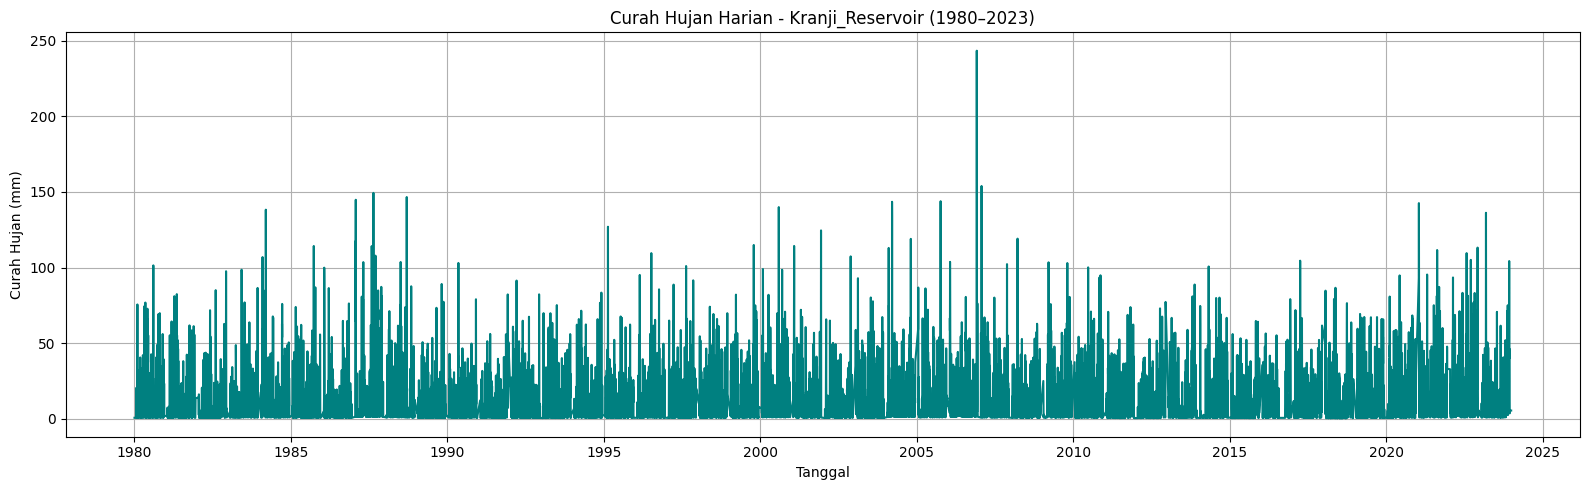

In [108]:
# Gabungkan dan interpolasi
df_concat_kranji = pd.concat(all_kranji, ignore_index=True)
df_concat_kranji['rainfall_mm'] = (
    df_concat_kranji['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_kranji['Date'], df_concat_kranji['rainfall_mm'], color='teal')
plt.title("Curah Hujan Harian - Kranji_Reservoir (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_kranji[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Kranji_Reservoir.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Kranji_Reservoir.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Kranji_Reservoir-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Kranji_Reservoir-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.623782
1 1980-01-02                   0.623782
2 1980-01-03                   0.623782
3 1980-01-04                   0.623782
4 1980-01-05                   0.623782


# Lim_Chu_Kang

In [ ]:
limchukang_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Lim_Chu_Kang/"
limchukang_csv_prefix = "Data_Gabungan_Lainnya_"
limchukang_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

limchukang_rain_info = {
    2010: 150, 2011: 320, 2012: 110, 2013: 155,
    2014: 150, 2015: 110, 2016: 105, 2017: 210,  2018: 130,
    2019: 180, 2020: 115, 2021: 130, 2022: 150, 2023: 160,
}

In [ ]:
all_limchukang = []

for year, rain_max in limchukang_rain_info.items():
    png_file = os.path.join(limchukang_path, f"{limchukang_png_prefix}{year}.png")
    csv_file = os.path.join(limchukang_path, f"{limchukang_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Lim_Chu_Kang: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi x ke indeks hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_limchukang.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='saddlebrown', label='Lim_Chu_Kang')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Lim_Chu_Kang {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

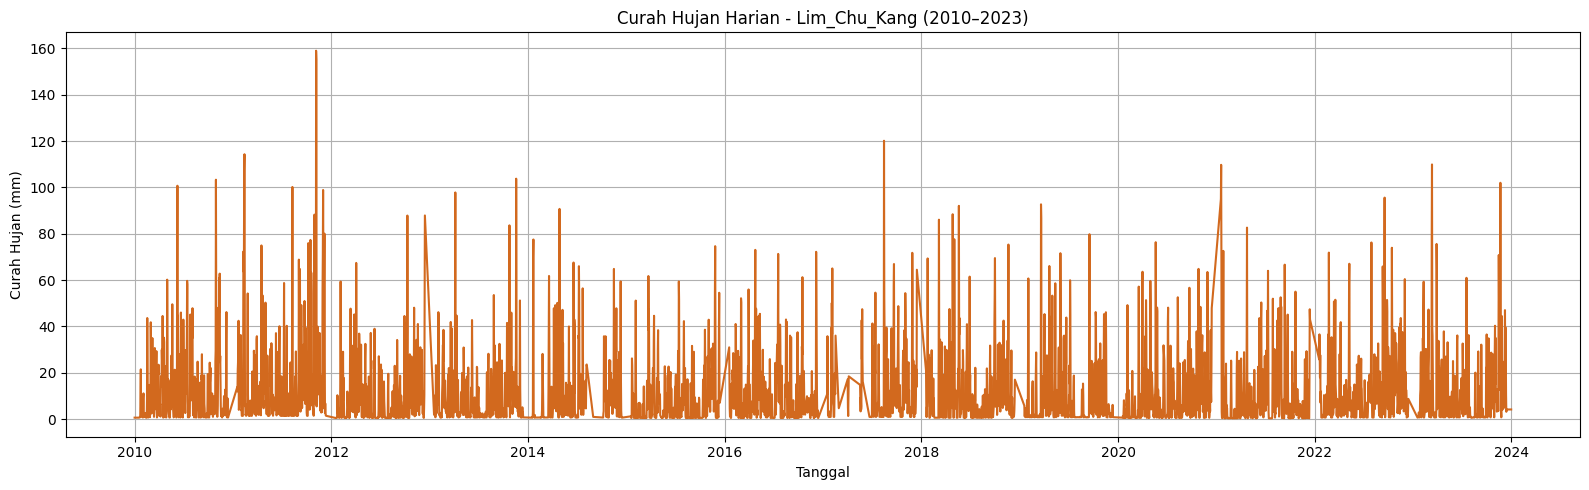

In [112]:
# Gabungkan dan interpolasi
df_concat_limchukang = pd.concat(all_limchukang, ignore_index=True)
df_concat_limchukang['rainfall_mm'] = (
    df_concat_limchukang['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_limchukang['Date'], df_concat_limchukang['rainfall_mm'], color='chocolate')
plt.title("Curah Hujan Harian - Lim_Chu_Kang (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_limchukang[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Lim_Chu_Kang.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Lim_Chu_Kang.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Lim_Chu_Kang-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Lim_Chu_Kang-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-01-01                   0.584795
1 2010-01-02                   0.584795
2 2010-01-03                   0.584795
3 2010-01-04                   0.584795
4 2010-01-05                   0.584795


# Lower_Peirce_Reservoir

In [ ]:
lowerpeirce_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Lower_Peirce_Reservoir/"
lowerpeirce_csv_prefix = "Data_Gabungan_Lainnya_"
lowerpeirce_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

lowerpeirce_rain_info = {
    2010: 380, 2011: 120, 2012: 120, 2013: 230,
    2014: 200, 2015: 100, 2016: 130, 2017: 105,  2018: 155,
    2019: 120, 2020: 125, 2021: 160, 2022: 170, 2023: 230,
}

In [ ]:
all_lowerpeirce = []

for year, rain_max in lowerpeirce_rain_info.items():
    png_file = os.path.join(lowerpeirce_path, f"{lowerpeirce_png_prefix}{year}.png")
    csv_file = os.path.join(lowerpeirce_path, f"{lowerpeirce_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva hujan) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # urutkan sebagai (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Lower_Peirce_Reservoir: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Mapping pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Mapping pixel Y ke nilai curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan kalender lengkap
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_lowerpeirce.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumblue', label='Lower_Peirce_Reservoir')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Lower_Peirce_Reservoir {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

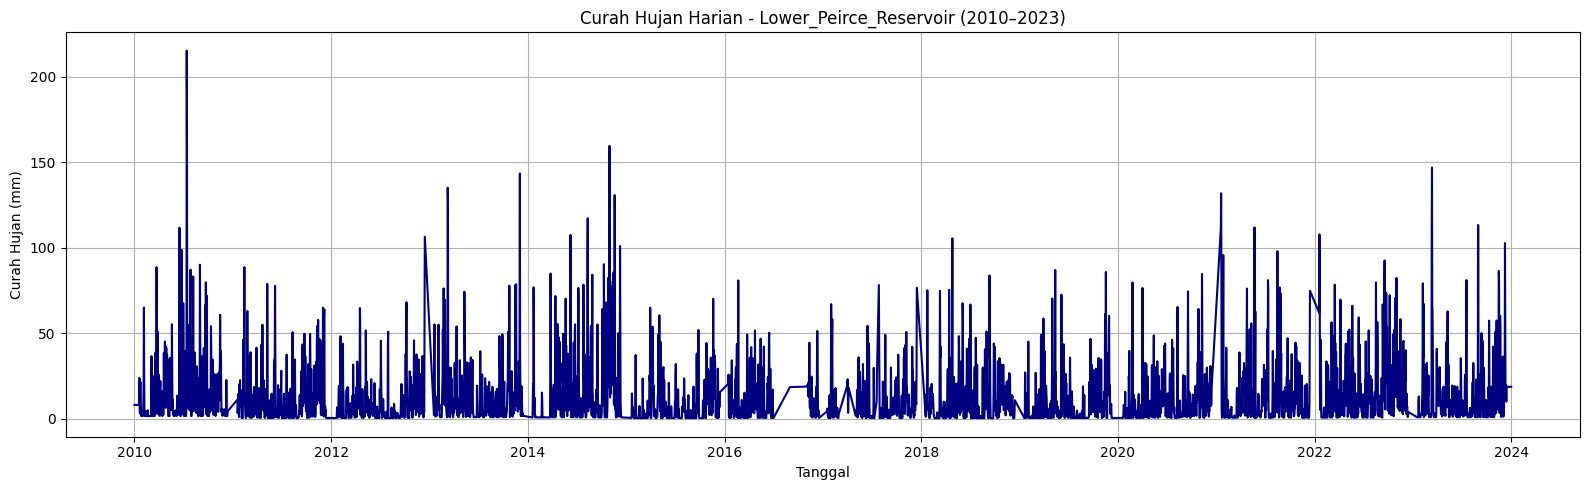

In [116]:
# Gabungkan semua tahun dan lakukan interpolasi
df_concat_lowerpeirce = pd.concat(all_lowerpeirce, ignore_index=True)
df_concat_lowerpeirce['rainfall_mm'] = (
    df_concat_lowerpeirce['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_lowerpeirce['Date'], df_concat_lowerpeirce['rainfall_mm'], color='navy')
plt.title("Curah Hujan Harian - Lower_Peirce_Reservoir (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_lowerpeirce[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Lower_Peirce_Reservoir.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Lower_Peirce_Reservoir.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Lower_Peirce_Reservoir-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Lower_Peirce_Reservoir-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-01-01                   8.148148
1 2010-01-02                   8.148148
2 2010-01-03                   8.148148
3 2010-01-04                   8.148148
4 2010-01-05                   8.148148


# Macritchie_Reservoir

In [ ]:
macritchie_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Macritchie_Reservoir/"
macritchie_csv_prefix = "Data_Gabungan_Lainnya_"
macritchie_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

macritchie_rain_info = {
    1980: 130, 1981: 120, 1982: 180, 1983: 120, 1984: 250,
    1985: 140, 1986: 155, 1987: 170, 1988: 135, 1989: 220,
    1990: 195, 1991: 120, 1992: 155, 1993: 105, 1994: 130,
    1995: 210, 1996: 160, 1997: 190, 1998: 120, 1999: 160,
    2000: 115, 2001: 240, 2002: 100, 2003: 170, 2004: 380,
    2005: 190, 2006: 215, 2007: 180, 2008: 140, 2009: 150,
    2010: 440, 2011: 130, 2012: 120, 2013: 145, 2014: 120,
    2015: 80, 2016: 130, 2017: 110, 2018: 220, 2019: 100,
    2020: 140, 2021: 200, 2022: 110, 2023: 230,
}

In [ ]:
all_macritchie = []

for year, rain_max in macritchie_rain_info.items():
    png_file = os.path.join(macritchie_path, f"{macritchie_png_prefix}{year}.png")
    csv_file = os.path.join(macritchie_path, f"{macritchie_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru dan hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Temukan sumbu X (horizontal)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Macritchie_Reservoir: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Data hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_macritchie.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='slateblue', label='Macritchie_Reservoir')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Macritchie_Reservoir {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

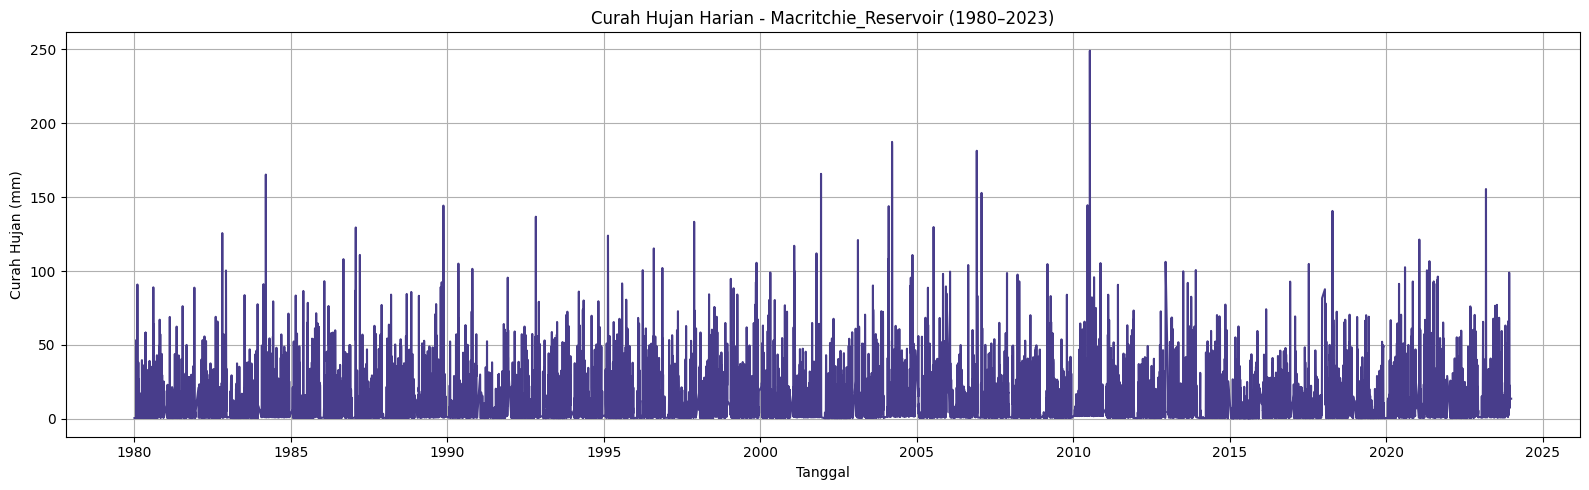

In [120]:
# Gabungkan dan interpolasi
df_concat_macritchie = pd.concat(all_macritchie, ignore_index=True)
df_concat_macritchie['rainfall_mm'] = (
    df_concat_macritchie['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan 2009–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_macritchie['Date'], df_concat_macritchie['rainfall_mm'], color='darkslateblue')
plt.title("Curah Hujan Harian - Macritchie_Reservoir (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_macritchie[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Macritchie_Reservoir.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Macritchie_Reservoir.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Macritchie_Reservoir-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Macritchie_Reservoir-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.506823
1 1980-01-02                   0.506823
2 1980-01-03                   0.506823
3 1980-01-04                   0.506823
4 1980-01-05                   0.506823


# Mandai

In [ ]:
mandai_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Mandai/"
mandai_csv_prefix = "Data_Gabungan_Lainnya_"
mandai_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

mandai_rain_info = {
    1980: 140, 1981: 130, 1982: 125, 1983: 100, 1984: 250,
    1985: 190, 1986: 200, 1987: 160, 1988: 155, 1989: 140,
    1990: 200, 1991: 160, 1992: 160, 1993: 120, 1994: 175,
    1995: 160, 1996: 160, 1997: 160, 1998: 100, 1999: 150,
    2000: 100, 2001: 185, 2002: 130, 2003: 200, 2004: 330,
    2005: 220, 2006: 280, 2007: 230, 2008: 140, 2009: 130,
    2010: 150, 2011: 18, 2013: 110, 2014: 150,
    2015: 130, 2016: 130, 2017: 205, 2018: 130, 2019: 130,
    2020: 150, 2021: 400, 2022: 150, 2023: 220,
}

In [ ]:
all_mandai = []

for year, rain_max in mandai_rain_info.items():
    png_file = os.path.join(mandai_path, f"{mandai_png_prefix}{year}.png")
    csv_file = os.path.join(mandai_path, f"{mandai_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru dan hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Temukan sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Mandai: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal di CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_mandai.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkorange', label='Mandai')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Mandai {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

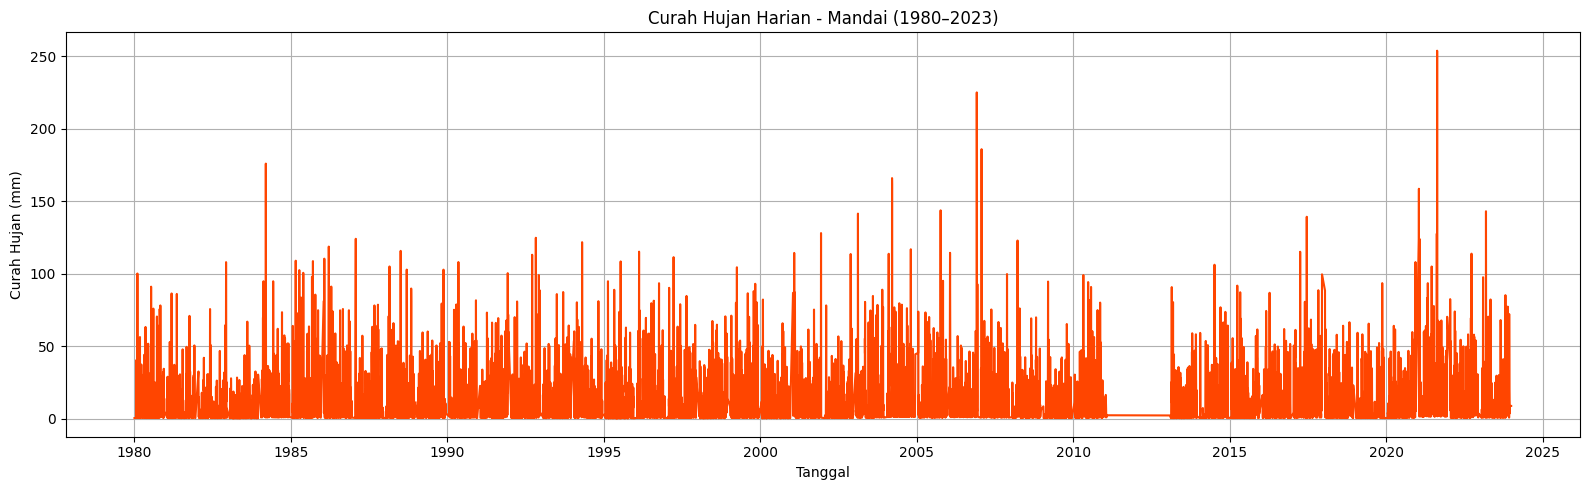

In [124]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_mandai = pd.concat(all_mandai, ignore_index=True)
df_concat_mandai['rainfall_mm'] = (
    df_concat_mandai['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_mandai['Date'], df_concat_mandai['rainfall_mm'], color='orangered')
plt.title("Curah Hujan Harian - Mandai (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_mandai[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Mandai.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Mandai.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Mandai-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Mandai-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.545809
1 1980-01-02                   0.545809
2 1980-01-03                   0.545809
3 1980-01-04                   0.545809
4 1980-01-05                   0.545809


# Marina_Barrage

In [ ]:
marina_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Marina_Barrage/"
marina_csv_prefix = "Data_Gabungan_Lainnya_"
marina_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

marina_rain_info = {
    2010: 150, 2011: 90, 2012: 90, 2013: 100,
    2014: 105, 2015: 120, 2016: 140, 2017: 140,  2018: 140,
    2019: 100, 2020: 105, 2021: 180, 2022: 80, 2023: 310,
}

In [ ]:
all_marina = []

for year, rain_max in marina_rain_info.items():
    png_file = os.path.join(marina_path, f"{marina_png_prefix}{year}.png")
    csv_file = os.path.join(marina_path, f"{marina_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik dari kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Marina_Barrage: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel x ke indeks hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel y ke nilai curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan kalender dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_marina.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumturquoise', label='Marina_Barrage')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Marina_Barrage {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

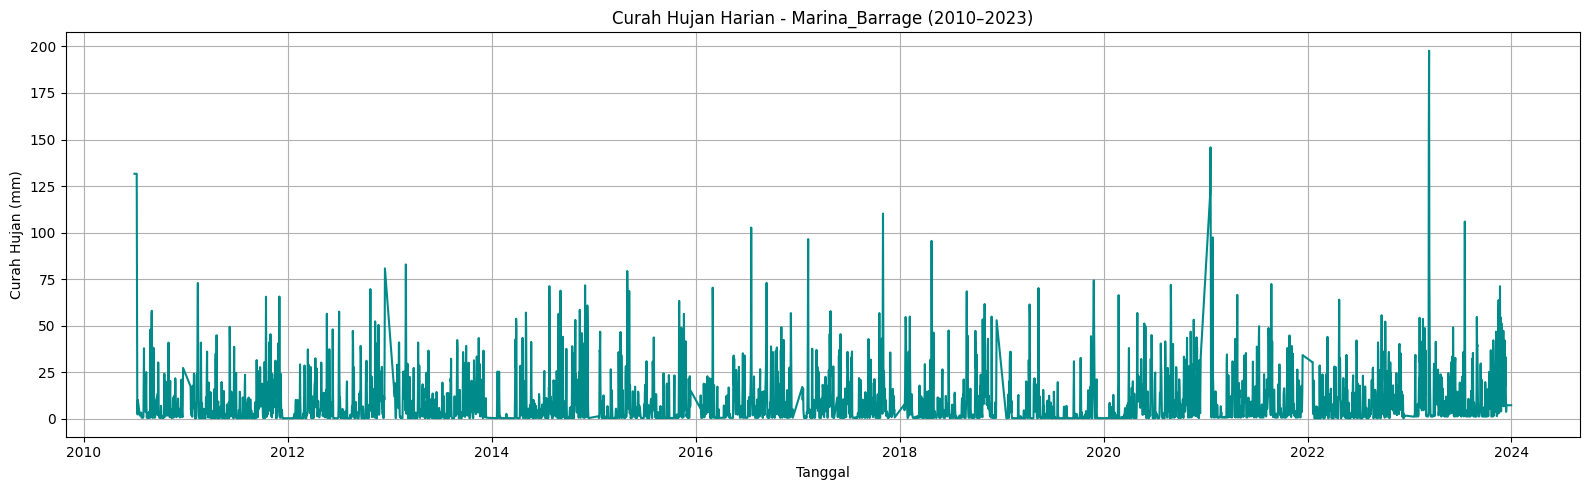

In [128]:
# Gabungkan semua tahun dan interpolasi
df_concat_marina = pd.concat(all_marina, ignore_index=True)
df_concat_marina['rainfall_mm'] = (
    df_concat_marina['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_marina['Date'], df_concat_marina['rainfall_mm'], color='darkcyan')
plt.title("Curah Hujan Harian - Marina_Barrage (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_marina[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Marina_Barrage.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Marina_Barrage.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Marina_Barrage-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Marina_Barrage-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-07-01                 131.630449
1 2010-07-02                 131.630449
2 2010-07-03                 131.630449
3 2010-07-04                 131.630449
4 2010-07-05                 131.630449


# Marine_Parade

In [ ]:
marineparade_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Marine_Parade/"
marineparade_csv_prefix = "Data_Gabungan_Lainnya_"
marineparade_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

marineparade_rain_info = {
    2009: 75, 2010: 345, 2011: 100, 2012: 95, 2013: 120,
    2014: 130, 2015: 100, 2016: 120, 2017: 125, 2018: 90,
    2019: 105, 2020: 130, 2021: 230, 2022: 110, 2023: 310,
}

In [ ]:
all_marineparade = []

for year, rain_max in marineparade_rain_info.items():
    png_file = os.path.join(marineparade_path, f"{marineparade_png_prefix}{year}.png")
    csv_file = os.path.join(marineparade_path, f"{marineparade_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Marine_Parade: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan kalender dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_marineparade.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumorchid', label='Marine_Parade')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Marine_Parade {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

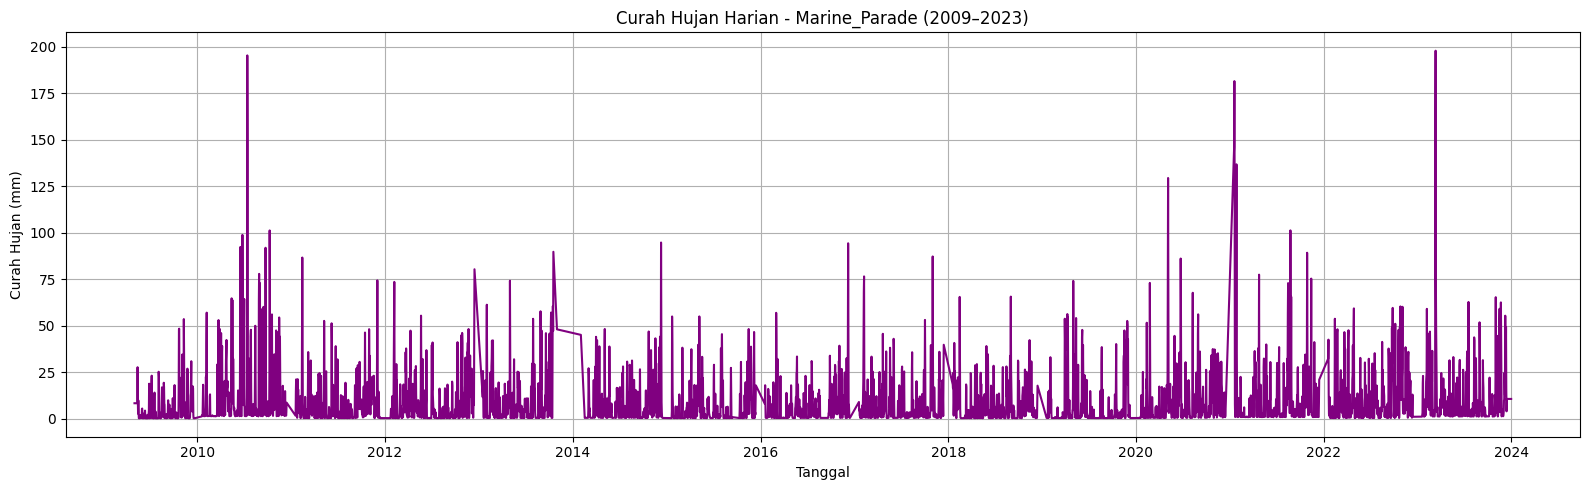

In [132]:
# Gabungkan dan interpolasi
df_concat_marineparade = pd.concat(all_marineparade, ignore_index=True)
df_concat_marineparade['rainfall_mm'] = (
    df_concat_marineparade['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_marineparade['Date'], df_concat_marineparade['rainfall_mm'], color='purple')
plt.title("Curah Hujan Harian - Marine_Parade (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_marineparade[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Marine_Parade.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Marine_Parade.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Marine_Parade-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Marine_Parade-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-05-01                   8.411829
1 2009-05-02                   8.411829
2 2009-05-03                   8.411829
3 2009-05-04                   8.411829
4 2009-05-05                   8.411829


# Newton

In [ ]:
newton_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Newton/"
newton_csv_prefix = "Data_Gabungan_Lainnya_"
newton_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

newton_rain_info = {
    2009: 68, 2010: 235, 2011: 260, 2012: 125, 2013: 130,
    2014: 125, 2015: 120, 2016: 130, 2017: 125,  2018: 80,
    2019: 80, 2020: 85, 2021: 145, 2022: 130, 2023: 220,
}

In [ ]:
all_newton = []

for year, rain_max in newton_rain_info.items():
    png_file = os.path.join(newton_path, f"{newton_png_prefix}{year}.png")
    csv_file = os.path.join(newton_path, f"{newton_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Newton: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_newton.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkmagenta', label='Newton')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Newton {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

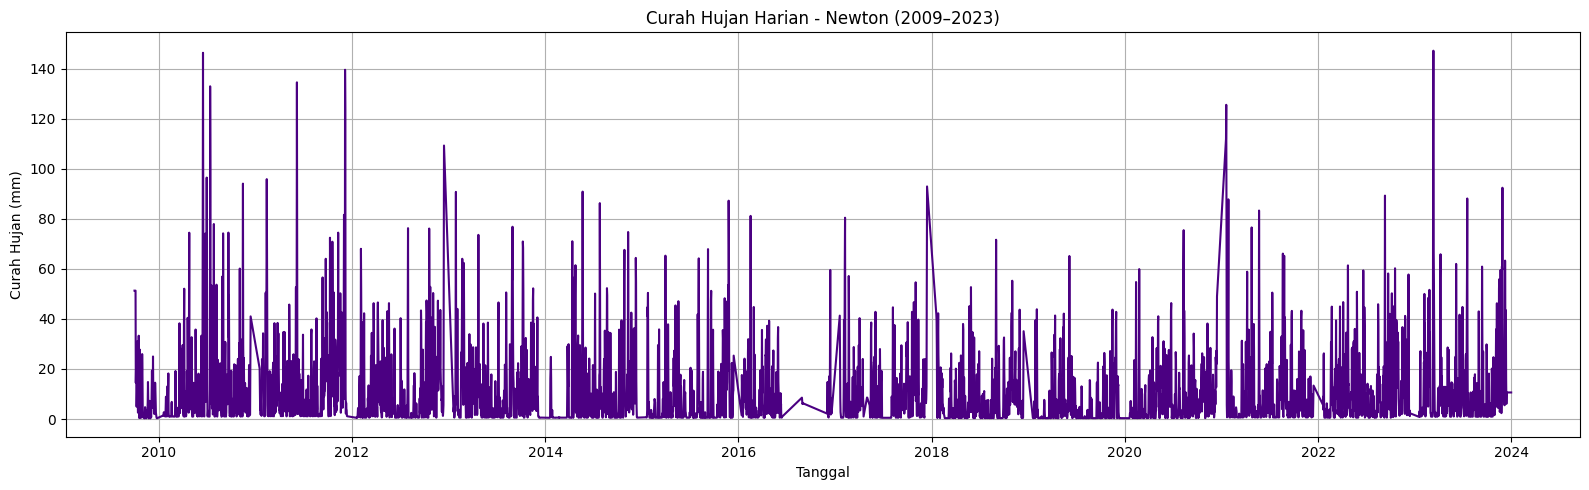

In [136]:
# Gabungkan semua tahun dan interpolasi
df_concat_newton = pd.concat(all_newton, ignore_index=True)
df_concat_newton['rainfall_mm'] = (
    df_concat_newton['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan 2009–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_newton['Date'], df_concat_newton['rainfall_mm'], color='indigo')
plt.title("Curah Hujan Harian - Newton (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_newton[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Newton.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Newton.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Newton-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Newton-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-10-01                  51.332466
1 2009-10-02                  51.332466
2 2009-10-03                  51.332466
3 2009-10-04                  51.332466
4 2009-10-05                  51.332466


# Nicoll_Highway

In [ ]:
nicoll_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Nicoll_Highway/"
nicoll_csv_prefix = "Data_Gabungan_Lainnya_"
nicoll_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

nicoll_rain_info = {
    2010: 70, 2011: 85, 2012: 100, 2013: 110,
    2014: 125, 2015: 90, 2016: 125, 2017: 170,  2018: 130,
    2019: 130, 2020: 170, 2021: 150, 2022: 110, 2023: 250,
}

In [ ]:
all_nicoll = []

for year, rain_max in nicoll_rain_info.items():
    png_file = os.path.join(nicoll_path, f"{nicoll_png_prefix}{year}.png")
    csv_file = os.path.join(nicoll_path, f"{nicoll_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask warna biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah jadi (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Nicoll_Highway: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan kalender lengkap
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_nicoll.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='teal', label='Nicoll_Highway')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Nicoll_Highway {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

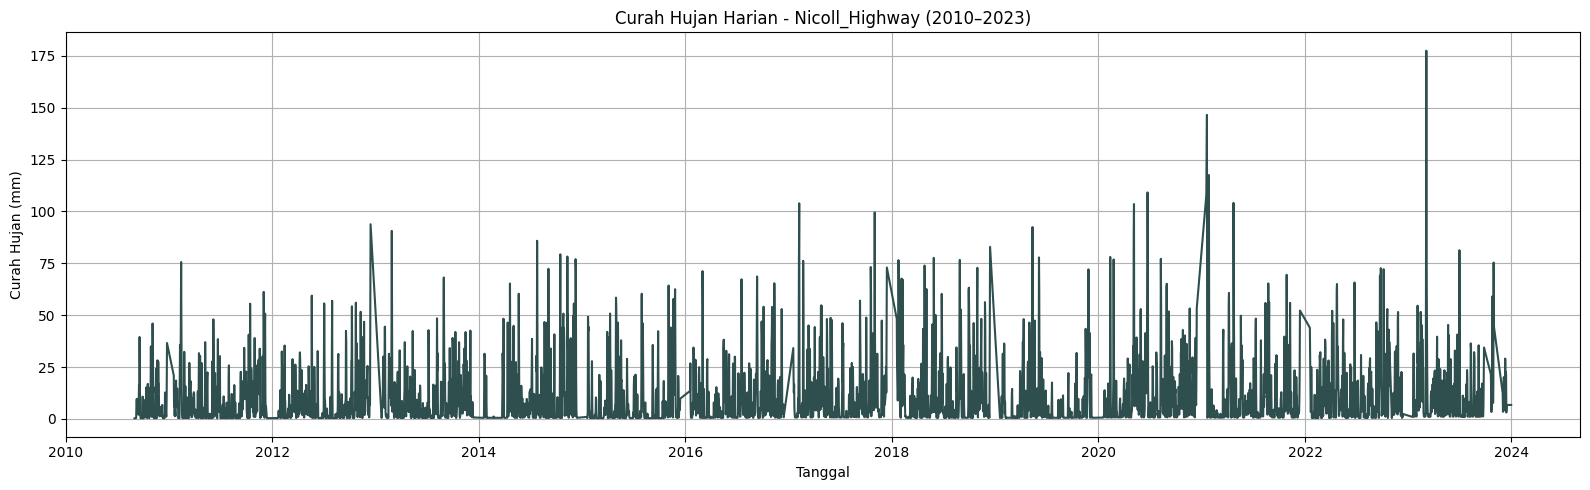

In [140]:
# Gabungkan semua tahun dan interpolasi
df_concat_nicoll = pd.concat(all_nicoll, ignore_index=True)
df_concat_nicoll['rainfall_mm'] = (
    df_concat_nicoll['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_nicoll['Date'], df_concat_nicoll['rainfall_mm'], color='darkslategray')
plt.title("Curah Hujan Harian - Nicoll_Highway (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_nicoll[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Nicoll_Highway.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Nicoll_Highway.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Nicoll_Highway-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Nicoll_Highway-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-09-01                   0.297714
1 2010-09-02                   0.297714
2 2010-09-03                   0.297714
3 2010-09-04                   0.297714
4 2010-09-05                   0.297714


# Pasir_Panjang

In [ ]:
pasirpanjang_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Pasir_Panjang/"
pasirpanjang_csv_prefix = "Data_Gabungan_Lainnya_"
pasirpanjang_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

pasirpanjang_rain_info = {
    2010: 150, 2011: 110, 2012: 130, 2013: 120,
    2014: 80, 2015: 100, 2016: 170, 2017: 120,  2018: 115,
    2019: 90, 2020: 160, 2021: 200, 2022: 150, 2023: 225,
}

In [ ]:
all_pasirpanjang = []

for year, rain_max in pasirpanjang_rain_info.items():
    png_file = os.path.join(pasirpanjang_path, f"{pasirpanjang_png_prefix}{year}.png")
    csv_file = os.path.join(pasirpanjang_path, f"{pasirpanjang_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Pasir_Panjang: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_pasirpanjang.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkorange', label='Pasir_Panjang')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Pasir_Panjang {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

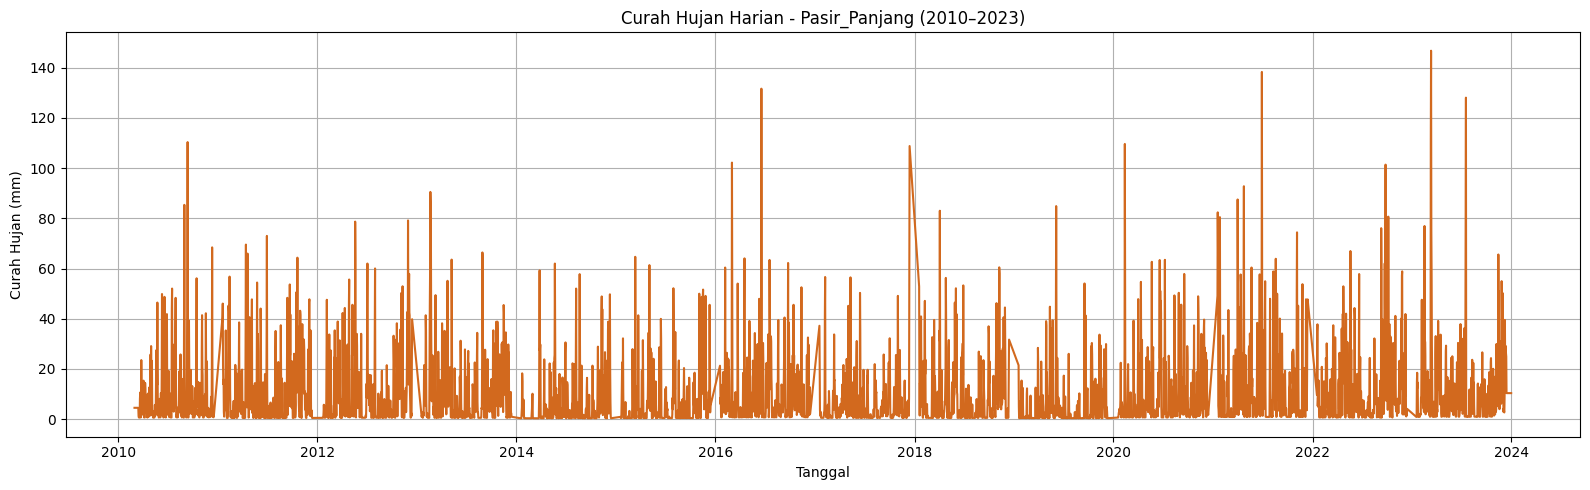

In [144]:
# Gabungkan semua tahun dan interpolasi
df_concat_pasirpanjang = pd.concat(all_pasirpanjang, ignore_index=True)
df_concat_pasirpanjang['rainfall_mm'] = (
    df_concat_pasirpanjang['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_pasirpanjang['Date'], df_concat_pasirpanjang['rainfall_mm'], color='chocolate')
plt.title("Curah Hujan Harian - Pasir_Panjang (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_pasirpanjang[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Panjang.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Panjang.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Pasir_Panjang-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Pasir_Panjang-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-03-01                    4.50908
1 2010-03-02                    4.50908
2 2010-03-03                    4.50908
3 2010-03-04                    4.50908
4 2010-03-05                    4.50908


# Pasir_Ris_Central

In [ ]:
pasirris_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Pasir_Ris_Central/"
pasirris_csv_prefix = "Data_Gabungan_Lainnya_"
pasirris_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

pasirris_rain_info = {
    2010: 230, 2011: 240, 2012: 240, 2013: 130,
    2014: 125, 2015: 110, 2016: 130, 2017: 110,  2018: 80,
    2019: 90, 2020: 130, 2021: 230, 2022: 110, 2023: 210,
}

In [ ]:
all_pasirris = []

for year, rain_max in pasirris_rain_info.items():
    png_file = os.path.join(pasirris_path, f"{pasirris_png_prefix}{year}.png")
    csv_file = os.path.join(pasirris_path, f"{pasirris_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Pasir_Ris_Central: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_pasirris.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumseagreen', label='Pasir_Ris_Central')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Pasir_Ris_Central {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

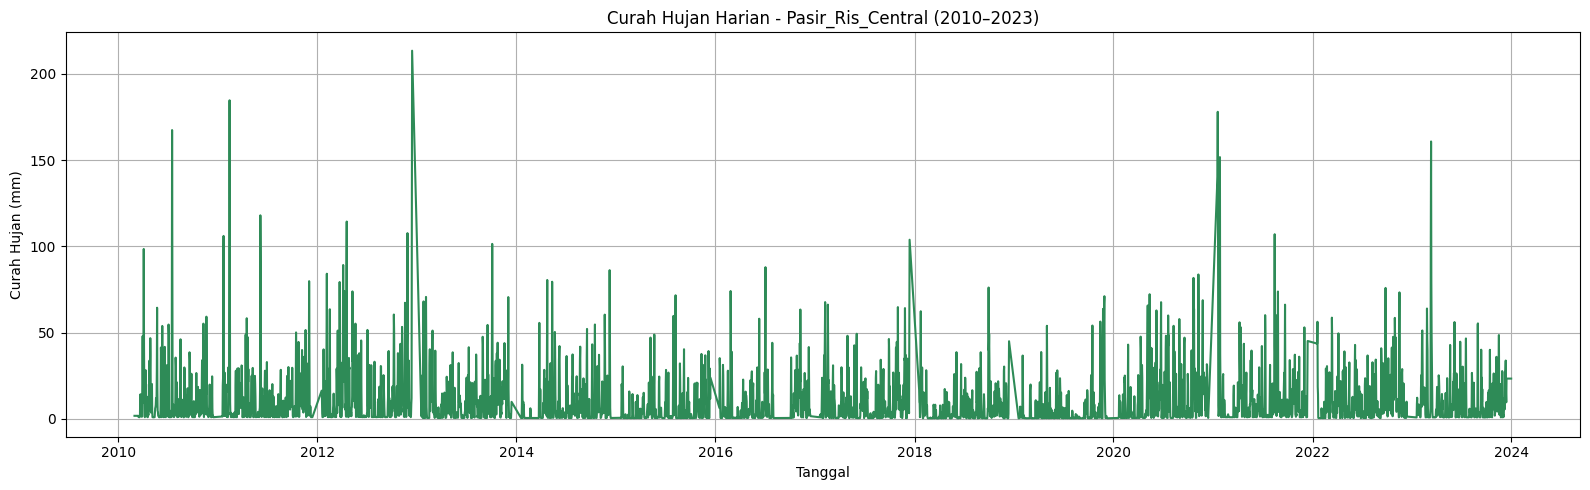

In [148]:
# Gabungkan semua tahun dan lakukan interpolasi
df_concat_pasirris = pd.concat(all_pasirris, ignore_index=True)
df_concat_pasirris['rainfall_mm'] = (
    df_concat_pasirris['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_pasirris['Date'], df_concat_pasirris['rainfall_mm'], color='seagreen')
plt.title("Curah Hujan Harian - Pasir_Ris_Central (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_pasirris[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Ris_Central.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Ris_Central.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Pasir_Ris_Central-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Pasir_Ris_Central-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-03-01                   1.793372
1 2010-03-02                   1.793372
2 2010-03-03                   1.793372
3 2010-03-04                   1.793372
4 2010-03-05                   1.793372


# Pasir_Ris_West

In [ ]:
pasirriswest_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Pasir_Ris_West/"
pasirriswest_csv_prefix = "Data_Gabungan_Lainnya_"
pasirriswest_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

pasirriswest_rain_info = {
    1980: 210, 1981: 105, 1982: 185, 1983: 185, 1984: 190,
    1985: 110, 1986: 115, 1987: 160, 1988: 145, 1989: 215,
    1990: 220, 1991: 178, 1992: 124, 1993: 150, 1994: 250,
    1995: 220, 1996: 130, 1997: 108, 1998: 150, 1999: 83,
    2000: 210, 2001: 250, 2002: 100, 2003: 245, 2004: 258,
    2005: 245, 2006: 350, 2007: 180, 2008: 255, 2009: 105,
    2010: 160, 2011: 260, 2012: 95, 2013: 88, 2014: 88,
    2015: 85, 2016: 108, 2017: 90, 2018: 73, 2019: 140,
    2020: 120, 2021: 100, 2022: 135, 2023: 200,
}

In [ ]:
all_pasirriswest = []

for year, rain_max in pasirriswest_rain_info.items():
    png_file = os.path.join(pasirriswest_path, f"{pasirriswest_png_prefix}{year}.png")
    csv_file = os.path.join(pasirriswest_path, f"{pasirriswest_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru dan hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Pasir_Ris_West: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel x ke indeks hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel y ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_pasirriswest.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='royalblue', label='Pasir_Ris_West')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Pasir_Ris_West {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

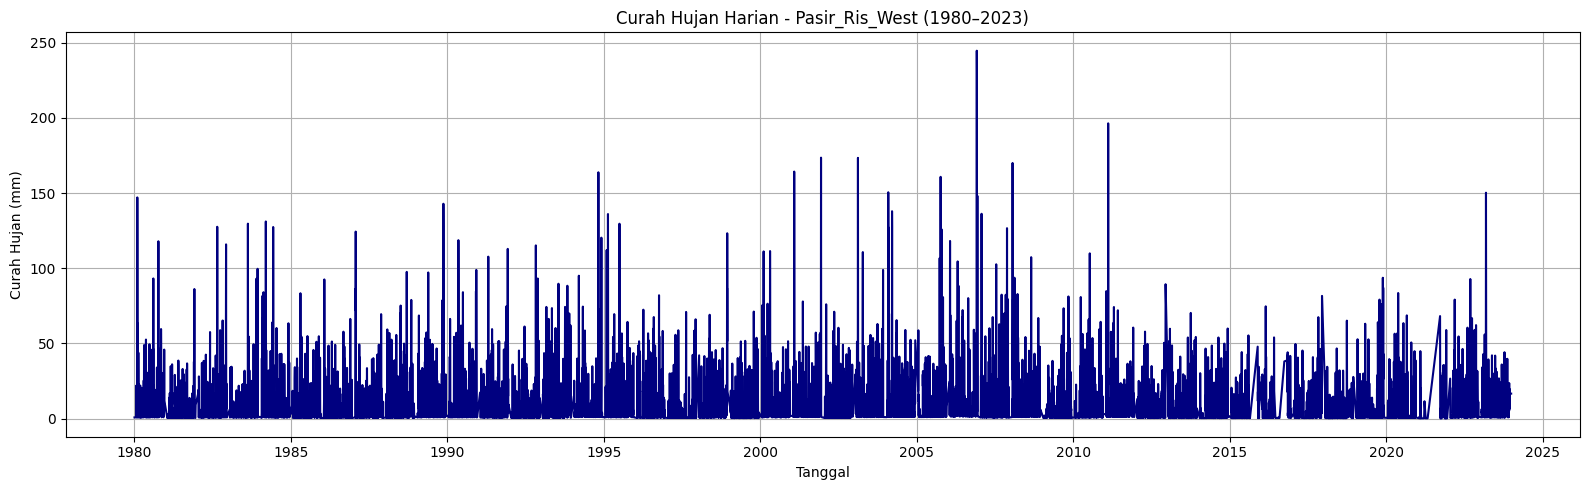

In [152]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_pasirriswest = pd.concat(all_pasirriswest, ignore_index=True)
df_concat_pasirriswest['rainfall_mm'] = (
    df_concat_pasirriswest['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_pasirriswest['Date'], df_concat_pasirriswest['rainfall_mm'], color='navy')
plt.title("Curah Hujan Harian - Pasir_Ris_West (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_pasirriswest[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Ris_West.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pasir_Ris_West.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Pasir_Ris_West-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Pasir_Ris_West-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.818713
1 1980-01-02                   0.818713
2 1980-01-03                   0.818713
3 1980-01-04                   0.818713
4 1980-01-05                   0.818713


# Pulau_Ubin

In [ ]:
pulauubin_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Pulau_Ubin/"
pulauubin_csv_prefix = "Data_Gabungan_Lainnya_"
pulauubin_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

pulauubin_rain_info = {
    2009: 70, 2010: 170, 2011: 330, 2012: 120, 2013: 130,
    2014: 90, 2015: 110, 2016: 115, 2017: 130,  2018: 120,
    2019: 130, 2020: 120, 2021: 230, 2022: 135, 2023: 210,
}

In [ ]:
all_pulauubin = []

for year, rain_max in pulauubin_rain_info.items():
    png_file = os.path.join(pulauubin_path, f"{pulauubin_png_prefix}{year}.png")
    csv_file = os.path.join(pulauubin_path, f"{pulauubin_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Temukan sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ekstraksi titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # jadi (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Pulau_Ubin: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel x ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_pulauubin.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='forestgreen', label='Pulau_Ubin')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Pulau_Ubin {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

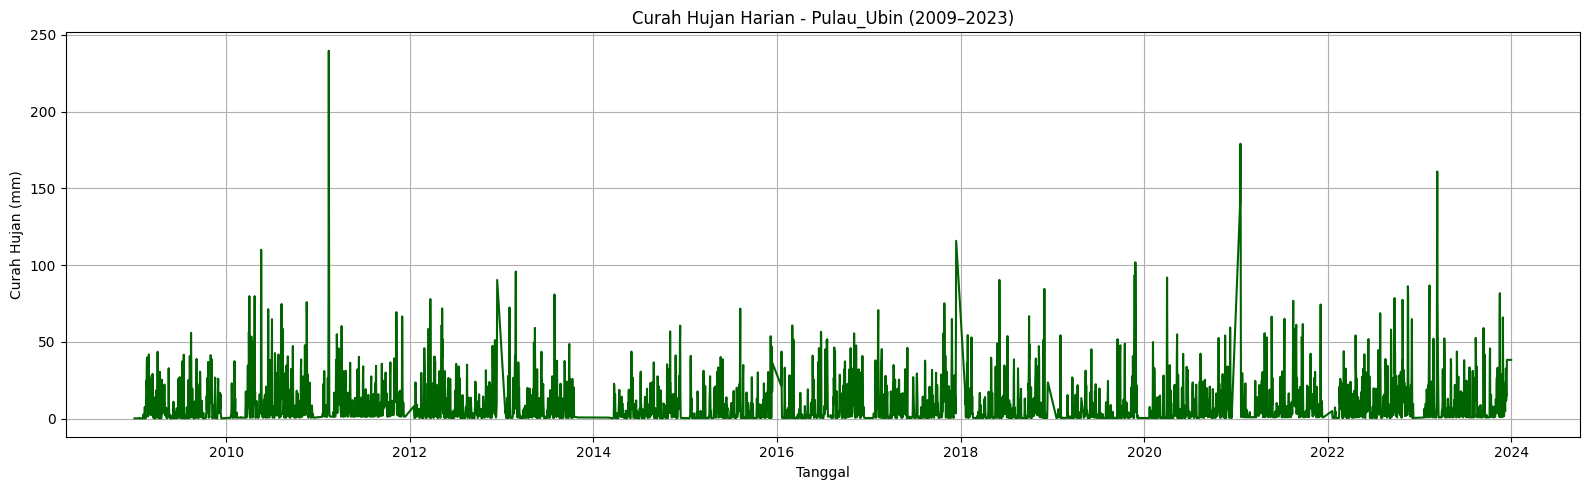

In [156]:
# Gabungkan semua tahun dan interpolasi
df_concat_pulauubin = pd.concat(all_pulauubin, ignore_index=True)
df_concat_pulauubin['rainfall_mm'] = (
    df_concat_pulauubin['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total gabungan
plt.figure(figsize=(16, 5))
plt.plot(df_concat_pulauubin['Date'], df_concat_pulauubin['rainfall_mm'], color='darkgreen')
plt.title("Curah Hujan Harian - Pulau_Ubin (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_pulauubin[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pulau_Ubin.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Pulau_Ubin.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Pulau_Ubin-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Pulau_Ubin-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-01-01                   0.297714
1 2009-01-02                   0.297714
2 2009-01-03                   0.297714
3 2009-01-04                   0.297714
4 2009-01-05                   0.297714


# Punggol

In [ ]:
punggol_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Punggol/"
punggol_csv_prefix = "Data_Gabungan_Lainnya_"
punggol_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

punggol_rain_info = {
    2009: 110, 2010: 140, 2011: 225, 2012: 150, 2013: 130,
    2014: 145, 2015: 105, 2016: 115, 2017: 115,  2018: 115,
    2019: 120, 2020: 135, 2021: 200, 2022: 135, 2023: 220,
}

In [ ]:
all_punggol = []

for year, rain_max in punggol_rain_info.items():
    png_file = os.path.join(punggol_path, f"{punggol_png_prefix}{year}.png")
    csv_file = os.path.join(punggol_path, f"{punggol_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Punggol: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_punggol.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkcyan', label='Punggol')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Punggol {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

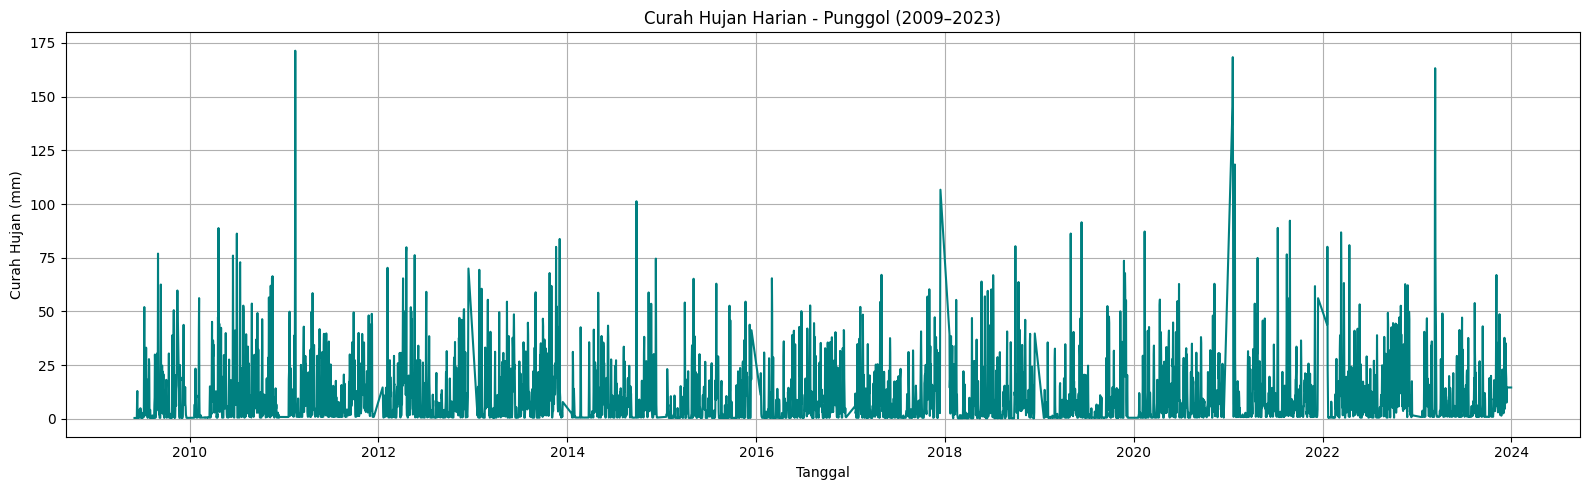

In [160]:
# Gabungkan semua tahun dan interpolasi
df_concat_punggol = pd.concat(all_punggol, ignore_index=True)
df_concat_punggol['rainfall_mm'] = (
    df_concat_punggol['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_punggol['Date'], df_concat_punggol['rainfall_mm'], color='teal')
plt.title("Curah Hujan Harian - Punggol (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_punggol[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Punggol.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Punggol.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Punggol-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Punggol-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-06-01                    0.42885
1 2009-06-02                    0.42885
2 2009-06-03                    0.42885
3 2009-06-04                    0.42885
4 2009-06-05                    0.42885


# Paya_Lebar

In [ ]:
Paya_Lebar_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Paya_Lebar/"
Paya_Lebar_csv_prefix = "Data_Gabungan_Lainnya_"
Paya_Lebar_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

Paya_Lebar_rain_info = {
    1980: 193, 1981: 97, 1982: 176, 1983: 160, 1984: 240,
    1985: 150, 1986: 130, 1987: 130, 1988: 145, 1989: 200,
    1990: 200, 1991: 290, 1992: 125, 1993: 130, 1994: 260,
    1995: 236, 1996: 200, 1997: 150, 1998: 200, 1999: 155,
    2000: 230, 2001: 240, 2002: 108, 2003: 180, 2004: 245,
    2005: 100, 2006: 280, 2007: 180, 2008: 170, 2009: 110,
    2010: 380, 2011: 173, 2012: 178, 2013: 200, 2014: 113,
    2015: 180, 2016: 155, 2017: 79, 2018: 190, 2019: 125,
    2020: 195, 2021: 210, 2022: 250, 2023: 220,
}

In [667]:
all_Paya_Lebar = []

for year, rain_max in Paya_Lebar_rain_info.items():
    png_file = os.path.join(Paya_Lebar_path, f"{Paya_Lebar_png_prefix}{year}.png")
    csv_file = os.path.join(Paya_Lebar_path, f"{Paya_Lebar_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Deteksi kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu X (horizontal terpanjang)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Buona_Vista: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke index hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min, y_pixel_max = y_pixel.min(), y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_Paya_Lebar.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='teal', label='Buona_Vista')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Buona_Vista {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

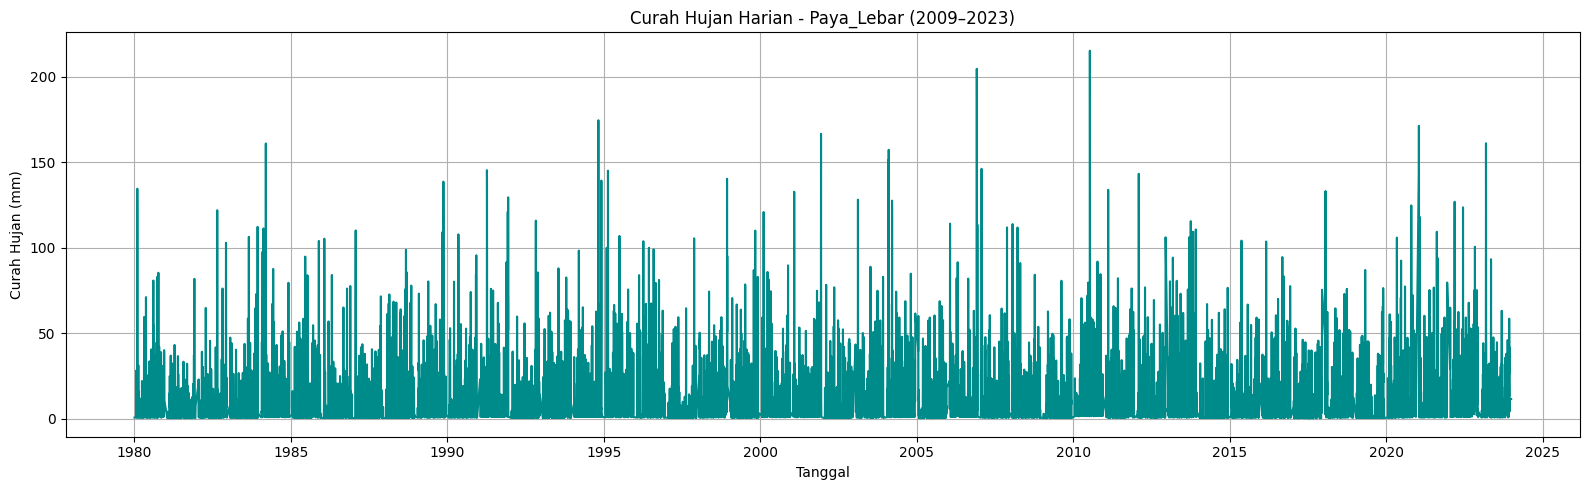

In [164]:
# Gabungkan semua tahun dan interpolasi
df_concat_Paya_Lebar = pd.concat(all_Paya_Lebar, ignore_index=True)
df_concat_Paya_Lebar['rainfall_mm'] = (
    df_concat_Paya_Lebar['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi total 2009–2023
plt.figure(figsize=(16, 5))
plt.plot(df_concat_Paya_Lebar['Date'], df_concat_Paya_Lebar['rainfall_mm'], color='darkcyan')
plt.title("Curah Hujan Harian - Paya_Lebar (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_Paya_Lebar[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Paya_Lebar.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Paya_Lebar.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Paya_Lebar-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Paya_Lebar-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.752437
1 1980-01-02                   0.752437
2 1980-01-03                   0.752437
3 1980-01-04                   0.752437
4 1980-01-05                   0.752437


# Queenstown

In [ ]:
queenstown_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Queenstown/"
queenstown_csv_prefix = "Data_Gabungan_Lainnya_"
queenstown_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

queenstown_rain_info = {
    1980: 130, 1981: 95, 1982: 175, 1983: 100, 1984: 325,
    1985: 162, 1986: 110, 1987: 305, 1988: 200, 1989: 235,
    1990: 85, 1991: 160, 1992: 128, 1993: 128, 1994: 190,
    1995: 190, 1996: 130, 1997: 180, 1998: 125, 1999: 107,
    2000: 140, 2001: 255, 2002: 180, 2003: 190, 2004: 450,
    2005: 180, 2006: 200, 2007: 130, 2008: 100, 2009: 85,
    2010: 125, 2011: 145, 2012: 120, 2013: 170, 2014: 170,
    2015: 90, 2016: 150, 2017: 120, 2018: 140, 2019: 150,
    2020: 140, 2021: 200, 2022: 145, 2023: 225,
}

In [668]:
all_queenstown = []

for year, rain_max in queenstown_rain_info.items():
    png_file = os.path.join(queenstown_path, f"{queenstown_png_prefix}{year}.png")
    csv_file = os.path.join(queenstown_path, f"{queenstown_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru dan hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik kurva biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Queenstown: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_queenstown.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkviolet', label='Queenstown')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Queenstown {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

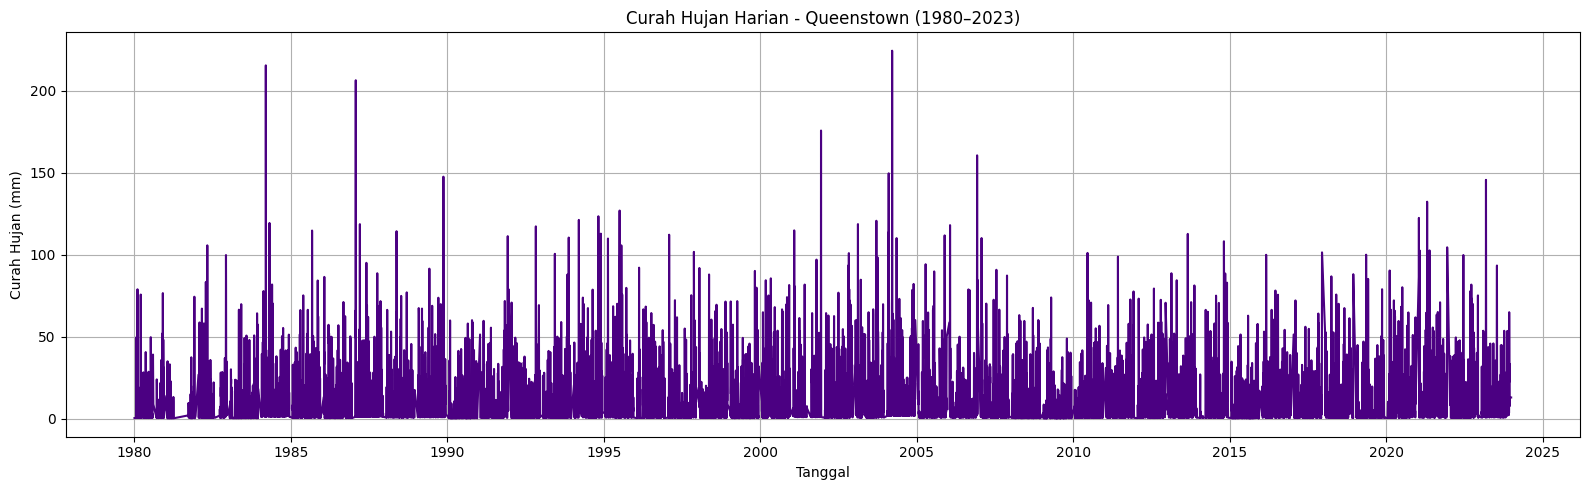

In [168]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_queenstown = pd.concat(all_queenstown, ignore_index=True)
df_concat_queenstown['rainfall_mm'] = (
    df_concat_queenstown['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_queenstown['Date'], df_concat_queenstown['rainfall_mm'], color='indigo')
plt.title("Curah Hujan Harian - Queenstown (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_queenstown[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Queenstown.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Queenstown.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Queenstown-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Queenstown-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.506823
1 1980-01-02                   0.506823
2 1980-01-03                   0.506823
3 1980-01-04                   0.506823
4 1980-01-05                   0.506823


# Seletar

In [ ]:
seletar_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Seletar/"
seletar_csv_prefix = "Data_Gabungan_Lainnya_"
seletar_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

seletar_rain_info = {
    1980: 170, 1981: 190, 1982: 100, 1983: 100, 1984: 180,
    1985: 120, 1986: 130, 1987: 150, 1988: 150, 1989: 295,
    1990: 125, 1991: 190, 1992: 195, 1993: 135, 1994: 168,
    1995: 250, 1996: 110, 1997: 180, 1998: 110, 1999: 115,
    2000: 195, 2001: 230, 2002: 85, 2003: 219, 2004: 280,
    2005: 270, 2006: 360, 2007: 210, 2008: 220, 2009: 85,
    2010: 210, 2011: 210, 2012: 130, 2013: 130, 2014: 140,
    2015: 125, 2016: 105, 2017: 90, 2018: 140, 2019: 110,
    2020: 90, 2021: 170, 2022: 140, 2023: 210,
}

In [689]:
all_seletar = []

for year, rain_max in seletar_rain_info.items():
    png_file = os.path.join(seletar_path, f"{seletar_png_prefix}{year}.png")
    csv_file = os.path.join(seletar_path, f"{seletar_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Seletar: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_seletar.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='steelblue', label='Seletar')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Seletar {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

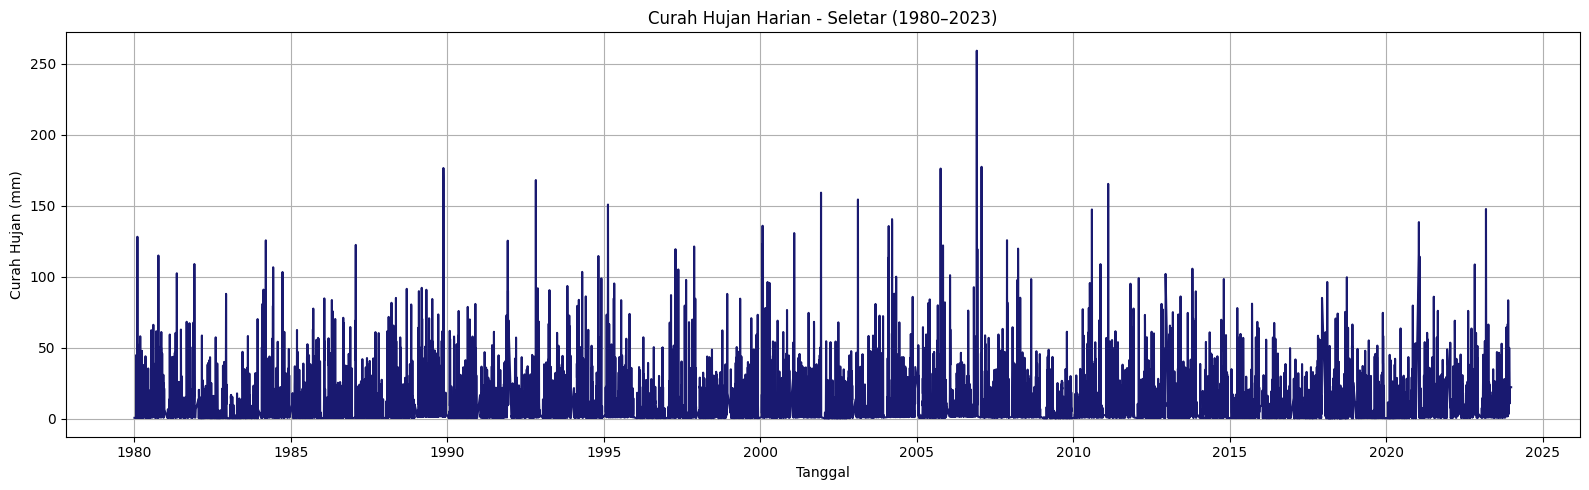

In [172]:
# Gabungkan semua tahun dan interpolasi
df_concat_seletar = pd.concat(all_seletar, ignore_index=True)
df_concat_seletar['rainfall_mm'] = (
    df_concat_seletar['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Plot gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_seletar['Date'], df_concat_seletar['rainfall_mm'], color='midnightblue')
plt.title("Curah Hujan Harian - Seletar (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_seletar[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Seletar.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Seletar.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Seletar-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Seletar-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.662768
1 1980-01-02                   0.662768
2 1980-01-03                   0.662768
3 1980-01-04                   0.662768
4 1980-01-05                   0.662768


# Sembawang

In [ ]:
sembawang_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Sembawang/"
sembawang_csv_prefix = "Data_Gabungan_Lainnya_"
sembawang_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

sembawang_rain_info = {
    1991: 95, 1992: 140, 1993: 120, 1994: 150,
    1995: 205, 1996: 235, 1997: 195, 1998: 150, 1999: 110,
    2000: 175, 2001: 225, 2002: 160, 2003: 180, 2004: 330,
    2005: 260, 2006: 310, 2007: 220, 2008: 120, 2009: 270,
    2010: 180, 2011: 150, 2012: 130, 2013: 150, 2014: 155,
    2015: 155, 2016: 133, 2017: 170, 2018: 130, 2019: 150,
    2020: 95, 2021: 250, 2022: 155, 2023: 180,
}

In [ ]:
all_sembawang = []

for year, rain_max in sembawang_rain_info.items():
    png_file = os.path.join(sembawang_path, f"{sembawang_png_prefix}{year}.png")
    csv_file = os.path.join(sembawang_path, f"{sembawang_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Sembawang: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_sembawang.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkslategray', label='Sembawang')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Sembawang {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

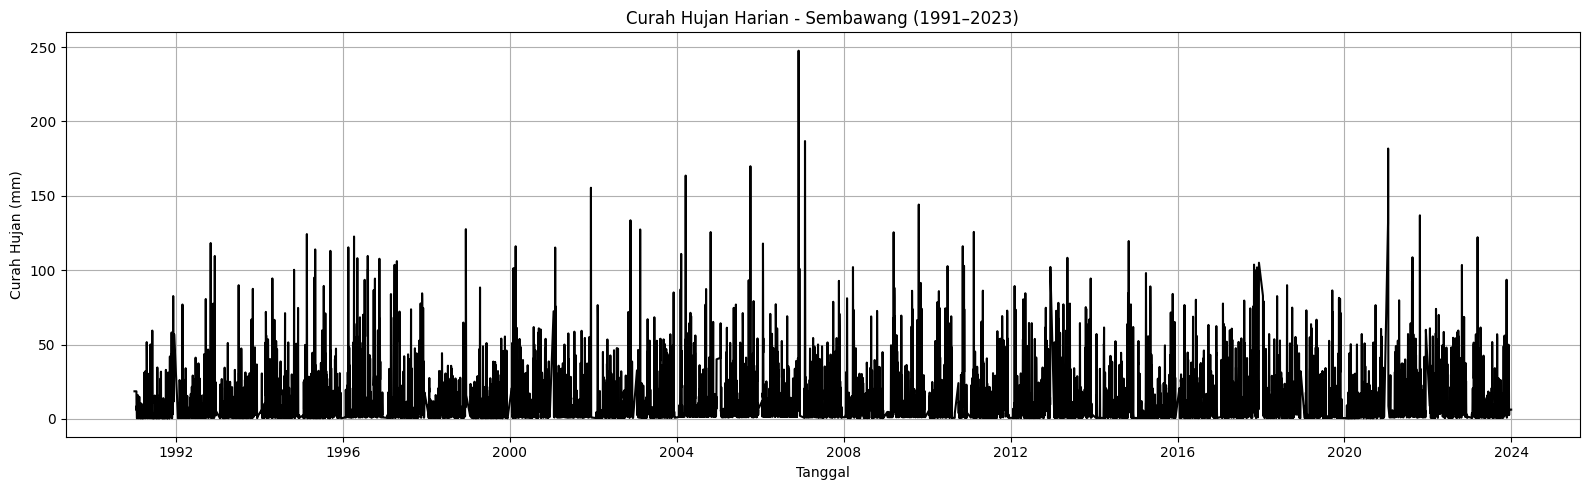

In [176]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_sembawang = pd.concat(all_sembawang, ignore_index=True)
df_concat_sembawang['rainfall_mm'] = (
    df_concat_sembawang['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_sembawang['Date'], df_concat_sembawang['rainfall_mm'], color='black')
plt.title("Curah Hujan Harian - Sembawang (1991–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_sembawang[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Sembawang.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Sembawang.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Sembawang-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Sembawang-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1991-01-01                  18.553157
1 1991-01-02                  18.553157
2 1991-01-03                  18.553157
3 1991-01-04                  18.553157
4 1991-01-05                  18.553157


# Sentosa_Island

In [ ]:
sentosa_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Sentosa_Island/"
sentosa_csv_prefix = "Data_Gabungan_Lainnya_"
sentosa_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

sentosa_rain_info = {
    1980: 120, 1981: 100, 1982: 125, 1983: 120, 1984: 240,
    1985: 165, 1986: 125, 1987: 110, 1988: 130, 1989: 190,
    1990: 190, 1991: 130, 1992: 170, 1993: 160, 1994: 200,
    1995: 175, 1996: 175, 1997: 90, 1998: 130, 1999: 130,
    2000: 140, 2001: 140, 2002: 130, 2003: 170, 2004: 330,
    2005: 100, 2006: 220, 2007: 210, 2008: 130, 2009: 90,
    2010: 160, 2011: 170, 2012: 120, 2013: 120, 2014: 100,
    2015: 175, 2016: 200, 2017: 120, 2018: 130, 2019: 110,
    2020: 260, 2021: 260, 2022: 170, 2023: 230,
}

In [ ]:
all_sentosa = []

for year, rain_max in sentosa_rain_info.items():
    png_file = os.path.join(sentosa_path, f"{sentosa_png_prefix}{year}.png")
    csv_file = os.path.join(sentosa_path, f"{sentosa_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Sentosa_Island: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    # Gabungkan dengan semua tanggal dari CSV
    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_sentosa.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumvioletred', label='Sentosa_Island')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Sentosa_Island {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

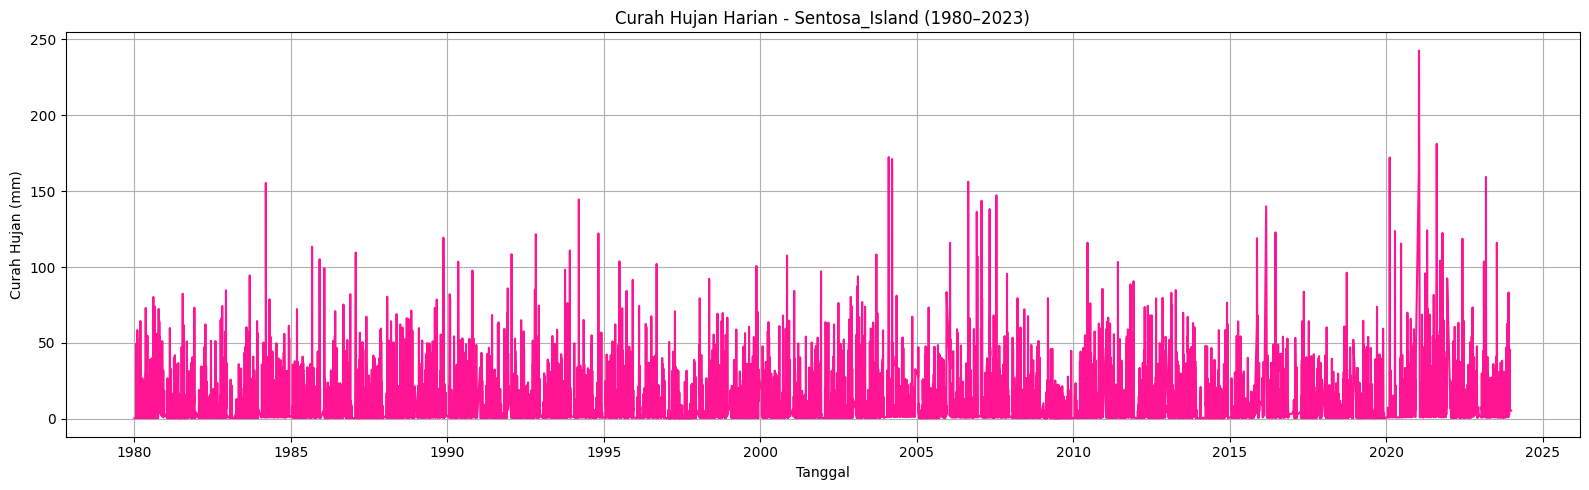

In [180]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_sentosa = pd.concat(all_sentosa, ignore_index=True)
df_concat_sentosa['rainfall_mm'] = (
    df_concat_sentosa['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_sentosa['Date'], df_concat_sentosa['rainfall_mm'], color='deeppink')
plt.title("Curah Hujan Harian - Sentosa_Island (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_sentosa[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Sentosa_Island.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Sentosa_Island.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Sentosa_Island-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Sentosa_Island-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.467836
1 1980-01-02                   0.467836
2 1980-01-03                   0.467836
3 1980-01-04                   0.467836
4 1980-01-05                   0.467836


# Simei

In [ ]:
simei_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Simei/"
simei_csv_prefix = "Data_Gabungan_Lainnya_"
simei_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

simei_rain_info = {
    2009: 120, 2010: 305, 2011: 185, 2012: 100, 2013: 90,
    2014: 130, 2015: 100, 2016: 150, 2017: 135,  2018: 190,
    2019: 100, 2020: 175, 2021: 210, 2022: 160, 2023: 255,
}

In [ ]:
all_simei = []

for year, rain_max in simei_rain_info.items():
    png_file = os.path.join(simei_path, f"{simei_png_prefix}{year}.png")
    csv_file = os.path.join(simei_path, f"{simei_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Simei: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # DataFrame hasil
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_simei.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='orangered', label='Simei')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Simei {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

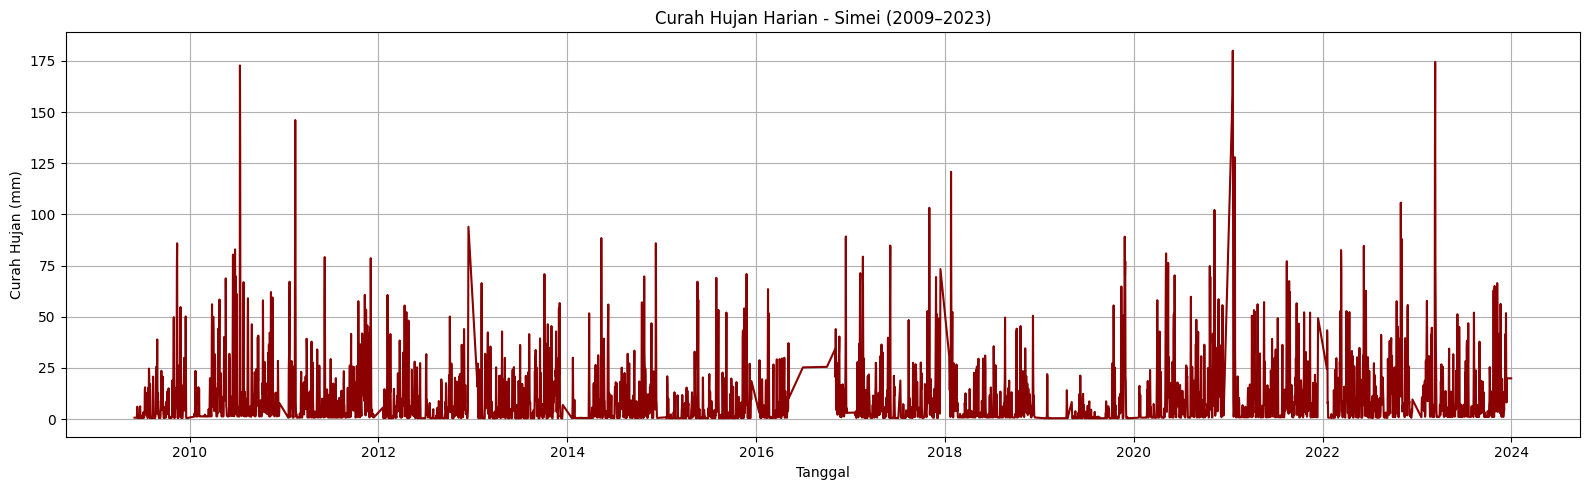

In [184]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_simei = pd.concat(all_simei, ignore_index=True)
df_concat_simei['rainfall_mm'] = (
    df_concat_simei['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_simei['Date'], df_concat_simei['rainfall_mm'], color='darkred')
plt.title("Curah Hujan Harian - Simei (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_simei[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Simei.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Simei.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Simei-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Simei-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-06-01                   0.701754
1 2009-06-02                   0.701754
2 2009-06-03                   0.701754
3 2009-06-04                   0.701754
4 2009-06-05                   0.701754


# Somerset_Road

In [ ]:
somerset_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Somerset_Road/"
somerset_csv_prefix = "Data_Gabungan_Lainnya_"
somerset_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

somerset_rain_info = {
    2011: 200, 2012: 110, 2013: 125,
    2014: 135, 2015: 110, 2016: 125, 2017: 170,  2018: 90,
    2019: 135, 2020: 120, 2021: 130, 2022: 125, 2023: 200,
}

In [ ]:
all_somerset = []

for year, rain_max in somerset_rain_info.items():
    png_file = os.path.join(somerset_path, f"{somerset_png_prefix}{year}.png")
    csv_file = os.path.join(somerset_path, f"{somerset_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking untuk kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Somerset_Road: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_somerset.append(df_merged)

    # Plot per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkorange', label='Somerset_Road')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Somerset_Road {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

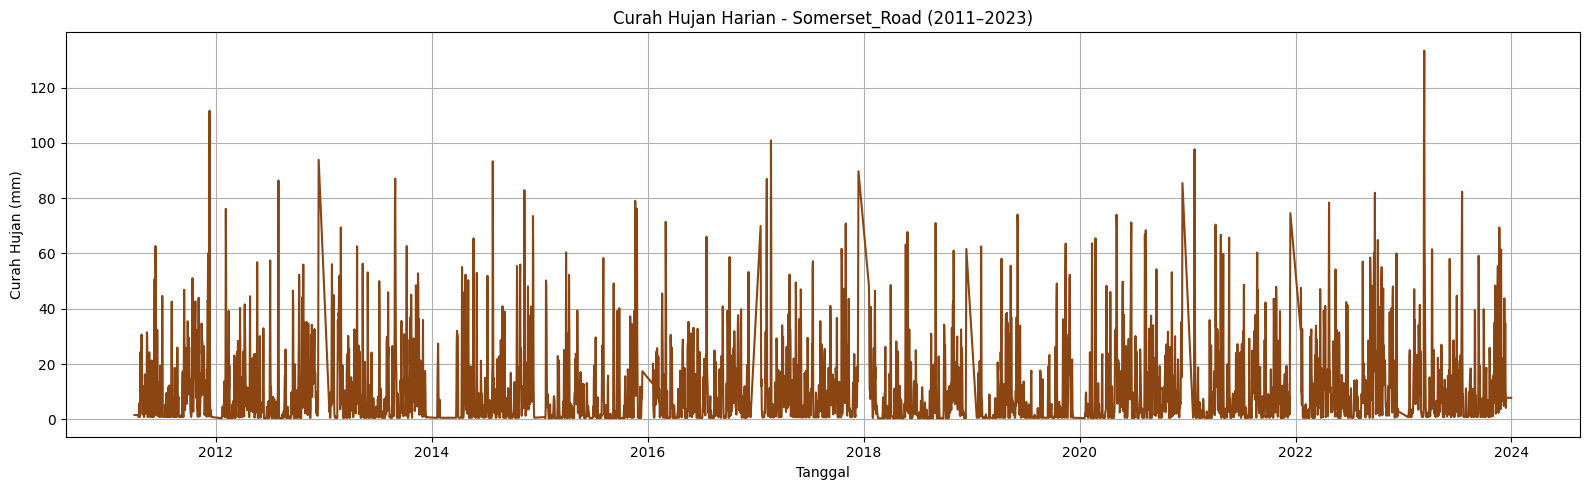

In [188]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_somerset = pd.concat(all_somerset, ignore_index=True)
df_concat_somerset['rainfall_mm'] = (
    df_concat_somerset['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_somerset['Date'], df_concat_somerset['rainfall_mm'], color='saddlebrown')
plt.title("Curah Hujan Harian - Somerset_Road (2011–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_somerset[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Somerset_Road.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Somerset_Road.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Somerset_Road-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Somerset_Road-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2011-04-01                   1.559454
1 2011-04-02                   1.559454
2 2011-04-03                   1.559454
3 2011-04-04                   1.559454
4 2011-04-05                   1.559454


# Tai_Seng

In [ ]:
taiseng_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Tai_Seng/"
taiseng_csv_prefix = "Data_Gabungan_Lainnya_"
taiseng_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

taiseng_rain_info = {
    1980: 130, 1981: 130, 1982: 110, 1983: 140, 1984: 280,
    1985: 140, 1986: 135, 1987: 180, 1988: 130, 1989: 170,
    1990: 125, 1991: 90, 1992: 125, 1993: 95, 1994: 200,
    1995: 230, 1996: 140, 1997: 220, 1998: 150, 1999: 120,
    2000: 155, 2001: 255, 2002: 185, 2003: 195, 2004: 320,
    2005: 155, 2006: 240, 2007: 165, 2008: 125, 2009: 120,
    2010: 340, 2011: 120, 2012: 160, 2013: 140, 2014: 125,
    2015: 100, 2016: 130, 2017: 98, 2018: 180, 2019: 105,
    2020: 200, 2021: 210, 2022: 280, 2023: 260,
}

In [672]:
all_taiseng = []

for year, rain_max in taiseng_rain_info.items():
    png_file = os.path.join(taiseng_path, f"{taiseng_png_prefix}{year}.png")
    csv_file = os.path.join(taiseng_path, f"{taiseng_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start = x
    x_end = x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Tai_Seng: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_taiseng.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='mediumblue', label='Tai_Seng')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Tai_Seng {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

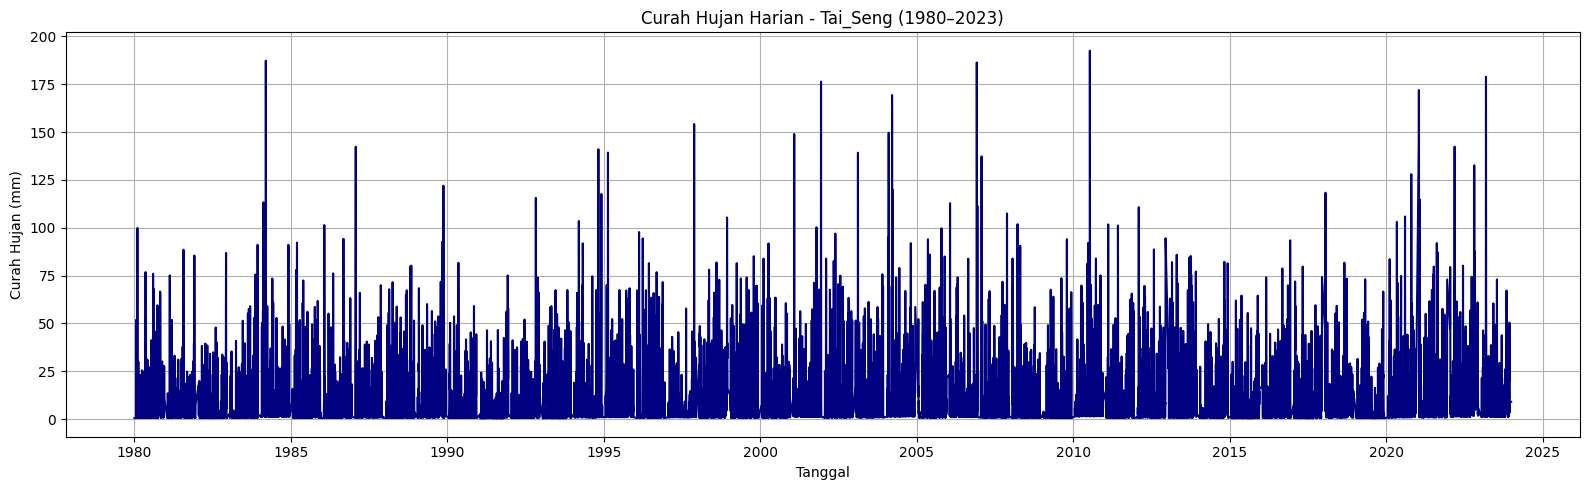

In [192]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_taiseng = pd.concat(all_taiseng, ignore_index=True)
df_concat_taiseng['rainfall_mm'] = (
    df_concat_taiseng['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_taiseng['Date'], df_concat_taiseng['rainfall_mm'], color='navy')
plt.title("Curah Hujan Harian - Tai_Seng (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_taiseng[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tai_Seng.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tai_Seng.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Tai_Seng-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Tai_Seng-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.506823
1 1980-01-02                   0.506823
2 1980-01-03                   0.506823
3 1980-01-04                   0.506823
4 1980-01-05                   0.506823


# Tanjong_Katong

In [ ]:
tanjongkatong_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Tanjong_Katong/"
tanjongkatong_csv_prefix = "Data_Gabungan_Lainnya_"
tanjongkatong_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

tanjongkatong_rain_info = {
    1980: 80, 1981: 100, 1982: 105, 1983: 110, 1984: 255,
    1985: 255, 1986: 150, 1987: 180, 1988: 130, 1989: 220,
    1990: 125, 1991: 100, 1992: 140, 1993: 100, 1994: 210,
    1995: 200, 1996: 140, 1997: 100, 1998: 210, 1999: 105,
    2000: 225, 2001: 235, 2002: 150, 2003: 130, 2004: 310,
    2005: 120, 2006: 260, 2007: 230, 2008: 110, 2009: 120,
    2010: 380, 2011: 150, 2012: 100, 2013: 180, 2014: 135,
    2015: 125, 2016: 115, 2017: 160, 2018: 70, 2019: 100,
    2020: 130, 2021: 220, 2022: 120, 2023: 300,
}

In [673]:
all_tanjongkatong = []

for year, rain_max in tanjongkatong_rain_info.items():
    png_file = os.path.join(tanjongkatong_path, f"{tanjongkatong_png_prefix}{year}.png")
    csv_file = os.path.join(tanjongkatong_path, f"{tanjongkatong_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva dan hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ubah ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Tanjong_Katong: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_tanjongkatong.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='crimson', label='Tanjong_Katong')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Tanjong_Katong {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

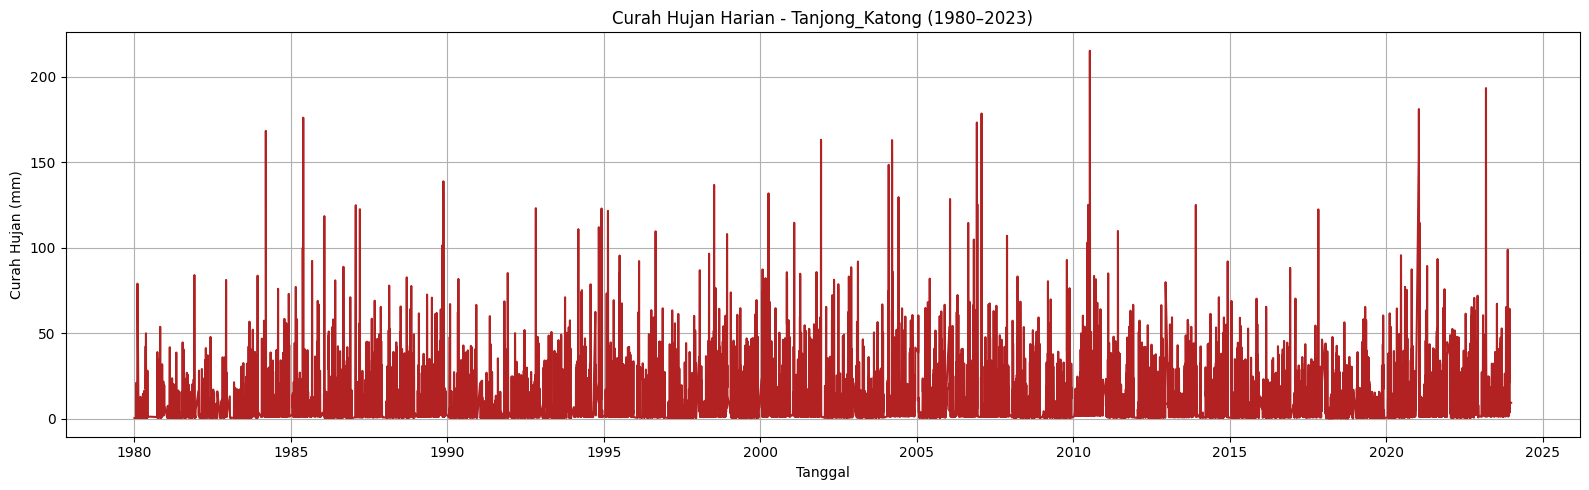

In [196]:
# Gabungkan semua tahun dan lakukan interpolasi
df_concat_tanjongkatong = pd.concat(all_tanjongkatong, ignore_index=True)
df_concat_tanjongkatong['rainfall_mm'] = (
    df_concat_tanjongkatong['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_tanjongkatong['Date'], df_concat_tanjongkatong['rainfall_mm'], color='firebrick')
plt.title("Curah Hujan Harian - Tanjong_Katong (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_tanjongkatong[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tanjong_Katong.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tanjong_Katong.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Tanjong_Katong-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Tanjong_Katong-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.311891
1 1980-01-02                   0.311891
2 1980-01-03                   0.311891
3 1980-01-04                   0.311891
4 1980-01-05                   0.311891


# Tengah

In [ ]:
tengah_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Tengah/"
tengah_csv_prefix = "Data_Gabungan_Lainnya_"
tengah_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

tengah_rain_info = {
    1980: 90, 1981: 120, 1982: 90, 1983: 90, 1984: 200,
    1985: 256, 1986: 280, 1987: 110, 1988: 175, 1989: 165,
    1990: 135, 1991: 100, 1992: 95, 1993: 120, 1994: 155,
    1995: 230, 1996: 200, 1997: 120, 1998: 100, 1999: 155,
    2000: 190, 2001: 150, 2002: 90, 2003: 175, 2004: 330,
    2005: 200, 2006: 260, 2007: 260, 2008: 200, 2009: 200,
    2010: 230, 2011: 150, 2012: 145, 2013: 170, 2014: 140,
    2015: 180, 2016: 120, 2017: 140, 2018: 165, 2019: 120,
    2020: 105, 2021: 205, 2022: 225, 2023: 185,
}

In [674]:
all_tengah = []

for year, rain_max in tengah_rain_info.items():
    png_file = os.path.join(tengah_path, f"{tengah_png_prefix}{year}.png")
    csv_file = os.path.join(tengah_path, f"{tengah_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Tengah: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_tengah.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='seagreen', label='Tengah')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Tengah {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

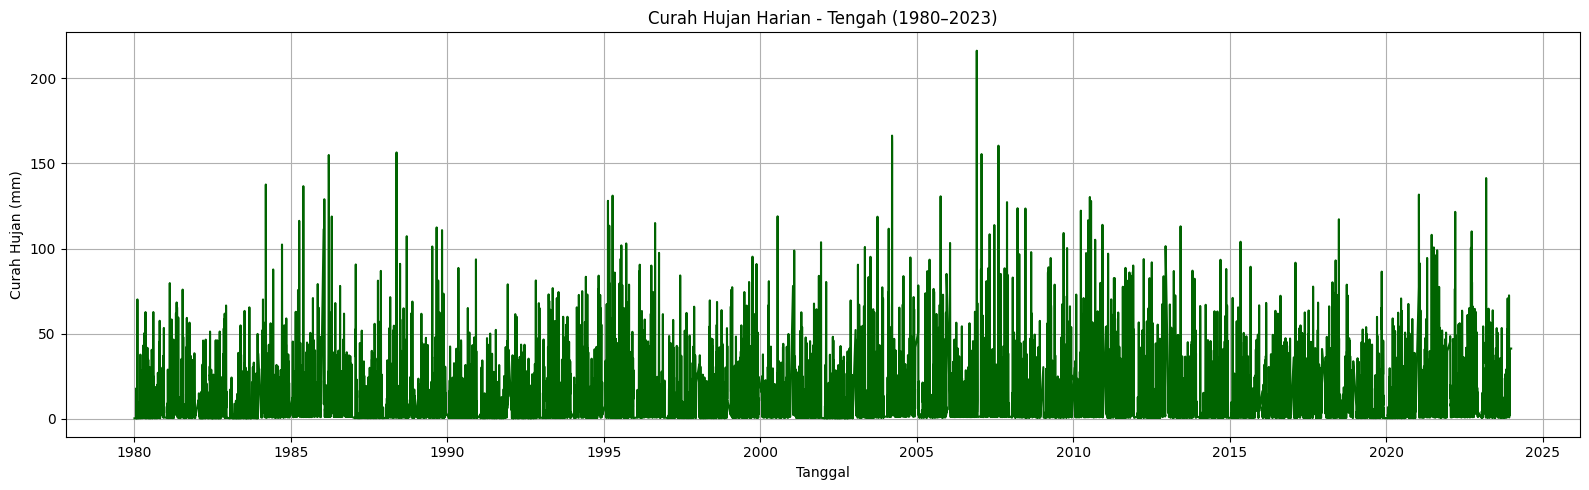

In [200]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_tengah = pd.concat(all_tengah, ignore_index=True)
df_concat_tengah['rainfall_mm'] = (
    df_concat_tengah['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_tengah['Date'], df_concat_tengah['rainfall_mm'], color='darkgreen')
plt.title("Curah Hujan Harian - Tengah (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_tengah[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tengah.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tengah.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Tengah-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Tengah-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.350877
1 1980-01-02                   0.350877
2 1980-01-03                   0.350877
3 1980-01-04                   0.350877
4 1980-01-05                   0.350877


# Toa_Payoh

In [ ]:
toapayoh_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Toa_Payoh/"
toapayoh_csv_prefix = "Data_Gabungan_Lainnya_"
toapayoh_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

toapayoh_rain_info = {
    2010: 185, 2011: 155, 2012: 120, 2013: 160, 2014: 110,
    2015: 120, 2016: 140, 2017: 100, 2018: 185, 2019: 105,
    2020: 140, 2021: 160, 2022: 130, 2023: 190,
}

In [ ]:
all_toapayoh = []

for year, rain_max in toapayoh_rain_info.items():
    png_file = os.path.join(toapayoh_path, f"{toapayoh_png_prefix}{year}.png")
    csv_file = os.path.join(toapayoh_path, f"{toapayoh_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Toa_Payoh: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_toapayoh.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkorange', label='Toa_Payoh')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Toa_Payoh {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

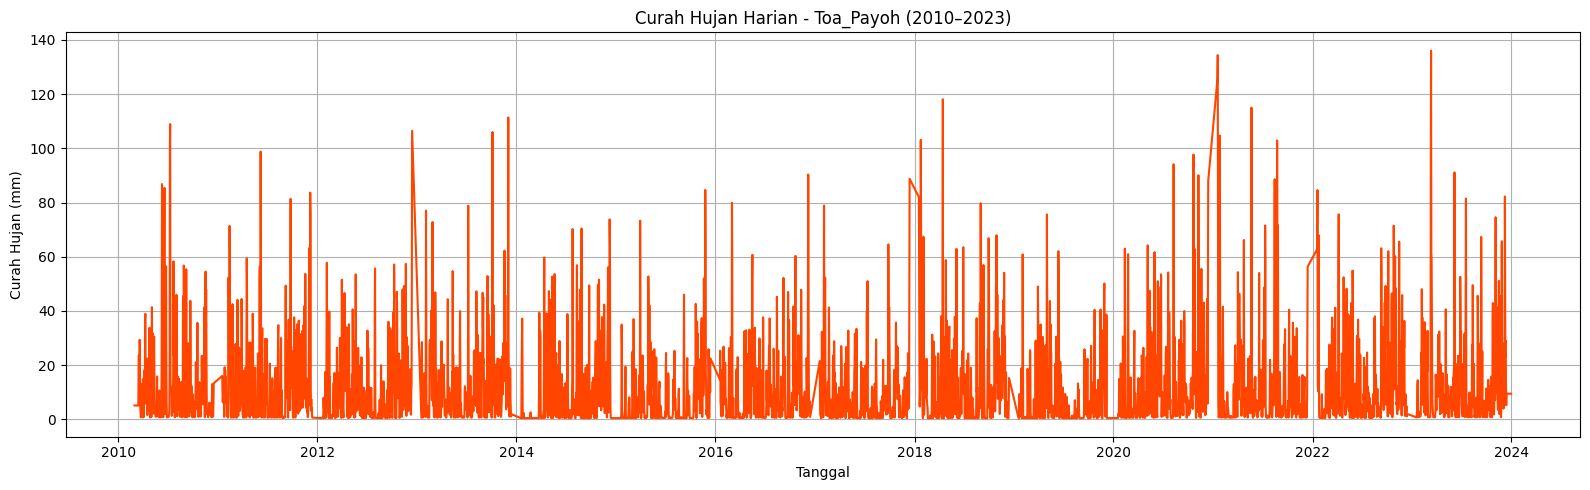

In [204]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_toapayoh = pd.concat(all_toapayoh, ignore_index=True)
df_concat_toapayoh['rainfall_mm'] = (
    df_concat_toapayoh['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_toapayoh['Date'], df_concat_toapayoh['rainfall_mm'], color='orangered')
plt.title("Curah Hujan Harian - Toa_Payoh (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_toapayoh[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Toa_Payoh.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Toa_Payoh.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Toa_Payoh-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Toa_Payoh-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-03-01                   5.127129
1 2010-03-02                   5.127129
2 2010-03-03                   5.127129
3 2010-03-04                   5.127129
4 2010-03-05                   5.127129


# Tuas

In [ ]:
tuas_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Tuas/"
tuas_csv_prefix = "Data_Gabungan_Lainnya_"
tuas_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

tuas_rain_info = {
    2009: 120, 2010: 115, 2011: 170, 2012: 100, 
    2013: 165, 2014: 85, 2015: 140, 2016: 340, 2017: 140,  
    2018: 160, 2019: 115, 2020: 130, 2021: 200, 2022: 150, 2023: 170,
}

In [ ]:
all_tuas = []

for year, rain_max in tuas_rain_info.items():
    png_file = os.path.join(tuas_path, f"{tuas_png_prefix}{year}.png")
    csv_file = os.path.join(tuas_path, f"{tuas_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Tuas: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_tuas.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='slategray', label='Tuas')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Tuas {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

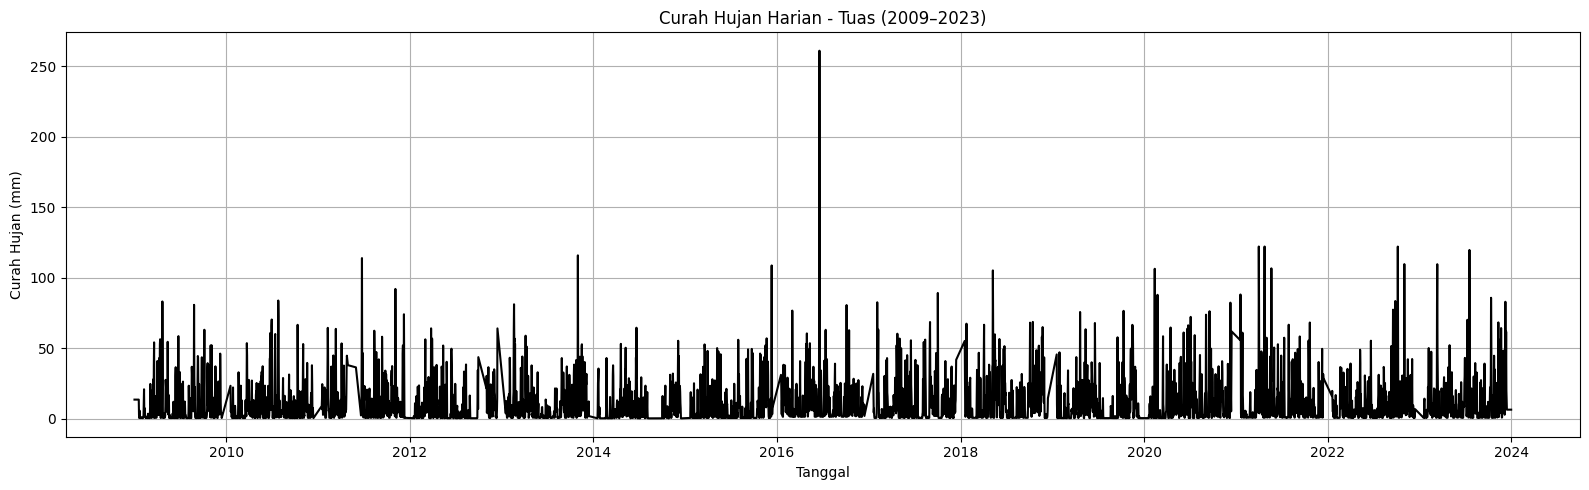

In [208]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_tuas = pd.concat(all_tuas, ignore_index=True)
df_concat_tuas['rainfall_mm'] = (
    df_concat_tuas['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_tuas['Date'], df_concat_tuas['rainfall_mm'], color='black')
plt.title("Curah Hujan Harian - Tuas (2009–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_tuas[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tuas.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tuas.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Tuas-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Tuas-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2009-01-01                  13.604336
1 2009-01-02                  13.604336
2 2009-01-03                  13.604336
3 2009-01-04                  13.604336
4 2009-01-05                  13.604336


# Tuas_South

In [ ]:
tuassouth_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Tuas_South/"
tuassouth_csv_prefix = "Data_Gabungan_Lainnya_"
tuassouth_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

tuassouth_rain_info = {
    2011: 110, 2012: 150, 2013: 210, 2014: 110, 
    2015: 130, 2016: 330, 2017: 160, 2018: 175,
    2019: 150, 2020: 190, 2021: 210, 2022: 180, 2023: 170,
}

In [ ]:
all_tuassouth = []

for year, rain_max in tuassouth_rain_info.items():
    png_file = os.path.join(tuassouth_path, f"{tuassouth_png_prefix}{year}.png")
    csv_file = os.path.join(tuassouth_path, f"{tuassouth_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask biru untuk kurva, hitam untuk sumbu
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari kurva
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Tuas_South: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi pixel X ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi pixel Y ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_tuassouth.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='teal', label='Tuas_South')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Tuas_South {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

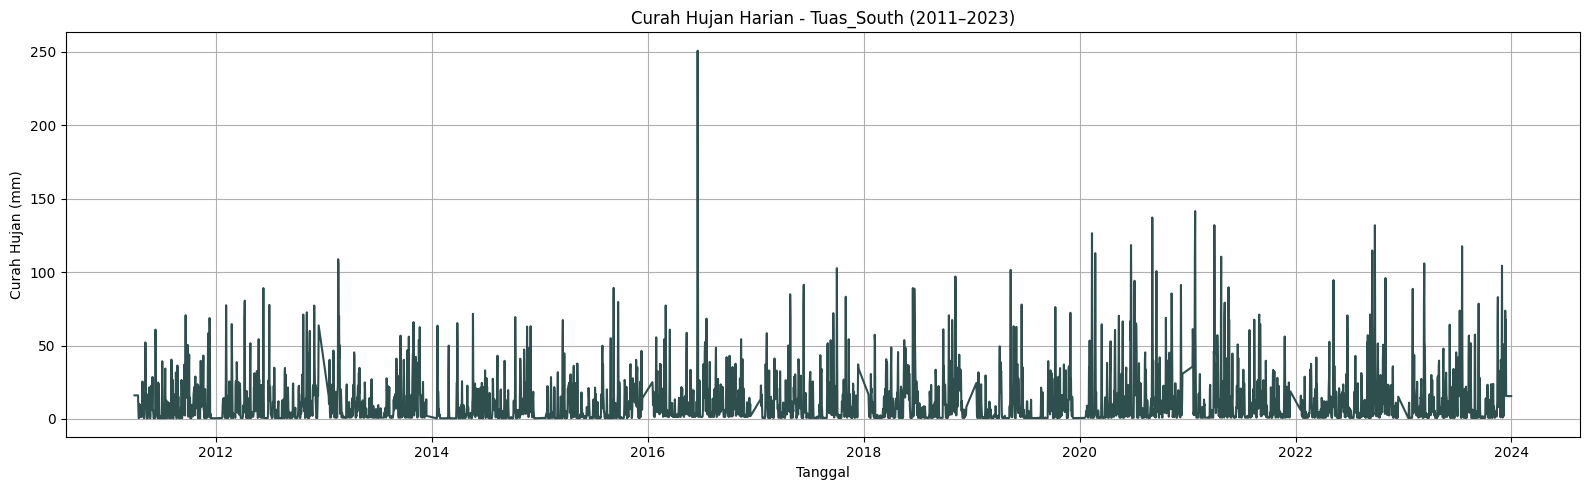

In [212]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_tuassouth = pd.concat(all_tuassouth, ignore_index=True)
df_concat_tuassouth['rainfall_mm'] = (
    df_concat_tuassouth['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_tuassouth['Date'], df_concat_tuassouth['rainfall_mm'], color='darkslategray')
plt.title("Curah Hujan Harian - Tuas_South (2011–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_tuassouth[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tuas_South.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Tuas_South.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Tuas_South-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Tuas_South-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2011-04-01                  16.081871
1 2011-04-02                  16.081871
2 2011-04-03                  16.081871
3 2011-04-04                  16.081871
4 2011-04-05                  16.081871


# Ulu_Pandan

In [ ]:
ulupandan_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Ulu_Pandan/"
ulupandan_csv_prefix = "Data_Gabungan_Lainnya_"
ulupandan_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

ulupandan_rain_info = {
    1980: 145, 1981: 155, 1982: 85, 1983: 125, 1984: 200,
    1985: 210, 1986: 140, 1987: 165, 1988: 135, 1989: 145,
    1990: 170, 1991: 135, 1992: 110, 1993: 185, 1994: 190,
    1995: 165, 1996: 180, 1997: 165, 1998: 110, 1999: 120,
    2000: 77, 2001: 350, 2002: 190, 2003: 280, 2004: 350,
    2005: 145, 2006: 200, 2007: 255, 2008: 130, 2009: 100,
    2010: 305, 2011: 110, 2012: 145, 2013: 120, 2014: 240,
    2015: 140, 2016: 120, 2017: 115, 2018: 255, 2019: 145,
    2020: 100, 2021: 250, 2022:180 , 2023: 210,
}

In [678]:
all_ulupandan = []

for year, rain_max in ulupandan_rain_info.items():
    png_file = os.path.join(ulupandan_path, f"{ulupandan_png_prefix}{year}.png")
    csv_file = os.path.join(ulupandan_path, f"{ulupandan_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Mask untuk kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # konversi ke (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Ulu_Pandan: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan (mm)
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_ulupandan.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='olive', label='Ulu_Pandan')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Ulu_Pandan {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

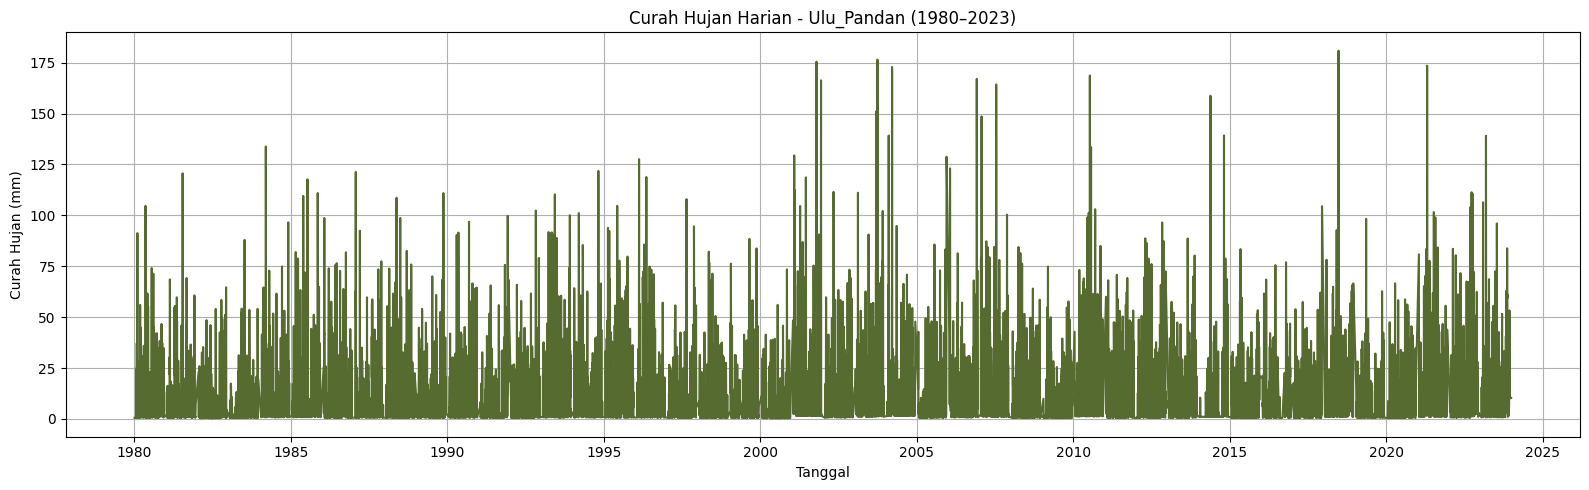

In [216]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_ulupandan = pd.concat(all_ulupandan, ignore_index=True)
df_concat_ulupandan['rainfall_mm'] = (
    df_concat_ulupandan['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_ulupandan['Date'], df_concat_ulupandan['rainfall_mm'], color='darkolivegreen')
plt.title("Curah Hujan Harian - Ulu_Pandan (1980–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_ulupandan[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Ulu_Pandan.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Ulu_Pandan.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Ulu_Pandan-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Ulu_Pandan-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 1980-01-01                   0.565302
1 1980-01-02                   0.565302
2 1980-01-03                   0.565302
3 1980-01-04                   0.565302
4 1980-01-05                   0.565302


# Upper_Peirce_Reservoir

In [ ]:
upperpeirce_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Upper_Peirce_Reservoir/"
upperpeirce_csv_prefix = "Data_Gabungan_Lainnya_"
upperpeirce_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

upperpeirce_rain_info = {
    2010: 300, 2011: 110, 2012: 150, 2013: 200, 2014: 115,
    2015: 110, 2016: 160, 2017: 150, 2018: 130, 2019: 115,
    2020: 90, 2021: 160, 2022: 130, 2023: 180,
}

In [ ]:
all_upperpeirce = []

for year, rain_max in upperpeirce_rain_info.items():
    png_file = os.path.join(upperpeirce_path, f"{upperpeirce_png_prefix}{year}.png")
    csv_file = os.path.join(upperpeirce_path, f"{upperpeirce_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking warna biru (kurva) dan hitam (sumbu)
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal (X-axis)
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik-titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ke format (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Upper_Peirce_Reservoir: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi X pixel ke tanggal
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi Y pixel ke curah hujan (mm)
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame hasil ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_upperpeirce.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='purple', label='Upper_Peirce_Reservoir')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Upper_Peirce_Reservoir {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

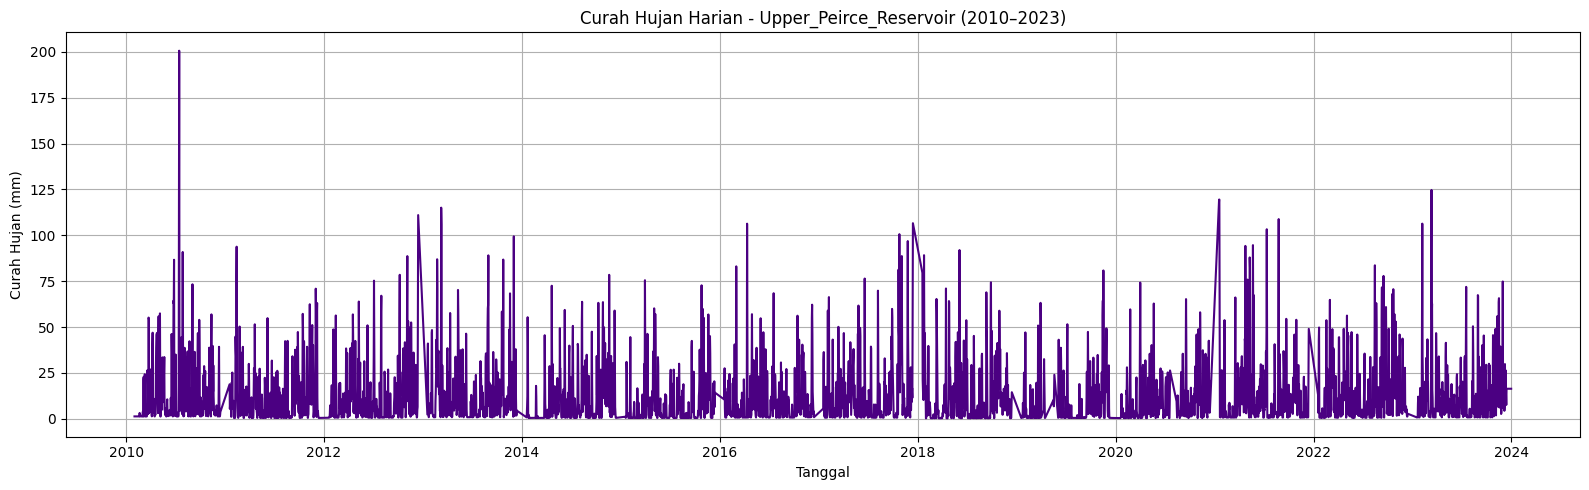

In [220]:
# Gabungkan seluruh tahun dan interpolasi
df_concat_upperpeirce = pd.concat(all_upperpeirce, ignore_index=True)
df_concat_upperpeirce['rainfall_mm'] = (
    df_concat_upperpeirce['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_upperpeirce['Date'], df_concat_upperpeirce['rainfall_mm'], color='indigo')
plt.title("Curah Hujan Harian - Upper_Peirce_Reservoir (2010–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_upperpeirce[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Upper_Peirce_Reservoir.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Upper_Peirce_Reservoir.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Upper_Peirce_Reservoir-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Upper_Peirce_Reservoir-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2010-02-01                   1.315789
1 2010-02-02                   1.315789
2 2010-02-03                   1.315789
3 2010-02-04                   1.315789
4 2010-02-05                   1.315789


# Whampoa

In [ ]:
whampoa_path = r"C:\Lokal\KEGIATAN\SSDS\data\Train\Whampoa/"
whampoa_csv_prefix = "Data_Gabungan_Lainnya_"
whampoa_png_prefix = "Plot_Daily_Rainfall_Total_mm_"

whampoa_rain_info = {
    2011: 150, 2012: 130, 2013: 130, 2014: 130,
    2015: 90, 2016: 120, 2017: 130, 2018: 120, 2019: 95,
    2020: 145, 2021: 155, 2022: 110, 2023: 200,
}

In [ ]:
all_whampoa = []

for year, rain_max in whampoa_rain_info.items():
    png_file = os.path.join(whampoa_path, f"{whampoa_png_prefix}{year}.png")
    csv_file = os.path.join(whampoa_path, f"{whampoa_csv_prefix}{year}.csv")

    df_csv = pd.read_csv(csv_file)
    if 'Date' not in df_csv.columns:
        raise ValueError(f"Kolom 'Date' tidak ditemukan di {csv_file}")
    df_csv['Date'] = pd.to_datetime(df_csv['Date'])

    img = cv2.imread(png_file)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Masking kurva biru dan sumbu hitam
    mask_blue = cv2.inRange(hsv, np.array([100, 100, 100]), np.array([140, 255, 255]))
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 70]))

    # Deteksi sumbu horizontal
    contours, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x_axis_contour = max(contours, key=lambda c: cv2.boundingRect(c)[2])
    x, y, w, h = cv2.boundingRect(x_axis_contour)
    x_start, x_end = x, x + w

    # Ambil titik biru dari grafik
    points = np.column_stack(np.where(mask_blue > 0))
    points = np.fliplr(points)  # ke format (x, y)
    filtered_points = points[(points[:, 0] >= x_start) & (points[:, 0] <= x_end)]

    if filtered_points.shape[0] == 0:
        print(f"Whampoa: Tidak ada titik biru ditemukan di tahun {year}")
        continue

    x_pixel = filtered_points[:, 0]
    y_pixel = filtered_points[:, 1]

    # Konversi x_pixel ke indeks hari
    day_index = ((x_pixel - x_start) / (x_end - x_start) * (len(df_csv) - 1)).astype(int)
    day_index = np.clip(day_index, 0, len(df_csv) - 1)
    x_dates = df_csv['Date'].iloc[day_index].reset_index(drop=True)

    # Konversi y_pixel ke curah hujan
    y_pixel_min = y_pixel.min()
    y_pixel_max = y_pixel.max()
    rainfall_mm = ((y_pixel_max - y_pixel) / (y_pixel_max - y_pixel_min)) * rain_max

    # Buat DataFrame ekstraksi
    df_extract = pd.DataFrame({'Date': x_dates, 'rainfall_mm': rainfall_mm})
    df_extract = df_extract.groupby('Date')['rainfall_mm'].mean().reset_index()

    df_full = pd.DataFrame({'Date': df_csv['Date']})
    df_merged = pd.merge(df_full, df_extract, on='Date', how='left')

    all_whampoa.append(df_merged)

    # Visualisasi per tahun
    plt.figure(figsize=(14, 4))
    plt.plot(df_merged['Date'], df_merged['rainfall_mm'], color='darkblue', label='Whampoa')
    plt.title(f"Curah Hujan (Ekstraksi Visual) - Whampoa {year}")
    plt.xlabel("Tanggal")
    plt.ylabel("Curah Hujan (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

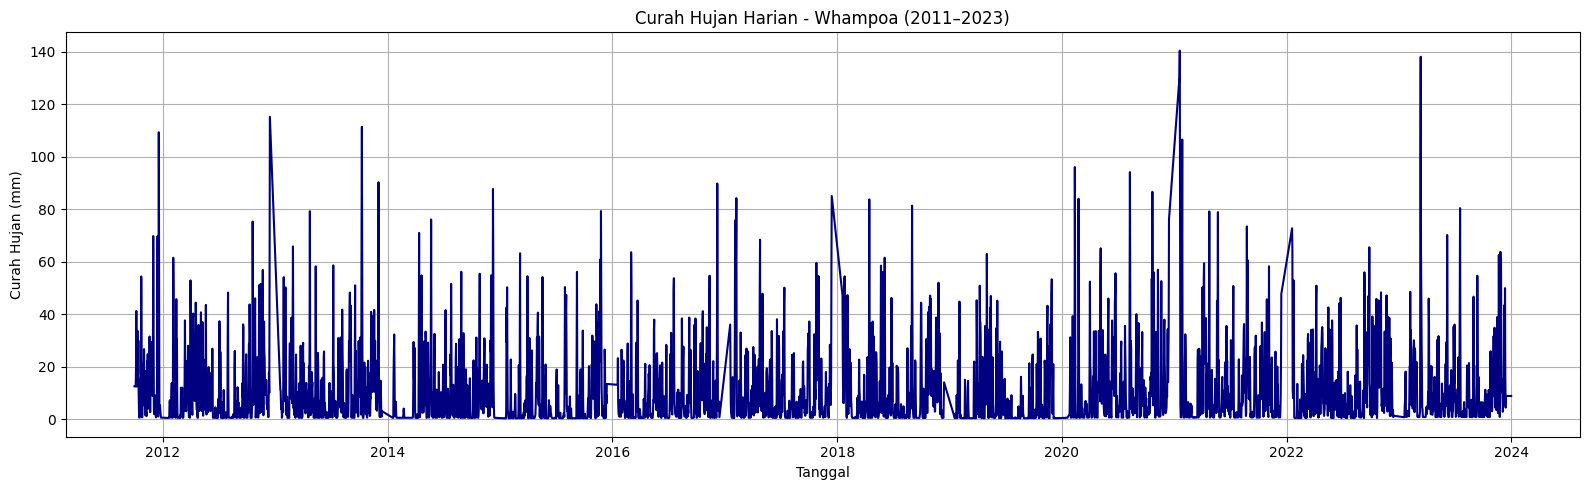

In [224]:
# Gabungkan seluruh tahun dan lakukan interpolasi
df_concat_whampoa = pd.concat(all_whampoa, ignore_index=True)
df_concat_whampoa['rainfall_mm'] = (
    df_concat_whampoa['rainfall_mm']
    .interpolate(method='linear', limit_direction='both')
    .bfill()
    .ffill()
)

# Visualisasi gabungan total
plt.figure(figsize=(16, 5))
plt.plot(df_concat_whampoa['Date'], df_concat_whampoa['rainfall_mm'], color='navy')
plt.title("Curah Hujan Harian - Whampoa (2011–2023)")
plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_concat_whampoa[['Date', 'rainfall_mm']].rename(columns={'rainfall_mm': 'Daily Rainfall Total (mm)'})
df_filtered.to_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Whampoa.csv', index=False)
print(df_filtered.head())


# Membaca kedua file CSV
df_Admiralty = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/Extrack/extr-Whampoa.csv')
df_cleaned = pd.read_csv('C:/Lokal/KEGIATAN/SSDS/data/Train-clean/Whampoa-cleaning.csv')

# Menggabungkan kedua DataFrame berdasarkan kolom 'Date'
df_merged = pd.merge(df_cleaned, df_Admiralty[['Date', 'Daily Rainfall Total (mm)']], on='Date', how='left')

# Menghapus kolom 'prediksi_x' yang berasal dari df_Admiralty_cleaned
df_merged = df_merged.drop(columns=['Daily Rainfall Total (mm)_x'])

# Mengganti nama kolom 'Daily Rainfall Total (mm)_y' menjadi 'Daily Rainfall Total (mm)'
df_merged = df_merged.rename(columns={'Daily Rainfall Total (mm)_y': 'Daily Rainfall Total (mm)'})

# Menyimpan hasilnya ke file CSV baru
df_merged.to_csv('C:/Lokal/KEGIATAN/SSDS/Full_Train/Whampoa-cleaned.csv', index=False)



        Date  Daily Rainfall Total (mm)
0 2011-10-01                  12.528115
1 2011-10-02                  12.528115
2 2011-10-03                  12.528115
3 2011-10-04                  12.528115
4 2011-10-05                  12.528115


# MODEL

In [692]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import math
from sklearn.metrics import mean_squared_error

In [ ]:
# Inisialisasi langsung daftar nama file
file_names = [
    "Admiralty", "Ang_Mo_Kio", "Bukit_Panjang", "Bukit_Timah", "Buona_Vista", 
    "Changi", "Choa_Chu_Kang_Central", "Choa_Chu_Kang_South", "Clementi", 
    "East_Coast_Parkway", "Jurong_Island", "Jurong_Pier", "Jurong_West", 
    "Kent_Ridge", "Kranji_Reservoir", "Lim_Chu_Kang", "Lower_Peirce_Reservoir", 
    "Macritchie_Reservoir", "Mandai", "Marina_Barrage", "Marine_Parade", 
    "Newton", "Nicoll_Highway", "Pasir_Panjang", "Pasir_Ris_Central", 
    "Pasir_Ris_West", "Paya_Lebar", "Pulau_Ubin", "Punggol", "Queenstown", 
    "Seletar", "Sembawang", "Sentosa_Island", "Simei", "Somerset_Road", 
    "Tai_Seng", "Tanjong_Katong", "Tengah", "Toa_Payoh", "Tuas", "Tuas_South", 
    "Ulu_Pandan", "Upper_Peirce_Reservoir", "Whampoa"
]

# Looping untuk setiap file dalam file_names
for file_name in file_names:
    print(f"Memproses file: {file_name}")

    # Membaca dataset untuk setiap file CSV
    df = pd.read_csv(f"C:/Lokal/KEGIATAN/SSDS/Full_Train/")

    # Mengisi nilai NaN dengan 0 untuk kolom numerik
    df[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(0)

    y = df['Daily Rainfall Total (mm)']
    X = df.drop(['Daily Rainfall Total (mm)', "Date"], axis=1)

    # Misalnya df adalah DataFrame yang sudah ada dengan kolom 'Date'
    df['Date'] = pd.to_datetime(df['Date'])  # Pastikan kolom 'Date' bertipe datetime

    # Tambahkan kolom 'Year' jika belum ada
    df['Year'] = df['Date'].dt.year

    train_end_date = pd.to_datetime('2023-11-30')
    test_start_date = pd.to_datetime('2023-12-1')
    test_end_date = pd.to_datetime('2023-12-31')
    
    # Pisahkan data untuk pelatihan (sebelum 31 November 2023)
    X_train = df[df['Date'] < train_end_date].drop(columns=['Date', 'Daily Rainfall Total (mm)'])
    y_train = df[df['Date'] < train_end_date]['Daily Rainfall Total (mm)']

    X_test = df[(df['Date'] >= test_start_date) & (df['Date'] <= test_end_date)].drop(columns=['Date', 'Daily Rainfall Total (mm)'])
    y_test = df[(df['Date'] >= test_start_date) & (df['Date'] <= test_end_date)]['Daily Rainfall Total (mm)']

    # Check shape of train and test sample
    X_train.shape, X_test.shape, y_train.shape, y_test.shape

    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
    
    # === Gradient Boosting Regression ===
    from sklearn.ensemble import GradientBoostingRegressor
    gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_test)
    mse_gb = mean_squared_error(y_test, y_pred_gb)
    r2_gb = r2_score(y_test, y_pred_gb)
    print("\nHasil Gradient Boosting Regression:")
    print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_gb))
    print("R2 Score:", r2_gb)
    print("Mean Squared Error:", mse_gb)

print("Selesai!")  # Tambahkan pesan "Selesai!" untuk menand


Memproses file: Admiralty

Hasil Gradient Boosting Regression:
MAPE: 293210225876501.94
R2 Score: 0.9762451874339559
Mean Squared Error: 2.4141356017639026
Memproses file: Ang_Mo_Kio

Hasil Gradient Boosting Regression:
MAPE: 411529815075503.25
R2 Score: 0.9958991937102898
Mean Squared Error: 1.0318942931193085
Memproses file: Bukit_Panjang

Hasil Gradient Boosting Regression:
MAPE: 729629333241209.9
R2 Score: 0.9826702391201785
Mean Squared Error: 1.2771467530663982
Memproses file: Bukit_Timah

Hasil Gradient Boosting Regression:
MAPE: 469834395271137.75
R2 Score: 0.9880193458477579
Mean Squared Error: 4.500450326333512
Memproses file: Buona_Vista

Hasil Gradient Boosting Regression:
MAPE: 243692968760480.4
R2 Score: 0.9820453018602597
Mean Squared Error: 2.630214931682952
Memproses file: Changi

Hasil Gradient Boosting Regression:
MAPE: 1173790032019363.0
R2 Score: 0.9754913286690818
Mean Squared Error: 4.626839295796852
Memproses file: Choa_Chu_Kang_Central

Hasil Gradient Boosting 

### **TESTING**

In [ ]:
import pandas as pd
import os

# Path ke folder utama yang berisi subfolder
main_folder_path = r"C:\Lokal\KEGIATAN\SSDS\data\Test"

# Loop untuk setiap subfolder di dalam folder MSS
for folder_name in os.listdir(main_folder_path):
    folder_path = os.path.join(main_folder_path, folder_name)

    # Cek apakah itu folder
    if os.path.isdir(folder_path):
        # List untuk menyimpan semua dataframe
        all_data = []

        # Loop untuk setiap file dalam folder
        for filename in os.listdir(folder_path):
            if filename.endswith(".csv"):
                # Path lengkap file CSV
                file_path = os.path.join(folder_path, filename)

                # Coba membaca dengan encoding 'utf-8', jika gagal coba encoding lain
                try:
                    df = pd.read_csv(file_path, encoding='utf-8')
                except UnicodeDecodeError:
                    try:
                        df = pd.read_csv(file_path, encoding='ISO-8859-1')
                    except UnicodeDecodeError:
                        df = pd.read_csv(file_path, encoding='latin1')

                # Menghapus spasi di awal/akhir nama kolom
                df.columns = df.columns.str.strip()

                # Mengganti semua 'min' menjadi 'Min' dalam nama kolom yang sesuai
                df.columns = df.columns.str.replace(r'(?i)min', 'Min', regex=True)

                # Menambahkan dataframe ke list
                all_data.append(df)

        # Menggabungkan semua dataframe menjadi satu
        final_df = pd.concat(all_data, ignore_index=True)

        # Menghapus kolom yang duplikat setelah penggabungan
        final_df = final_df.loc[:, ~final_df.columns.duplicated()]

        # Menyimpan dataframe yang sudah digabungkan ke file CSV baru dengan nama folder
        output_file_path = os.path.join(main_folder_path, f"{folder_name}.csv")
        final_df.to_csv(output_file_path, index=False)

        # Menampilkan dataframe gabungan (bisa lihat beberapa baris pertama)
        print(f"File gabungan untuk folder {folder_name} telah disimpan")
        print(final_df.head())


File gabungan untuk folder Admiralty telah disimpan
         Date  Highest 30 Min Rainfall (mm)  Highest 60 Min Rainfall (mm)  \
0  2024-01-01                           2.0                           2.0   
1  2024-01-02                           0.5                           0.5   
2  2024-01-03                           1.5                           1.5   
3  2024-01-04                          10.6                          13.8   
4  2024-01-05                           2.2                           3.2   

   Highest 120 Min Rainfall (mm)  Mean Temperature (°C)  \
0                            3.0                   25.6   
1                            1.5                   27.1   
2                            1.5                   27.3   
3                           22.2                   24.8   
4                            3.6                   26.0   

   Maximum Temperature (°C)  Minimum Temperature (°C)  Mean Wind Speed (km/h)  \
0                      28.4                      

In [ ]:
import os
import pandas as pd
import numpy as np

# Path ke folder yang berisi file CSV
folder_path = r"C:/Lokal/KEGIATAN/SSDS/data/Test"
# Path ke folder tujuan untuk menyimpan hasil file yang telah dibersihkan
output_folder = r"C:/Lokal/KEGIATAN/SSDS/TESTING"

# Loop untuk setiap file dalam folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        # Path lengkap file CSV
        file_path = os.path.join(folder_path, filename)
        
        # Membaca file CSV
        df = pd.read_csv(file_path)

        # Mengonversi kolom 'Date' menjadi tipe datetime
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
        # Menghapus spasi di awal/akhir setiap elemen di seluruh dataframe
        df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
        
        # Ganti semua string kosong atau whitespace dengan NaN
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
        
        # Ganti semua kemunculan karakter '' dengan NaN
        df.replace('', pd.NA, inplace=True)
        
        # Ubah kolom yang nullable menjadi tipe numerik (float), agar semua nilai hilang menjadi NaN
        df = df.apply(lambda x: pd.to_numeric(x, errors='coerce') if x.dtype != 'datetime64[ns]' else x)
        
        df = df[['Date', 
                 'Highest 30 Min Rainfall (mm)', 
                 'Highest 60 Min Rainfall (mm)', 
                 'Highest 120 Min Rainfall (mm)', 
                 'Mean Temperature (°C)', 
                 'Maximum Temperature (°C)', 
                 'Minimum Temperature (°C)', 
                 'Mean Wind Speed (km/h)', 
                 'Max Wind Speed (km/h)']]

        # Ekstrak tahun dan bulan dari kolom 'Date'
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month

        # Fungsi untuk mengisi nilai kosong dengan median bulanan (dibulatkan 2 angka desimal)
        def fill_missing_with_monthly_median(column_name):
            for year in df['Year'].unique():
                for month in df['Month'].unique():
                    # Pilih data pada tahun dan bulan tertentu
                    monthly_data = df[(df['Year'] == year) & (df['Month'] == month)]

                    # Periksa apakah ada data yang valid untuk menghitung median
                    valid_data = monthly_data[column_name].dropna()

                    # Hitung median dan bulatkan 2 angka di belakang koma
                    if len(valid_data) > 0:
                        median_value = round(valid_data.median(), 2)
                    else:
                        median_value = 0.00  # Tetap dua angka desimal

                    # Isi nilai kosong (NaN) dengan median bulanan yang dibulatkan
                    df.loc[(df['Year'] == year) & (df['Month'] == month) & (df[column_name].isna()), column_name] = median_value

        # Daftar kolom yang ingin diisi
        columns_to_fill = ['Mean Wind Speed (km/h)', 
                           'Highest 30 Min Rainfall (mm)', 
                           'Highest 60 Min Rainfall (mm)', 
                           'Highest 120 Min Rainfall (mm)', 
                           'Mean Temperature (°C)', 
                           'Maximum Temperature (°C)', 
                           'Minimum Temperature (°C)', 
                           'Max Wind Speed (km/h)']

        # Isi nilai kosong pada tiap kolom dengan median bulanan (dibulatkan)
        for col in columns_to_fill:
            fill_missing_with_monthly_median(col)


        df = df[['Date', 
                 'Highest 30 Min Rainfall (mm)', 
                 'Highest 60 Min Rainfall (mm)', 
                 'Highest 120 Min Rainfall (mm)', 
                 'Mean Temperature (°C)', 
                 'Maximum Temperature (°C)', 
                 'Minimum Temperature (°C)', 
                 'Mean Wind Speed (km/h)', 
                 'Max Wind Speed (km/h)']]  
        # Simpan dataframe df ke file CSV dengan nama baru di folder 'Train-clean'
        cleaned_filename = f"{filename.replace('.csv', '')}.csv"
        output_file_path = os.path.join(output_folder, cleaned_filename)
        df.to_csv(output_file_path, index=False)
        
        print(f"Dataframe untuk {filename} berhasil disimpan'")

Dataframe untuk Admiralty.csv berhasil disimpan'
Dataframe untuk Ang_Mo_Kio.csv berhasil disimpan'
Dataframe untuk Bukit_Panjang.csv berhasil disimpan'
Dataframe untuk Bukit_Timah.csv berhasil disimpan'
Dataframe untuk Buona_Vista.csv berhasil disimpan'
Dataframe untuk Changi.csv berhasil disimpan'
Dataframe untuk Choa_Chu_Kang_Central.csv berhasil disimpan'
Dataframe untuk Choa_Chu_Kang_South.csv berhasil disimpan'
Dataframe untuk Clementi.csv berhasil disimpan'
Dataframe untuk East_Coast_Parkway.csv berhasil disimpan'
Dataframe untuk Jurong_Island.csv berhasil disimpan'
Dataframe untuk Jurong_Pier.csv berhasil disimpan'
Dataframe untuk Jurong_West.csv berhasil disimpan'
Dataframe untuk Kent_Ridge.csv berhasil disimpan'
Dataframe untuk Kranji_Reservoir.csv berhasil disimpan'
Dataframe untuk Lim_Chu_Kang.csv berhasil disimpan'
Dataframe untuk Lower_Peirce_Reservoir.csv berhasil disimpan'
Dataframe untuk Macritchie_Reservoir.csv berhasil disimpan'
Dataframe untuk Mandai.csv berhasil dis

In [ ]:
test = pd.read_csv("C:/Lokal/KEGIATAN/SSDS/TESTING/Admiralty.csv")
test

,Date,Highest 30 Min Rainfall (mm),Highest 60 Min Rainfall (mm),Highest 120 Min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
0,2024-01-01,2.0,2.0,3.0,25.6,28.4,24.8,7.1,32.8
1,2024-01-02,0.5,0.5,1.5,27.1,32.2,24.5,9.3,37.0
2,2024-01-03,1.5,1.5,1.5,27.3,30.9,25.3,11.0,41.5
3,2024-01-04,10.6,13.8,22.2,24.8,26.6,23.3,10.0,28.9
4,2024-01-05,2.2,3.2,3.6,26.0,29.4,24.2,12.5,39.6
...,...,...,...,...,...,...,...,...,...
512,2025-05-27,1.6,1.6,1.6,29.4,35.0,26.1,8.2,29.4
513,2025-05-28,0.0,0.0,0.0,29.7,35.1,25.7,9.3,39.6
514,2025-05-29,0.8,1.4,2.0,26.6,29.7,24.0,7.2,54.8
515,2025-05-30,0.0,0.0,0.0,28.9,33.3,25.4,9.4,41.5


In [424]:
test[test.select_dtypes(include='number').columns] = test.select_dtypes(include='number').fillna(0)

In [ ]:
# Mengonversi kolom 'Date' menjadi tipe datetime
test['Date'] = pd.to_datetime(test['Date'])

# Menambahkan kolom 'Year' yang tidak ada pada data baru
test['Year'] = test['Date'].dt.year

# Mengambil fitur yang relevan dari data baru, tanpa kolom target (Daily Rainfall Total (mm))
new_X = test.drop(columns=['Date'])

# Melakukan prediksi menggunakan model MLP yang sudah dilatih
new_pred = gb_model.predict(new_X)

# Menampilkan hasil prediksi
print("Prediksi untuk data baru:", new_pred)


In [ ]:
# Filter data untuk tanggal 1 Januari 2024 hingga 31 Mei 2025
df_filtered = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2025-05-31')].copy()

# Menambahkan kolom prediksi (new_pred) ke df_filtered
df_filtered['prediksi'] = new_pred

# Mengubah nilai negatif pada kolom 'prediksi' menjadi 0
df_filtered['prediksi'] = df_filtered['prediksi'].apply(lambda x: max(0, x))

# Memecah kolom 'Date' menjadi 'Year', 'Month', dan 'Day'
df_filtered['tahun'] = df_filtered['Date'].dt.year
df_filtered['bulan'] = df_filtered['Date'].dt.month
df_filtered['hari'] = df_filtered['Date'].dt.day

# Membuat kolom 'ID (kota)' dengan format: nama_file_tahun_bulan_hari
file_name = "Admiralty.csv"  # Ganti dengan nama file yang sesuai
file_name_without_extension = file_name.replace(".csv", "").lower()  # Menghilangkan ekstensi dan ubah ke lowercase

# Mengambil nama sebelum '_predik' dan mengubah menjadi lowercase
base_name = file_name_without_extension.split('_predik')[0].lower()

# Format ID (kota) dengan nama file yang sudah diubah ke lowercase
df_filtered['ID (kota)'] = base_name + '_' + df_filtered['tahun'].astype(str) + '_' + df_filtered['bulan'].astype(str).str.zfill(2) + '_' + df_filtered['hari'].astype(str).str.zfill(2)

# Menyimpan hanya kolom 'ID (kota)', 'tahun', 'bulan', 'hari', dan 'prediksi'
df_final = df_filtered[['ID (kota)', 'tahun', 'bulan', 'hari', 'prediksi']]

# Menyimpan hasil ke folder yang diinginkan
output_file_path = r"C:/Lokal/KEGIATAN/SSDS/Admiralty-predik.csv"
df_final.to_csv(output_file_path, index=False)

print(f"Dataframe dengan prediksi berhasil disimpan")
